# RemBERT Experiments: Single, Cross-Variety, and Combined Training

This notebook runs the workflow with **google/rembert**:
- pooled training across all varieties
- cross-variety transfer evaluation (train on one, test on all)
- combined training evaluation by target variety
- comparison plots against saved RoBERTa results


In [1]:
# Install required libraries (run once)
%pip install -q datasets transformers accelerate scikit-learn matplotlib seaborn pandas numpy sentencepiece protobuf tiktoken imbalanced-learn bert-score evaluate peft nlpaug nltk

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import random
import pickle
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nlpaug.augmenter.word as naw

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    TrainerCallback,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

import time

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 100

# Model setup
MODEL_LABEL = 'RemBERT'
MODEL_NAME = 'google/rembert'
TASK = 'Sentiment'  # Primary task - will run both Sentiment and Sarcasm in dual-task section
VARIETIES = ['en-AU', 'en-IN', 'en-UK']
SEEDS = [42, 123, 456]  # 3 seeds for better statistical significance
MAX_LEN = 128
NUM_TRAINING_RUNS = 3  # Multiple runs per experiment, pick best

# GPU detection and mixed precision
def get_compute_dtype():
    """Detect GPU and select optimal precision."""
    if torch.cuda.is_available():
        major = torch.cuda.get_device_properties(0).major
        if major >= 8:  # Ampere (RTX 30xx, A4000, A100) and newer
            print(f"  GPU compute capability: sm_{major}x -> using BF16")
            return torch.bfloat16, False, True  # dtype, fp16, bf16
        else:  # Turing (T4), Volta, older
            print(f"  GPU compute capability: sm_{major}x -> using FP16")
            return torch.float16, True, False
    return torch.float32, False, False

COMPUTE_DTYPE, USE_FP16, USE_BF16 = get_compute_dtype()

# A4000 settings (16GB VRAM)
BATCH_SIZE_TRAIN = 8  # Smaller for RemBERT (larger model)
BATCH_SIZE_EVAL = 16
GRADIENT_ACCUMULATION_STEPS = 4  # Effective batch = 32  # Effective batch = 32
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5  # Standard for encoder full fine-tuning
LEARNING_RATE_LORA = 2e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0
EARLY_STOPPING_PATIENCE = 3
LOGGING_STEPS = 25

# Device setup
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    # Optimization for Ampere+
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.set_float32_matmul_precision('high')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# OUT_DIR = Path('/scratch/HS400/outputs_rembert')
OUT_DIR = Path(os.getcwd()) / 'outputs_rembert'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model: {MODEL_NAME}")
print(f"Device: {DEVICE}")
print(f"FP16: {USE_FP16}, BF16: {USE_BF16}")
print(f"Effective Batch Size: {BATCH_SIZE_TRAIN * GRADIENT_ACCUMULATION_STEPS}")
print(f"Training Runs per Experiment: {NUM_TRAINING_RUNS}")
print(f"Outputs: {OUT_DIR.resolve()}")


# Checkpoint and resume setup
RESUME_FROM_CHECKPOINT = True

def check_experiment_completed(experiment_name: str, task_name: str = None) -> bool:
    """Check if an experiment was already completed by looking for saved results."""
    if not RESUME_FROM_CHECKPOINT:
        return False
    
    check_paths = []
    
    if task_name:
        task_dir = OUT_DIR / task_name.lower()
        check_paths.extend([
            task_dir / f'{experiment_name}.csv',
            task_dir / f'{experiment_name}.pkl',
            task_dir / 'final_models' / experiment_name,
        ])
    else:
        check_paths.extend([
            OUT_DIR / f'{experiment_name}.csv',
            OUT_DIR / f'{experiment_name}.pkl',
            OUT_DIR / experiment_name,
        ])
    
    for path in check_paths:
        if path.exists():
            print(f"  [SKIP] Found existing: {path}")
            return True
    return False


def task_out_dir(task_name: str) -> Path:
    """Get task-specific output directory."""
    d = OUT_DIR / task_name.lower()
    d.mkdir(parents=True, exist_ok=True)
    return d


def get_label_col(task_name: str) -> str:
    """Get the dynamically inferred label column for a task."""
    task_lower = task_name.lower()
    if task_lower == 'sentiment':
        return sentiment_col
    elif task_lower == 'sarcasm':
        return sarcasm_col
    else:
        raise ValueError(f"Unknown task: {task_name}")


print("Configuration loaded successfully!")


  GPU compute capability: sm_8x -> using BF16
GPU: NVIDIA RTX A4000
VRAM: 16.7 GB
Model: google/rembert
Device: cuda
FP16: False, BF16: True
Effective Batch Size: 32
Training Runs per Experiment: 3
Outputs: /scratch/HS400/outputs_rembert
Configuration loaded successfully!


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_file(name: str):
    candidates = [
        Path(name),
        Path('./all_outputs') / name,
        Path('../all_outputs') / name,
        Path('../../all_outputs') / name,
        Path('../2.1. Classical vs Transformer/results') / name,
    ]
    for c in candidates:
        if c.exists():
            return c
    matches = list(Path('.').rglob(name))
    return matches[0] if matches else None

In [4]:
# Load dataset
pooled = load_dataset('surrey-nlp/BESSTIE-CW-26')

train_cols = list(pooled['train'].column_names)

# Robust column inference (handles dataset schema variants)
def _pick_col(candidates, cols, required=True):
    for c in candidates:
        if c in cols:
            return c
    if required:
        raise ValueError(f"None of candidate columns {candidates} found in dataset columns: {cols}")
    return None

text_col = _pick_col(['text', 'content', 'sentence', 'review'], train_cols)
sentiment_col = _pick_col(['sentiment', 'Sentiment', 'sentiment_label', 'label_sentiment', 'sentiment_class'], train_cols)
sarcasm_col = _pick_col(['sarcasm', 'Sarcasm', 'sarcasm_label', 'label_sarcasm', 'sarcasm_class'], train_cols)
variety_col = _pick_col(['variety', 'english_variety', 'dialect'], train_cols)

label_col = sentiment_col if TASK.lower() == 'sentiment' else sarcasm_col

for split in ['train', 'validation', 'test']:
    print(split, len(pooled[split]))

print('Columns:', train_cols)
print('Using -> text_col:', text_col, '| label_col:', label_col, '| variety_col:', variety_col)

train 3747
validation 313
test 2183
Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']
Using -> text_col: text | label_col: Sentiment | variety_col: variety


## Base Model Snapshot (Before Fine-Tuning)

Save the original pretrained model and tokenizer so we can compare results before and after fine-tuning.


In [5]:
# Save the base model and tokenizer before fine-tuning (run once)
BASE_DIR = OUT_DIR / 'base_model'
BASE_DIR.mkdir(parents=True, exist_ok=True)

base_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

base_model.save_pretrained(str(BASE_DIR))
base_tokenizer.save_pretrained(str(BASE_DIR))

print('Saved base model snapshot to:', BASE_DIR.resolve())

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/263 [00:00<?, ?B/s]

sentencepiece.model:   0%|          | 0.00/4.70M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.30G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved base model snapshot to: /scratch/HS400/outputs_rembert/base_model


In [ ]:
class TextDataset(Dataset):
    """Custom dataset for text classification with tokenization."""
    
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_len: int = 128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item


class IntLabelDataCollator(DataCollatorWithPadding):
    """
    Data collator that ensures labels are torch.long.
    Prevents numerical issues during mixed-precision training.
    
    """
    def __call__(self, features):
        batch = super().__call__(features)
        if "labels" in batch:
            batch["labels"] = batch["labels"].to(torch.long)
        return batch


def compute_metrics(eval_pred) -> Dict[str, float]:
    """
    Comprehensive metrics computation including:
    - Accuracy
    - Macro/Weighted Precision, Recall, F1
    - Per-class metrics (critical for detecting class collapse)
    - ROC-AUC (when applicable)
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    
    # Compute probabilities for AUC metrics
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    
    metrics = {
        # Accuracy
        'accuracy': accuracy_score(labels, preds),
        
        # Macro averages
        'macro_f1': f1_score(labels, preds, average='macro', zero_division=0),
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0),
        'macro_recall': recall_score(labels, preds, average='macro', zero_division=0),
        
        # Weighted averages
        'weighted_f1': f1_score(labels, preds, average='weighted', zero_division=0),
        'weighted_precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'weighted_recall': recall_score(labels, preds, average='weighted', zero_division=0),
    }
    
    # Per-class F1 (for class balance checks)
    per_class_f1 = f1_score(labels, preds, average=None, zero_division=0, labels=[0, 1])
    metrics['class_0_f1'] = per_class_f1[0] if len(per_class_f1) > 0 else 0.0
    metrics['class_1_f1'] = per_class_f1[1] if len(per_class_f1) > 1 else 0.0
    
    # ROC-AUC (binary classification)
    try:
        if len(np.unique(labels)) == 2:
            metrics['roc_auc'] = roc_auc_score(labels, probs[:, 1])
            metrics['avg_precision'] = average_precision_score(labels, probs[:, 1])
    except Exception:
        pass
    
    return metrics


class TrainingHistoryCallback(TrainerCallback):
    """Callback to track training and validation metrics over epochs."""
    
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.eval_metrics = []
        self.learning_rates = []
        
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if 'loss' in logs:
                self.train_losses.append({
                    'step': state.global_step,
                    'epoch': state.epoch,
                    'loss': logs['loss']
                })
            if 'learning_rate' in logs:
                self.learning_rates.append({
                    'step': state.global_step,
                    'lr': logs['learning_rate']
                })
    
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            self.eval_losses.append({
                'step': state.global_step,
                'epoch': state.epoch,
                'eval_loss': metrics.get('eval_loss', None),
            })
            eval_record = {'step': state.global_step, 'epoch': state.epoch}
            eval_record.update({k: v for k, v in metrics.items() if k.startswith('eval_')})
            self.eval_metrics.append(eval_record)


class WeightedTrainer(Trainer):
    """
    Custom Trainer with class-weighted loss.
    ONLY use this when NOT oversampling (to avoid double-correction).
    """
    
    def __init__(self, class_weights: Optional[np.ndarray] = None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            self._class_weights = torch.tensor(class_weights, dtype=torch.float32)
        else:
            self._class_weights = None
        self._loss_fn_cache = None
    
    def _get_loss_fn(self, device):
        if self._class_weights is not None:
            weight = self._class_weights.to(device=device, dtype=torch.float32)
            return torch.nn.CrossEntropyLoss(weight=weight)
        return torch.nn.CrossEntropyLoss()
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        
        # Always compute loss in float32 for numerical stability
        logits_fp32 = logits.float()
        loss_fn = self._get_loss_fn(logits.device)
        loss = loss_fn(logits_fp32.view(-1, model.config.num_labels), labels.view(-1))
        
        if torch.isnan(loss):
            print(f"WARNING: NaN loss detected! Taking a zero-gradient step.")
            # Tie the dummy loss to the computational graph using the logits,
            # but multiply by 0.0 so the gradients backpropagated are exactly 0.
            loss = (logits.sum() * 0.0) + 10.0
        
        return (loss, outputs) if return_outputs else loss

class FocalLossTrainer(Trainer):
    """Trainer using Focal Loss for highly imbalanced, hard-to-classify data."""
    def __init__(self, gamma: float = 2.0, class_weights: Optional[np.ndarray] = None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma = gamma
        self.weight = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits").float()
        
        # Standard Cross Entropy
        device_weight = self.weight.to(logits.device) if self.weight is not None else None
        ce_loss = F.cross_entropy(logits.view(-1, model.config.num_labels), labels.view(-1), 
                                  weight=device_weight, reduction='none')
        
        # Focal Loss modification: (1 - pt)^gamma * CE_Loss
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()
        
        if torch.isnan(focal_loss):
            focal_loss = (logits.sum() * 0.0) + 10.0
            
        return (focal_loss, outputs) if return_outputs else focal_loss


def get_trainer(
    model,
    args: TrainingArguments,
    train_dataset,
    eval_dataset,
    tokenizer,
    class_weights: Optional[np.ndarray] = None,
    use_weighted_loss: bool = False,
    use_focal_loss: bool = False,
    callbacks: List = None
):
    """
    Factory function to get the appropriate trainer.
    
    - If use_focal_loss=True: Uses FocalLossTrainer (Best for extreme hard-example mining)
    - If use_weighted_loss=True: Uses WeightedTrainer (Standard penalty for imbalance)
    - If neither: Uses standard Trainer (Data is already balanced via oversample/augment)
    """
    data_collator = IntLabelDataCollator(tokenizer)
    
    if callbacks is None:
        callbacks = [EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
    
    # 1. Route to Focal Loss Trainer
    if use_focal_loss and class_weights is not None:
        print("  Using FocalLossTrainer with class weights (gamma=2.0)")
        return FocalLossTrainer(
            gamma=2.0,
            class_weights=class_weights,
            model=model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=callbacks,
        )
        
    # 2. Route to standard Weighted Trainer
    elif use_weighted_loss and class_weights is not None:
        print("  Using WeightedTrainer with class weights")
        return WeightedTrainer(
            class_weights=class_weights,
            model=model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=callbacks,
        )
        
    # 3. Route to standard Trainer (for Over/Undersample & Augmentation)
    else:
        print("  Using standard Trainer (data is balanced via resampling/augmentation)")
        return Trainer(
            model=model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=callbacks,
        )


def plot_training_history(history_callback: TrainingHistoryCallback, save_path: Path, title_prefix: str = ''):
    """Plot comprehensive training history including loss curves and metrics."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Training Loss
    if history_callback.train_losses:
        train_df = pd.DataFrame(history_callback.train_losses)
        axes[0, 0].plot(train_df['step'], train_df['loss'], 'b-', alpha=0.7, label='Train Loss')
        axes[0, 0].set_xlabel('Step')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title(f'Training Loss', fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)
    
    # 2. Eval Loss
    if history_callback.eval_losses:
        eval_df = pd.DataFrame(history_callback.eval_losses)
        eval_df = eval_df.dropna(subset=['eval_loss'])
        if not eval_df.empty:
            axes[0, 1].plot(eval_df['epoch'], eval_df['eval_loss'], 'r-o', label='Eval Loss')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('Loss')
            axes[0, 1].set_title(f'Validation Loss', fontweight='bold')
            axes[0, 1].legend()
            axes[0, 1].grid(alpha=0.3)
    
    # 3. F1 Scores (including per-class)
    if history_callback.eval_metrics:
        metrics_df = pd.DataFrame(history_callback.eval_metrics)
        if 'eval_macro_f1' in metrics_df.columns:
            axes[1, 0].plot(metrics_df['epoch'], metrics_df['eval_macro_f1'], 'g-o', label='Macro F1', linewidth=2)
        if 'eval_class_0_f1' in metrics_df.columns:
            axes[1, 0].plot(metrics_df['epoch'], metrics_df['eval_class_0_f1'], 'r--s', label='Class 0 F1', alpha=0.7)
        if 'eval_class_1_f1' in metrics_df.columns:
            axes[1, 0].plot(metrics_df['epoch'], metrics_df['eval_class_1_f1'], 'b--^', label='Class 1 F1', alpha=0.7)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('F1 Score')
        axes[1, 0].set_ylim(0, 1)
        axes[1, 0].set_title(f'F1 Scores Over Epochs', fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    
    # 4. Learning Rate
    if history_callback.learning_rates:
        lr_df = pd.DataFrame(history_callback.learning_rates)
        axes[1, 1].plot(lr_df['step'], lr_df['lr'], 'c-', label='Learning Rate')
        axes[1, 1].set_xlabel('Step')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_title(f'Learning Rate Schedule', fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)
        axes[1, 1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    if title_prefix:
        plt.suptitle(title_prefix.strip(" -"), fontweight='bold', fontsize=16)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_confusion_matrix(cm: np.ndarray, save_path: Path, title: str = 'Confusion Matrix'):
    """Plot normalized confusion matrix with counts."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.046)
    cbar.set_label('Proportion', rotation=270, labelpad=15)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.1%})',
                   ha='center', va='center', color=color, fontsize=12, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
    ax.set_yticklabels(['Negative (0)', 'Positive (1)'])
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('True', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_roc_pr_curves(y_true: np.ndarray, y_probs: np.ndarray, save_path: Path, title_prefix: str = ''):
    """Plot ROC and Precision-Recall curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = roc_auc_score(y_true, y_probs)
    axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[0].fill_between(fpr, tpr, alpha=0.2)
    axes[0].set_xlim([0, 1])
    axes[0].set_ylim([0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'{title_prefix}ROC Curve', fontweight='bold')
    axes[0].legend(loc='lower right')
    axes[0].grid(alpha=0.3)
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    avg_prec = average_precision_score(y_true, y_probs)
    axes[1].plot(recall, precision, 'r-', lw=2, label=f'PR (AP = {avg_prec:.3f})')
    axes[1].fill_between(recall, precision, alpha=0.2, color='red')
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{title_prefix}Precision-Recall Curve', fontweight='bold')
    axes[1].legend(loc='lower left')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def get_training_args(output_dir: str, seed: int, use_lora: bool = False) -> TrainingArguments:
    """Get standardized training arguments optimized for A4000 GPU."""
    lr = LEARNING_RATE_LORA if use_lora else LEARNING_RATE
    
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE_TRAIN,
        per_device_eval_batch_size=BATCH_SIZE_EVAL,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        max_grad_norm=MAX_GRAD_NORM,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        save_total_limit=2,
        save_only_model=True,
        logging_steps=LOGGING_STEPS,
        logging_first_step=True,
        seed=seed,
        data_seed=seed,
        fp16=USE_FP16,
        bf16=USE_BF16,
        fp16_full_eval=False,
        dataloader_num_workers=0,  # was 2 - Windows multiprocessing deadlocks in Jupyter/%run context
        dataloader_prefetch_factor=None,  # must be None when num_workers=0
        dataloader_pin_memory=False,  # pin_memory also causes issues with num_workers=0 on Windows
        report_to='none',
        disable_tqdm=False,
    )


print("Loaded: TextDataset, IntLabelDataCollator, compute_metrics")
print("Loaded: WeightedTrainer, get_trainer (factory function)")
print("Loaded: TrainingHistoryCallback, plot_training_history, plot_confusion_matrix, plot_roc_pr_curves")
print("Loaded: get_training_args (with LoRA LR support)")


Loaded: TextDataset, IntLabelDataCollator, compute_metrics
Loaded: WeightedTrainer, get_trainer (factory function)
Loaded: TrainingHistoryCallback, plot_training_history, plot_confusion_matrix, plot_roc_pr_curves
Loaded: get_training_args (with LoRA LR support)


In [7]:
# Dataset balancing strategy
from collections import Counter
from typing import List, Dict, Tuple

def get_class_distribution(labels: List[int]) -> Dict[int, int]:
    """Get class distribution."""
    return dict(Counter(labels))

def check_imbalance(labels: List[int], threshold: float = 2.0) -> Tuple[bool, float]:
    """
    Check if dataset is imbalanced.
    Returns: (is_imbalanced, imbalance_ratio)
    """
    dist = Counter(labels)
    if len(dist) < 2:
        return False, 1.0
    majority = max(dist.values())
    minority = min(dist.values())
    ratio = majority / minority if minority > 0 else float('inf')
    return ratio > threshold, ratio

# Selected balancing strategy
# We bypass the comparison and strictly use class weights.
# This prevents dataset manipulation/token corruption and is natively supported
# by the custom WeightedTrainer.

SELECTED_BALANCING_STRATEGY = 'weighted'

print(f"Dataset Balancing Strategy permanently set to: {SELECTED_BALANCING_STRATEGY.upper()}")

Dataset Balancing Strategy permanently set to: WEIGHTED


In [8]:
# PEFT/LoRA fine-tuning support
# LoRA (Low-Rank Adaptation) is parameter-efficient fine-tuning that:
# Only trains ~0.1-1% of parameters (vs 100% for full fine-tuning)
# Uses less memory (can use larger batches on A4000)
# Often achieves comparable or better performance
# Faster training

try:
    from peft import LoraConfig, get_peft_model, TaskType, PeftModel
    PEFT_AVAILABLE = True
    print("✓ PEFT (LoRA) is available")
except ImportError:
    PEFT_AVAILABLE = False
    print("⚠ PEFT not installed. Install with: pip install peft")
    print("  Will fall back to full fine-tuning.")


# LoRA configuration for classification
def get_lora_config():
    """Get LoRA configuration optimized for text classification."""
    return LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,                      # Rank of the update matrices
        lora_alpha=32,             # Scaling factor
        lora_dropout=0.1,          # Dropout for LoRA layers
        bias="none",               # Don't train bias
        target_modules = ["query", "key", "value", "dense"],  # Which layers to apply LoRA to
    )


def get_model_with_lora(model_name: str, num_labels: int = 2):
    """Load model with LoRA adapters."""
    if not PEFT_AVAILABLE:
        print("PEFT not available, returning standard model")
        return AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels
        )
    
    # Load base model
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )
    
    # Apply LoRA
    lora_config = get_lora_config()
    model = get_peft_model(base_model, lora_config)
    
    # Print trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Trainable parameters: {trainable_params:,} / {total_params:,} ({100 * trainable_params / total_params:.2f}%)")
    
    return model


def count_parameters(model):
    """Count trainable and total parameters."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


# Fine-tuning method selection
FINETUNE_METHODS = ['full', 'lora'] if PEFT_AVAILABLE else ['full']
print(f"Available fine-tuning methods: {FINETUNE_METHODS}")


✓ PEFT (LoRA) is available
Available fine-tuning methods: ['full', 'lora']



Comparing fine-tuning methods...

FINE-TUNING COMPARISON: Sentiment (seed=42)
Using balancing strategy: weighted
Using weighted loss: True
Train size: 3747

>>> Method: FULL


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Parameters: 575,922,690 trainable / 575,922,690 total (100.00%)
  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,1.475527,0.203822,0.920128,0.920010,0.920762,0.919730,0.920079,0.920501,0.920128,0.923077,0.916944,0.970935,0.976207
2,0.878900,0.295676,0.875399,0.874662,0.889387,0.877553,0.874448,0.891168,0.875399,0.865052,0.884273,0.973652,0.978880
3,0.391571,0.225186,0.952077,0.952045,0.952129,0.951981,0.952073,0.952088,0.952077,0.953271,0.950820,0.978064,0.977516
4,0.188808,0.292271,0.932907,0.932883,0.932839,0.932945,0.932911,0.932935,0.932907,0.934169,0.931596,0.980392,0.975678
5,0.001940,0.347338,0.945687,0.945578,0.946949,0.945159,0.945632,0.946528,0.945687,0.948012,0.943144,0.980413,0.975863


...

  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Parameters: 10,656,002 trainable / 586,578,692 total (1.82%)
  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,1.529552,0.232677,0.936102,0.936102,0.936392,0.936499,0.936106,0.936798,0.936102,0.936306,0.935897,0.981332,0.980253
2,0.975284,0.197874,0.920128,0.920125,0.920274,0.920445,0.920136,0.920614,0.920128,0.920635,0.919614,0.980576,0.980401
3,0.587728,0.192602,0.939297,0.939208,0.939988,0.938909,0.939260,0.939703,0.939297,0.941538,0.936877,0.981066,0.983784
4,0.310405,0.210864,0.936102,0.936086,0.936035,0.936213,0.936109,0.936192,0.936102,0.937107,0.935065,0.980739,0.983904
5,0.155798,0.228573,0.932907,0.932863,0.932944,0.932802,0.932902,0.932915,0.932907,0.934579,0.931148,0.982333,0.984302


  -> Macro F1: 0.9030, Class0 F1: 0.9086, Class1 F1: 0.8974
  -> Time: 402.7s

FINE-TUNING COMPARISON RESULTS
method  trainable_pct  training_time_sec  macro_f1  class_0_f1  class_1_f1
  full     100.000000         456.957125  0.901503    0.902406    0.900601
  lora       1.816636         402.652021  0.903021    0.908618    0.897423

>>> AUTO-SELECTED: LORA
    Reason: LoRA F1 (0.9030) within 1% of Full (0.9015), choosing LoRA for efficiency


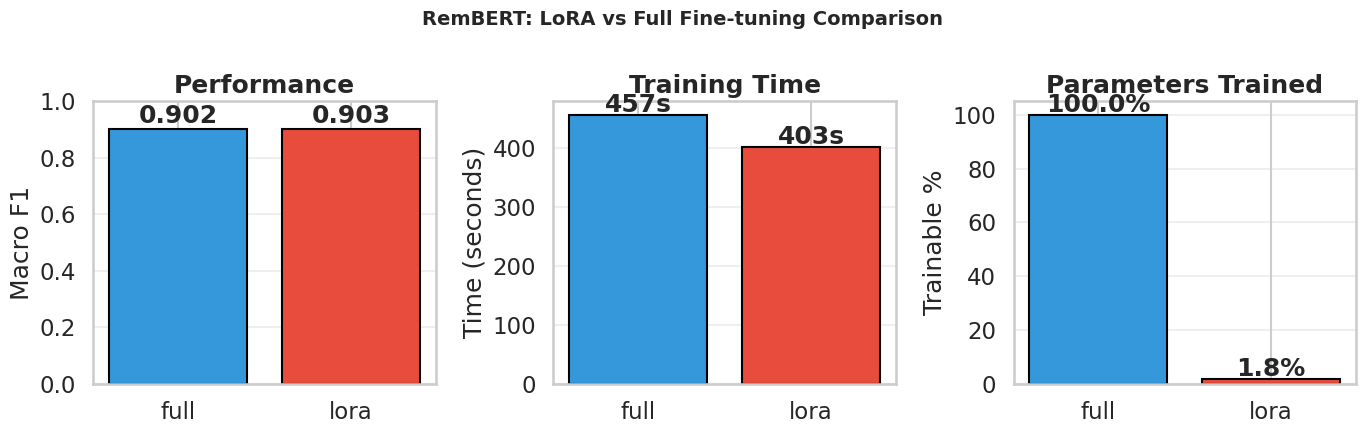


SELECTED FINE-TUNING METHOD: LORA
SELECTED BALANCING STRATEGY: WEIGHTED

All subsequent experiments will use these settings.


In [9]:
# Fine-tuning method comparison: LoRA vs full
# Compare LoRA (parameter-efficient) vs Full fine-tuning
# Then use the better method for later experiments.

import time

def run_finetuning_comparison(task_name: str, seed: int = 42) -> Dict[str, Any]:
    """
    Compare Full fine-tuning vs LoRA on the same task.
    Uses the correct trainer based on balancing strategy.
    """
    lbl_col = get_label_col(task_name)
    
    print(f"\n{'='*60}")
    print(f"FINE-TUNING COMPARISON: {task_name} (seed={seed})")
    print(f"{'='*60}")
    
    # Prepare data (use selected balancing strategy)
    tr_texts_orig = list(pooled['train'][text_col])
    tr_labels_orig = [int(x) for x in pooled['train'][lbl_col]]
    
    # Apply selected balancing strategy
    use_weighted_loss = False  # Default: oversample = no weighted loss
    if SELECTED_BALANCING_STRATEGY == 'weighted':
        tr_texts, tr_labels = tr_texts_orig, tr_labels_orig
        use_weighted_loss = True
    elif SELECTED_BALANCING_STRATEGY == 'oversample':
        tr_texts, tr_labels = balance_dataset_oversample(tr_texts_orig, tr_labels_orig, seed)
        use_weighted_loss = False
    elif SELECTED_BALANCING_STRATEGY == 'undersample':
        tr_texts, tr_labels = balance_dataset_undersample(tr_texts_orig, tr_labels_orig, seed)
        use_weighted_loss = False
    else:
        tr_texts, tr_labels = tr_texts_orig, tr_labels_orig
        use_weighted_loss = True
    
    va_texts = list(pooled['validation'][text_col])
    va_labels = [int(x) for x in pooled['validation'][lbl_col]]
    te_texts = list(pooled['test'][text_col])
    te_labels = [int(x) for x in pooled['test'][lbl_col]]
    
    print(f"Using balancing strategy: {SELECTED_BALANCING_STRATEGY}")
    print(f"Using weighted loss: {use_weighted_loss}")
    print(f"Train size: {len(tr_texts)}")
    
    results = {}
    
    for method in FINETUNE_METHODS:
        print(f"\n>>> Method: {method.upper()}")
        set_seed(seed)
        
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
        
        # Load model based on method
        start_time = time.time()
        use_lora = (method == 'lora' and PEFT_AVAILABLE)
        if use_lora:
            model = get_model_with_lora(MODEL_NAME, num_labels=2)
        else:
            model = AutoModelForSequenceClassification.from_pretrained(
                MODEL_NAME, num_labels=2, problem_type="single_label_classification"
            )
        model = model.to(DEVICE)
        
        trainable, total = count_parameters(model)
        print(f"  Parameters: {trainable:,} trainable / {total:,} total ({100*trainable/total:.2f}%)")
        
        # Create datasets
        tr_ds = TextDataset(tr_texts, tr_labels, tokenizer, max_len=MAX_LEN)
        va_ds = TextDataset(va_texts, va_labels, tokenizer, max_len=MAX_LEN)
        te_ds = TextDataset(te_texts, te_labels, tokenizer, max_len=MAX_LEN)
        
        # Class weights only if using weighted loss
        cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=np.array(tr_labels)) if use_weighted_loss else None
        
        # Training args with appropriate LR for method
        ckpt_dir = OUT_DIR / f'finetune_{method}_{task_name.lower()}_seed{seed}'
        args = get_training_args(str(ckpt_dir), seed, use_lora=use_lora)
        
        # LoRA can use larger batch size (less memory)
        if use_lora:
            args.per_device_train_batch_size = min(32, BATCH_SIZE_TRAIN * 2)
            args.per_device_eval_batch_size = min(64, BATCH_SIZE_EVAL * 2)
        
        history_callback = TrainingHistoryCallback()
        use_focal = False
        
        # Use factory function to get correct trainer
        trainer = get_trainer(
            model=model,
            args=args,
            train_dataset=tr_ds,
            eval_dataset=va_ds,
            tokenizer=tokenizer,
            class_weights=cw,
            use_weighted_loss=use_weighted_loss,
            use_focal_loss=use_focal,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), history_callback],
        )
        
        # Train and measure time
        train_result = trainer.train()
        training_time = time.time() - start_time
        
        # Evaluate
        pred = trainer.predict(te_ds)
        y_pred = np.argmax(pred.predictions, axis=-1)
        y_true = np.array(te_labels)
        
        per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
        
        metrics = {
            'method': method,
            'trainable_params': trainable,
            'total_params': total,
            'trainable_pct': 100 * trainable / total,
            'training_time_sec': training_time,
            'accuracy': float(accuracy_score(y_true, y_pred)),
            'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
            'class_0_f1': float(per_class_f1[0]),
            'class_1_f1': float(per_class_f1[1]),
            'macro_precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
            'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        }
        
        results[method] = metrics
        print(f"  -> Macro F1: {metrics['macro_f1']:.4f}, Class0 F1: {metrics['class_0_f1']:.4f}, Class1 F1: {metrics['class_1_f1']:.4f}")
        print(f"  -> Time: {training_time:.1f}s")
        
        # Save model
        save_path = OUT_DIR / f'{MODEL_LABEL.lower()}_{method}_{task_name.lower()}_seed{seed}'
        save_path.mkdir(parents=True, exist_ok=True)
        if use_lora:
            model.save_pretrained(str(save_path))
        else:
            trainer.model.save_pretrained(str(save_path))
        tokenizer.save_pretrained(str(save_path))
        
        del model, trainer
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return results


# Run comparison
if len(FINETUNE_METHODS) > 1:
    print("\nComparing fine-tuning methods...")
    finetuning_comparison = run_finetuning_comparison('Sentiment', seed=42)
    
    # Create comparison table
    comparison_df = pd.DataFrame(list(finetuning_comparison.values()))
    print(f"\n{'='*60}")
    print("FINE-TUNING COMPARISON RESULTS")
    print(f"{'='*60}")
    print(comparison_df[['method', 'trainable_pct', 'training_time_sec', 'macro_f1', 'class_0_f1', 'class_1_f1']].to_string(index=False))
    
    # Prefer LoRA if F1 is within 1% of full.
    full_f1 = finetuning_comparison['full']['macro_f1']
    lora_f1 = finetuning_comparison.get('lora', {}).get('macro_f1', 0)
    
    if lora_f1 >= full_f1 - 0.01:
        SELECTED_FINETUNE_METHOD = 'lora'
        reason = f"LoRA F1 ({lora_f1:.4f}) within 1% of Full ({full_f1:.4f}), choosing LoRA for efficiency"
    else:
        SELECTED_FINETUNE_METHOD = 'full'
        reason = f"Full F1 ({full_f1:.4f}) > LoRA F1 ({lora_f1:.4f}) by >1%, choosing Full"
    
    print(f"\n>>> AUTO-SELECTED: {SELECTED_FINETUNE_METHOD.upper()}")
    print(f"    Reason: {reason}")
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    
    methods = list(finetuning_comparison.keys())
    colors = ['#3498db', '#e74c3c'][:len(methods)]
    
    # F1 score
    f1s = [finetuning_comparison[m]['macro_f1'] for m in methods]
    bars = axes[0].bar(methods, f1s, color=colors, edgecolor='black')
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('Macro F1')
    axes[0].set_title('Performance', fontweight='bold')
    for bar, v in zip(bars, f1s):
        axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Training time
    times = [finetuning_comparison[m]['training_time_sec'] for m in methods]
    bars = axes[1].bar(methods, times, color=colors, edgecolor='black')
    axes[1].set_ylabel('Time (seconds)')
    axes[1].set_title('Training Time', fontweight='bold')
    for bar, v in zip(bars, times):
        axes[1].text(bar.get_x() + bar.get_width()/2, v + 5, f'{v:.0f}s', ha='center', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Trainable parameters
    params = [finetuning_comparison[m]['trainable_pct'] for m in methods]
    bars = axes[2].bar(methods, params, color=colors, edgecolor='black')
    axes[2].set_ylabel('Trainable %')
    axes[2].set_title('Parameters Trained', fontweight='bold')
    for bar, v in zip(bars, params):
        axes[2].text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'{MODEL_LABEL}: LoRA vs Full Fine-tuning Comparison', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'finetuning_method_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Save comparison
    comparison_df.to_csv(OUT_DIR / 'finetuning_method_comparison.csv', index=False)
    with open(OUT_DIR / 'selected_finetune_method.txt', 'w') as f:
        f.write(SELECTED_FINETUNE_METHOD)
    
else:
    SELECTED_FINETUNE_METHOD = 'full'
    print("Only full fine-tuning available (PEFT not installed)")

print(f"\n{'='*60}")
print(f"SELECTED FINE-TUNING METHOD: {SELECTED_FINETUNE_METHOD.upper()}")
print(f"SELECTED BALANCING STRATEGY: {SELECTED_BALANCING_STRATEGY.upper()}")
print(f"{'='*60}")
print("\nAll subsequent experiments will use these settings.")


In [ ]:
# Unified training function (selected strategy)
# Set SELECTED_BALANCING_STRATEGY before running this cell.
# Set the strategy before running this cell.

def prepare_balanced_data(texts: List[str], labels: List[int], strategy: str, seed: int = 42) -> Tuple[List[str], List[int], bool]:
    """
    Prepare data with the specified balancing strategy.
    Returns: (texts, labels, use_weighted_loss)
    """
    if strategy is None or strategy == 'none':
        # No balancing - use original data with weighted loss
        print("  No balancing strategy set, using original data with weighted loss")
        return texts, labels, True
    elif strategy == 'weighted':
        return texts, labels, True
    elif strategy == 'oversample':
        bal_texts, bal_labels = balance_dataset_oversample(texts, labels, seed)
        return bal_texts, bal_labels, False
    elif strategy == 'undersample':
        bal_texts, bal_labels = balance_dataset_undersample(texts, labels, seed)
        return bal_texts, bal_labels, False
    else:
        print(f"  Unknown strategy '{strategy}', falling back to weighted")
        return texts, labels, True


def load_model_with_selected_method(model_name: str, num_labels: int = 2):
    """Load model using the selected fine-tuning method (full or LoRA)."""
    if SELECTED_FINETUNE_METHOD == 'lora' and PEFT_AVAILABLE:
        return get_model_with_lora(model_name, num_labels)
    else:
        return AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels, problem_type="single_label_classification"
        )


def get_optimized_training_args(output_dir: str, seed: int) -> TrainingArguments:
    """Get training arguments optimized for the selected fine-tuning method."""
    use_lora = (SELECTED_FINETUNE_METHOD == 'lora' and PEFT_AVAILABLE)
    args = get_training_args(output_dir, seed, use_lora=use_lora)
    
    if use_lora:
        args.per_device_train_batch_size = min(32, BATCH_SIZE_TRAIN * 2)
        args.per_device_eval_batch_size = min(64, BATCH_SIZE_EVAL * 2)
        args.num_train_epochs = max(3, NUM_EPOCHS - 1)
    
    return args


def train_model_unified(
    task_name: str,
    train_texts: List[str],
    train_labels: List[int],
    val_texts: List[str],
    val_labels: List[int],
    seed: int,
    output_name: str,
    balancing_strategy: str = None,  # Can override global setting
    save_plots: bool = True
) -> Tuple[Any, Any, Any]:
    """
    Unified training function.
    
    Args:
        balancing_strategy: Override SELECTED_BALANCING_STRATEGY if provided
    
    Returns: (trainer, tokenizer, history_callback)
    """
    set_seed(seed)
    
    # Use provided strategy or global
    strategy = balancing_strategy if balancing_strategy is not None else SELECTED_BALANCING_STRATEGY
    
    if strategy is None:
        raise ValueError(
            "SELECTED_BALANCING_STRATEGY is not set! "
            "Run Cell 9 first, review results, then set: "
            "SELECTED_BALANCING_STRATEGY = 'oversample' (or 'undersample' or 'weighted')"
        )
    
    # Check imbalance
    is_imbalanced, ratio = check_imbalance(train_labels)
    print(f"  Task: {task_name}, Imbalance ratio: {ratio:.2f}:1")
    
    # Apply balancing strategy
    bal_texts, bal_labels, use_weighted_loss = prepare_balanced_data(
        train_texts, train_labels, strategy, seed
    )
    
    print(f"  Strategy: {strategy}, Use Weighted Loss: {use_weighted_loss}")
    
    # Load model
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
    model = load_model_with_selected_method(MODEL_NAME, num_labels=2).to(DEVICE)
    
    # Create datasets
    tr_ds = TextDataset(bal_texts, bal_labels, tokenizer, max_len=MAX_LEN)
    va_ds = TextDataset(val_texts, val_labels, tokenizer, max_len=MAX_LEN)
    
    # Class weights only if using weighted loss
    cw = None
    if use_weighted_loss:
        cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=np.array(bal_labels))
    
    # Training arguments
    ckpt_dir = task_out_dir(task_name) / 'checkpoints' / output_name
    args = get_optimized_training_args(str(ckpt_dir), seed)
    
    # Callbacks
    history_callback = TrainingHistoryCallback()
    
    # Get appropriate trainer
    trainer = get_trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        tokenizer=tokenizer,
        class_weights=cw,
        use_weighted_loss=use_weighted_loss,
        use_focal_loss=use_focal,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), history_callback],
    )
    
    # Train
    trainer.train()
    
    return trainer, tokenizer, history_callback


def train_with_multiple_runs(
    task_name: str,
    train_texts: List[str],
    train_labels: List[int],
    val_texts: List[str],
    val_labels: List[int],
    test_texts: List[str],
    test_labels: List[int],
    output_name: str,
    balancing_strategy: str = None,
    num_runs: int = NUM_TRAINING_RUNS,
) -> Dict[str, Any]:
    """Train multiple runs with different seeds and select the best one."""
    print(f"\n>>> Training {num_runs} runs for {output_name}...")
    
    best_f1 = 0
    best_run = None
    all_results = []
    
    for run_id in range(1, num_runs + 1):
        seed = 42 + run_id - 1
        print(f"\n  Run {run_id}/{num_runs} (seed={seed})")
        
        trainer, tokenizer, history = train_model_unified(
            task_name, train_texts, train_labels, val_texts, val_labels,
            seed, f"{output_name}_run{run_id}", 
            balancing_strategy=balancing_strategy,
            save_plots=False
        )
        
        te_ds = TextDataset(test_texts, test_labels, tokenizer, max_len=MAX_LEN)
        pred = trainer.predict(te_ds)
        y_pred = np.argmax(pred.predictions, axis=-1)
        y_true = np.array(test_labels)
        
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
        
        result = {
            'run': run_id,
            'seed': seed,
            'macro_f1': macro_f1,
            'class_0_f1': per_class_f1[0],
            'class_1_f1': per_class_f1[1],
        }
        all_results.append(result)
        print(f"    Macro F1: {macro_f1:.4f}, Class0: {per_class_f1[0]:.4f}, Class1: {per_class_f1[1]:.4f}")
        
        if macro_f1 > best_f1:
            best_f1 = macro_f1
            best_run = result
        
        del trainer
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    print(f"\n  Best run: {best_run['run']} with Macro F1: {best_f1:.4f}")
    
    return {
        'best_run': best_run,
        'all_runs': all_results,
    }


# Configuration check
print(f"{'='*60}")
print("UNIFIED TRAINING CONFIGURATION")
print(f"{'='*60}")
print(f"  Model: {MODEL_NAME}")
print(f"  Device: {DEVICE}")
print(f"  Fine-tuning Method: {SELECTED_FINETUNE_METHOD if 'SELECTED_FINETUNE_METHOD' in dir() else 'Not set yet'}")
print(f"  Balancing Strategy: {SELECTED_BALANCING_STRATEGY if SELECTED_BALANCING_STRATEGY else 'NOT SET - run Cell 9 first!'}")
print(f"{'='*60}")

if SELECTED_BALANCING_STRATEGY is None:
    print("\nWARNING: SELECTED_BALANCING_STRATEGY is not set!")
    print("   Run Cell 9 to compare strategies, then set it manually:")
    print("   SELECTED_BALANCING_STRATEGY = 'oversample'  # or 'undersample' or 'weighted'")


UNIFIED TRAINING CONFIGURATION
  Model: google/rembert
  Device: cuda
  Fine-tuning Method: lora
  Balancing Strategy: weighted


In [11]:
# Advanced metrics: BERTScore, perplexity, confidence, calibration

# Install additional dependencies
try:
    from bert_score import score as bert_score_fn
    BERTSCORE_AVAILABLE = True
    print("✓ bert_score is available")
except ImportError:
    BERTSCORE_AVAILABLE = False
    print("⚠ bert_score not installed. Install with: pip install bert-score")

try:
    from evaluate import load as load_metric
    EVALUATE_AVAILABLE = True
    print("✓ evaluate library is available")
except ImportError:
    EVALUATE_AVAILABLE = False
    print("⚠ evaluate not installed. Install with: pip install evaluate")


def compute_prediction_confidence(logits: np.ndarray) -> Dict[str, float]:
    """
    Compute confidence metrics from model logits.
    
    Returns:
        - mean_confidence: Average max probability
        - mean_entropy: Average prediction entropy
        - confidence_std: Std of confidence scores
    """
    # Convert to probabilities
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    
    # Max probability (confidence)
    max_probs = np.max(probs, axis=1)
    
    # Entropy: -sum(p * log(p))
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    
    return {
        'mean_confidence': float(np.mean(max_probs)),
        'confidence_std': float(np.std(max_probs)),
        'min_confidence': float(np.min(max_probs)),
        'max_confidence': float(np.max(max_probs)),
        'mean_entropy': float(np.mean(entropy)),
        'entropy_std': float(np.std(entropy)),
    }


def compute_expected_calibration_error(y_true: np.ndarray, y_probs: np.ndarray, 
                                        n_bins: int = 10) -> Dict[str, Any]:
    """
    Compute Expected Calibration Error (ECE) and reliability diagram data.
    
    ECE measures how well predicted probabilities match actual accuracy.
    A perfectly calibrated model has ECE = 0.
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    bin_data = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # Find predictions in this bin
        in_bin = (y_probs > bin_lower) & (y_probs <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        
        if prop_in_bin > 0:
            # Accuracy in this bin
            accuracy_in_bin = np.mean(y_true[in_bin])
            # Average confidence in this bin
            avg_confidence_in_bin = np.mean(y_probs[in_bin])
            # ECE contribution
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
            bin_data.append({
                'bin_lower': bin_lower,
                'bin_upper': bin_upper,
                'accuracy': accuracy_in_bin,
                'confidence': avg_confidence_in_bin,
                'count': np.sum(in_bin),
                'proportion': prop_in_bin,
            })
    
    return {
        'ece': float(ece),
        'bin_data': bin_data,
        'n_bins': n_bins,
    }


def compute_perplexity_from_loss(model, dataset, tokenizer, device, batch_size: int = 16) -> float:
    """
    Compute pseudo-perplexity based on cross-entropy loss.
    
    For classification models, we compute perplexity as exp(average_loss).
    This measures how "surprised" the model is by the correct labels.
    """
    model.eval()
    total_loss = 0.0
    total_samples = 0
    
    from torch.utils.data import DataLoader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for batch in dataloader:
            inputs = {k: v.to(device) for k, v in batch.items()}
            labels = inputs.pop('labels')
            
            outputs = model(**inputs)
            logits = outputs.logits
            
            loss_fn = torch.nn.CrossEntropyLoss(reduction='sum')
            loss = loss_fn(logits, labels)
            
            total_loss += loss.item()
            total_samples += labels.size(0)
    
    avg_loss = total_loss / total_samples
    perplexity = np.exp(avg_loss)
    
    return float(perplexity)


def compute_bertscore_analysis(texts: List[str], y_true: np.ndarray, y_pred: np.ndarray,
                                class_labels: List[str] = ['Negative', 'Positive']) -> Dict[str, Any]:
    """
    Compute BERTScore-based analysis for classification.
    
    We measure semantic similarity between:
    1. Correctly vs incorrectly classified texts
    2. Texts within each predicted class
    
    This helps understand if misclassifications are due to semantic ambiguity.
    """
    if not BERTSCORE_AVAILABLE:
        print("BERTScore not available. Skipping.")
        return {}
    
    results = {}
    
    # Separate correct and incorrect predictions
    correct_mask = y_true == y_pred
    incorrect_mask = ~correct_mask
    
    correct_texts = [t for t, m in zip(texts, correct_mask) if m]
    incorrect_texts = [t for t, m in zip(texts, incorrect_mask) if m]
    
    print(f"  Correct: {len(correct_texts)}, Incorrect: {len(incorrect_texts)}")
    
    # Sample for speed because BERTScore is expensive.
    max_samples = 100
    
    if len(incorrect_texts) > 0 and len(correct_texts) > 0:
        # Sample texts
        np.random.seed(42)
        sample_correct = np.random.choice(correct_texts, min(max_samples, len(correct_texts)), replace=False).tolist()
        sample_incorrect = np.random.choice(incorrect_texts, min(max_samples, len(incorrect_texts)), replace=False).tolist()
        
        # Compute self-similarity within correct predictions
        if len(sample_correct) >= 2:
            refs = sample_correct[::2][:50]
            cands = sample_correct[1::2][:50]
            min_len = min(len(refs), len(cands))
            if min_len > 0:
                P, R, F1 = bert_score_fn(cands[:min_len], refs[:min_len], lang='en', verbose=False)
                results['correct_self_similarity'] = {
                    'precision': float(P.mean()),
                    'recall': float(R.mean()),
                    'f1': float(F1.mean()),
                }
        
        # Compute self-similarity within incorrect predictions
        if len(sample_incorrect) >= 2:
            refs = sample_incorrect[::2][:50]
            cands = sample_incorrect[1::2][:50]
            min_len = min(len(refs), len(cands))
            if min_len > 0:
                P, R, F1 = bert_score_fn(cands[:min_len], refs[:min_len], lang='en', verbose=False)
                results['incorrect_self_similarity'] = {
                    'precision': float(P.mean()),
                    'recall': float(R.mean()),
                    'f1': float(F1.mean()),
                }
    
    return results


def compute_all_advanced_metrics(model, test_dataset, texts: List[str], 
                                  y_true: np.ndarray, y_pred: np.ndarray,
                                  logits: np.ndarray, device) -> Dict[str, Any]:
    """
    Compute all advanced metrics for a trained model.
    """
    results = {}
    
    # 1. Confidence metrics
    print("  Computing confidence metrics...")
    results['confidence'] = compute_prediction_confidence(logits)
    
    # 2. Calibration (ECE)
    print("  Computing calibration (ECE)...")
    y_probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    results['calibration'] = compute_expected_calibration_error(y_true, y_probs)
    
    # 3. Perplexity
    print("  Computing perplexity...")
    results['perplexity'] = compute_perplexity_from_loss(model, test_dataset, None, device)
    
    # 4. BERTScore analysis
    if BERTSCORE_AVAILABLE:
        print("  Computing BERTScore analysis...")
        results['bertscore'] = compute_bertscore_analysis(texts, y_true, y_pred)
    
    return results


def plot_calibration_diagram(calibration_data: Dict, save_path: Path, title: str = 'Reliability Diagram'):
    """Plot reliability diagram for calibration analysis."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    bin_data = calibration_data['bin_data']
    if not bin_data:
        print("No calibration data to plot")
        return
    
    # Reliability diagram
    confidences = [b['confidence'] for b in bin_data]
    accuracies = [b['accuracy'] for b in bin_data]
    counts = [b['count'] for b in bin_data]
    
    # Plot
    axes[0].bar(confidences, accuracies, width=0.08, alpha=0.7, color='#3498db', edgecolor='black', label='Accuracy')
    axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    axes[0].set_xlabel('Mean Predicted Confidence')
    axes[0].set_ylabel('Fraction of Positives (Accuracy)')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_title(f'Reliability Diagram\nECE = {calibration_data["ece"]:.4f}', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    for i, v in enumerate(confidences):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
    
    # Confidence histogram
    axes[1].bar(confidences, counts, width=0.08, alpha=0.7, color='#2ecc71', edgecolor='black')
    axes[1].set_xlabel('Confidence Bin')
    axes[1].set_ylabel('Sample Count')
    axes[1].set_title('Confidence Distribution', fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    for i, v in enumerate(confidences):
        axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
    for ax in axes:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, top * 1.2)
    plt.suptitle(title, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_confidence_analysis(confidence_data: Dict, save_path: Path, title: str = 'Confidence Analysis'):
    """Plot confidence and entropy distributions."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    metrics = ['mean_confidence', 'confidence_std', 'mean_entropy', 'entropy_std']
    values = [confidence_data[m] for m in metrics]
    labels = ['Mean\nConfidence', 'Confidence\nStd', 'Mean\nEntropy', 'Entropy\nStd']
    colors = ['#3498db', '#3498db', '#e74c3c', '#e74c3c']
    
    bars = ax.bar(labels, values, color=colors, edgecolor='black', alpha=0.8)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
    
    ax.set_ylabel('Value')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("\nAdvanced metrics functions loaded:")
print("  - compute_prediction_confidence()")
print("  - compute_expected_calibration_error()")
print("  - compute_perplexity_from_loss()")
print("  - compute_bertscore_analysis()")
print("  - compute_all_advanced_metrics()")
print("  - plot_calibration_diagram()")
print("  - plot_confidence_analysis()")


✓ bert_score is available
✓ evaluate library is available

Advanced metrics functions loaded:
  - compute_prediction_confidence()
  - compute_expected_calibration_error()
  - compute_perplexity_from_loss()
  - compute_bertscore_analysis()
  - compute_all_advanced_metrics()
  - plot_calibration_diagram()
  - plot_confidence_analysis()


In [12]:
# Classification metrics and model calibration
# For binary or multiclass classification, use these metrics:
# Macro F1 score (primary metric for imbalanced data)
# MCC (Matthews Correlation Coefficient) - best for imbalanced binary
# Precision/Recall per class
# Confidence & Calibration (ECE)
# BERTScore/BLEU/ROUGE are generation metrics, not classification metrics.

from sklearn.metrics import matthews_corrcoef


def compute_mcc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Matthews Correlation Coefficient - excellent for imbalanced binary classification.
    Returns value between -1 and +1. +1 is perfect, 0 is random, -1 is inverse.
    """
    return matthews_corrcoef(y_true, y_pred)


def compute_prediction_confidence(logits: np.ndarray) -> Dict[str, float]:
    """
    Compute confidence metrics from model logits.
    
    Returns:
        - mean_confidence: Average max probability
        - mean_entropy: Average prediction entropy (uncertainty)
        - confidence_std: Std of confidence scores
    """
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    max_probs = np.max(probs, axis=1)
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    
    return {
        'mean_confidence': float(np.mean(max_probs)),
        'confidence_std': float(np.std(max_probs)),
        'min_confidence': float(np.min(max_probs)),
        'max_confidence': float(np.max(max_probs)),
        'mean_entropy': float(np.mean(entropy)),
        'entropy_std': float(np.std(entropy)),
    }


def compute_expected_calibration_error(y_true: np.ndarray, y_probs: np.ndarray, 
                                        n_bins: int = 10) -> Dict[str, Any]:
    """
    Compute Expected Calibration Error (ECE) and reliability diagram data.
    ECE measures how well predicted probabilities match actual accuracy.
    Perfect calibration: ECE = 0
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    confidences = np.max(y_probs, axis=1)
    predictions = np.argmax(y_probs, axis=1)
    accuracies = predictions == y_true
    
    ece = 0.0
    bin_data = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        
        if prop_in_bin > 0:
            avg_confidence = np.mean(confidences[in_bin])
            avg_accuracy = np.mean(accuracies[in_bin])
            ece += np.abs(avg_accuracy - avg_confidence) * prop_in_bin
            bin_data.append({
                'bin_lower': bin_lower,
                'bin_upper': bin_upper,
                'avg_confidence': avg_confidence,
                'avg_accuracy': avg_accuracy,
                'count': np.sum(in_bin)
            })
    
    return {
        'ece': float(ece),
        'bin_data': bin_data,
        'n_bins': n_bins
    }


def compute_comprehensive_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                                   y_probs: np.ndarray) -> Dict[str, Any]:
    """
    Compute all classification metrics for a trained model.
    """
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
    per_class_prec = precision_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
    per_class_rec = recall_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
    
    metrics = {
        # Core metrics
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'mcc': float(compute_mcc(y_true, y_pred)),
        
        # Per-class metrics
        'class_0_f1': float(per_class_f1[0]),
        'class_1_f1': float(per_class_f1[1]),
        'class_0_precision': float(per_class_prec[0]),
        'class_1_precision': float(per_class_prec[1]),
        'class_0_recall': float(per_class_rec[0]),
        'class_1_recall': float(per_class_rec[1]),
        
        # Calibration
        'calibration': compute_expected_calibration_error(y_true, y_probs),
        'confidence': compute_prediction_confidence(np.log(y_probs + 1e-10)),  # logits from probs
    }
    
    # ROC-AUC if binary
    try:
        if len(np.unique(y_true)) == 2:
            metrics['roc_auc'] = float(roc_auc_score(y_true, y_probs[:, 1]))
            metrics['avg_precision'] = float(average_precision_score(y_true, y_probs[:, 1]))
    except Exception:
        pass
    
    return metrics


print("Classification metrics loaded:")
print("  - compute_mcc (Matthews Correlation Coefficient)")
print("  - compute_prediction_confidence")
print("  - compute_expected_calibration_error (ECE)")
print("  - compute_comprehensive_metrics")


Classification metrics loaded:
  - compute_mcc (Matthews Correlation Coefficient)
  - compute_prediction_confidence
  - compute_expected_calibration_error (ECE)
  - compute_comprehensive_metrics


In [13]:
# Comprehensive evaluation with inference timing
# Computes all metrics including inference throughput

def evaluate_model_comprehensive(trainer, test_dataset, test_labels: List[int]) -> Dict[str, Any]:
    """
    Comprehensive evaluation including inference time tracking.
    
    Returns metrics dict including:
    - All classification metrics
    - Inference time (total runtime, samples/second)
    """
    import time
    
    # Run prediction with timing
    start_time = time.time()
    predictions = trainer.predict(test_dataset)
    inference_time = time.time() - start_time
    
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
    y_true = np.array(test_labels)
    
    # Compute all metrics
    metrics = compute_comprehensive_metrics(y_true, y_pred, y_probs)
    
    # Add inference time metrics
    n_samples = len(test_labels)
    metrics['inference'] = {
        'total_time_sec': inference_time,
        'samples_per_second': n_samples / inference_time,
        'ms_per_sample': (inference_time / n_samples) * 1000,
        'n_samples': n_samples,
    }
    
    # Also get from trainer's built-in metrics if available
    if hasattr(predictions, 'metrics') and predictions.metrics:
        trainer_metrics = predictions.metrics
        if 'test_runtime' in trainer_metrics:
            metrics['inference']['trainer_runtime'] = trainer_metrics['test_runtime']
        if 'test_samples_per_second' in trainer_metrics:
            metrics['inference']['trainer_samples_per_sec'] = trainer_metrics['test_samples_per_second']
    
    return metrics, y_pred, y_probs


def print_comprehensive_metrics(metrics: Dict[str, Any], title: str = "Evaluation Results"):
    """Pretty print comprehensive metrics."""
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    
    print(f"\n  CLASSIFICATION METRICS:")
    print(f"    Macro F1:   {metrics['macro_f1']:.4f}")
    print(f"    MCC:        {metrics['mcc']:.4f}")
    print(f"    Accuracy:   {metrics['accuracy']:.4f}")
    
    print(f"\n  PER-CLASS PERFORMANCE:")
    print(f"    Class 0 - F1: {metrics['class_0_f1']:.4f}, P: {metrics['class_0_precision']:.4f}, R: {metrics['class_0_recall']:.4f}")
    print(f"    Class 1 - F1: {metrics['class_1_f1']:.4f}, P: {metrics['class_1_precision']:.4f}, R: {metrics['class_1_recall']:.4f}")
    
    if 'roc_auc' in metrics:
        print(f"\n  ROC-AUC: {metrics['roc_auc']:.4f}")
    
    if 'calibration' in metrics:
        print(f"\n  CALIBRATION:")
        print(f"    ECE: {metrics['calibration']['ece']:.4f}")
    
    if 'confidence' in metrics:
        print(f"\n  CONFIDENCE:")
        print(f"    Mean: {metrics['confidence']['mean_confidence']:.4f}")
        print(f"    Std:  {metrics['confidence']['confidence_std']:.4f}")
    
    if 'inference' in metrics:
        print(f"\n  INFERENCE SPEED:")
        print(f"    Total: {metrics['inference']['total_time_sec']:.2f}s")
        print(f"    Throughput: {metrics['inference']['samples_per_second']:.1f} samples/sec")
        print(f"    Latency: {metrics['inference']['ms_per_sample']:.2f} ms/sample")
    
    print(f"{'='*60}")


print("Comprehensive evaluation functions loaded")


Comprehensive evaluation functions loaded


## 4) Comparisons vs Existing RoBERTa Results


## 5) Short Analysis Notes (fill after running)

- best and worst transfer routes for this model
- whether combined training beats average single-route transfer per target
- where this model outperforms or underperforms RoBERTa by route
- final deployment recommendation: specialist or robust model


## 6) Dual-Task Runner (Sentiment + Sarcasm)

This section runs the full workflow for both tasks:
- pooled fine-tuning
- cross-variety evaluation (3×3)
- combined training by target variety

Outputs are saved to `OUT_DIR / sentiment` and `OUT_DIR / sarcasm`.


In [14]:
# Dual-task helpers (sentiment and sarcasm)
TASKS = ['Sentiment', 'Sarcasm']

# Checkpoint policy
SAVE_EVERY_CHECKPOINT = False  # Set True to keep all checkpoints
SAVE_TOTAL_LIMIT = 2 if not SAVE_EVERY_CHECKPOINT else None

use_weighted = (SELECTED_BALANCING_STRATEGY == 'weighted')
use_focal = (SELECTED_BALANCING_STRATEGY == 'focal')


def get_label_col(task_name: str) -> str:
    """Get the label column for a given task."""
    return sentiment_col if task_name.lower() == 'sentiment' else sarcasm_col


def task_out_dir(task_name: str) -> Path:
    """Get output directory for a given task."""
    p = OUT_DIR / task_name.lower()
    p.mkdir(parents=True, exist_ok=True)
    return p


def _save_model_snapshot(trainer, tokenizer, save_path: Path):
    """Save model and tokenizer checkpoint."""
    save_path.mkdir(parents=True, exist_ok=True)
    trainer.model.save_pretrained(str(save_path))
    tokenizer.save_pretrained(str(save_path))


def run_pooled_for_task(task_name: str, seed: int, save_plots: bool = True) -> Dict[str, Any]:
    """Run pooled training for a specific task."""
    set_seed(seed)
    lbl_col = get_label_col(task_name)
    print(f"\n  [{task_name}] Pooled training, seed={seed}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
    model = load_model_with_selected_method(MODEL_NAME, num_labels=2).to(DEVICE)

    tr_texts = list(pooled['train'][text_col])
    tr_labels = [int(x) for x in pooled['train'][lbl_col]]
    va_texts = list(pooled['validation'][text_col])
    va_labels = [int(x) for x in pooled['validation'][lbl_col]]
    te_texts = list(pooled['test'][text_col])
    te_labels = [int(x) for x in pooled['test'][lbl_col]]

    tr_ds = TextDataset(tr_texts, tr_labels, tokenizer, max_len=MAX_LEN)
    va_ds = TextDataset(va_texts, va_labels, tokenizer, max_len=MAX_LEN)
    te_ds = TextDataset(te_texts, te_labels, tokenizer, max_len=MAX_LEN)

    # Class weights
    unique_labels = np.unique(tr_labels)
    cw = compute_class_weight('balanced', classes=unique_labels, y=np.array(tr_labels))

    ckpt_dir = task_out_dir(task_name) / 'checkpoints' / f'pooled_seed{seed}'
    args = get_optimized_training_args(str(ckpt_dir), seed)
    args.save_total_limit = SAVE_TOTAL_LIMIT

    history_callback = TrainingHistoryCallback()
    trainer = get_trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        tokenizer=tokenizer,
        class_weights=cw,
        use_weighted_loss=use_weighted,
        use_focal_loss=use_focal,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), history_callback],
    )
    trainer.train()

    start_time = time.time()
    pred = trainer.predict(te_ds)
    end_time = time.time()
    
    inf_time = end_time - start_time
    samples_per_sec = len(te_ds) / inf_time if inf_time > 0 else 0
    
    y_pred = np.argmax(pred.predictions, axis=-1)
    y_probs = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()[:, 1]
    y_true = np.array(te_labels)

    cm = confusion_matrix(y_true, y_pred)
    
    metrics = {
        'seed': seed,
        'task': task_name,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'macro_precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'inference_time_sec': inf_time,
        'samples_per_sec': samples_per_sec,
    }
    
    try:
        metrics['roc_auc'] = float(roc_auc_score(y_true, y_probs))
    except Exception:
        metrics['roc_auc'] = np.nan

    final_dir = task_out_dir(task_name) / 'final_models' / f'{MODEL_LABEL.lower()}_pooled_seed{seed}'
    _save_model_snapshot(trainer, tokenizer, final_dir)

    if save_plots:
        plot_training_history(history_callback, 
            task_out_dir(task_name) / f'pooled_seed{seed}_history.png',
            title_prefix=f'{MODEL_LABEL} {task_name} Pooled (seed={seed}) - ')
        plot_confusion_matrix(cm, 
            task_out_dir(task_name) / f'pooled_seed{seed}_cm.png',
            title=f'{MODEL_LABEL} {task_name} Pooled (seed={seed})')

    result = {
        **metrics,
        'report': classification_report(y_true, y_pred, output_dict=True, zero_division=0),
        'cm': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_probs': y_probs,
        'checkpoint_dir': str(ckpt_dir),
        'final_model_dir': str(final_dir),
    }

    del model, trainer
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    print(f"    -> Macro F1: {metrics['macro_f1']:.4f}, Accuracy: {metrics['accuracy']:.4f}")
    return result


def run_cross_for_task(task_name: str, train_variety: str, seed: int, save_plots: bool = False) -> Dict[str, Any]:
    """Run cross-variety training for a specific task."""
    set_seed(seed)
    lbl_col = get_label_col(task_name)
    print(f"\n  [{task_name}] Cross training: {train_variety}, seed={seed}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
    model = load_model_with_selected_method(MODEL_NAME, num_labels=2).to(DEVICE)

    # Build variety splits for this task
    vs = {}
    for v in VARIETIES:
        vs[v] = {}
        for split in ['train', 'validation', 'test']:
            mask = [x == v for x in pooled[split][variety_col]]
            tx = [t for t, m in zip(pooled[split][text_col], mask) if m]
            ty = [int(y) for y, m in zip(pooled[split][lbl_col], mask) if m]
            vs[v][split] = (tx, ty)

    tr_x, tr_y = vs[train_variety]['train']
    va_x, va_y = vs[train_variety]['validation']

    tr_ds = TextDataset(tr_x, tr_y, tokenizer, max_len=MAX_LEN)
    va_ds = TextDataset(va_x, va_y, tokenizer, max_len=MAX_LEN)

    unique_labels = np.unique(tr_y)
    cw = compute_class_weight('balanced', classes=unique_labels, y=np.array(tr_y))

    ckpt_dir = task_out_dir(task_name) / 'checkpoints' / f'cross_train-{train_variety}_seed{seed}'
    args = get_optimized_training_args(str(ckpt_dir), seed)
    args.save_total_limit = SAVE_TOTAL_LIMIT

    history_callback = TrainingHistoryCallback()
    trainer = get_trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        tokenizer=tokenizer,
        class_weights=cw,
        use_weighted_loss=use_weighted,
        use_focal_loss=use_focal,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), history_callback],
    )
    trainer.train()

    out = {}
    for tv in VARIETIES:
        te_x, te_y = vs[tv]['test']
        te_ds = TextDataset(te_x, te_y, tokenizer, max_len=MAX_LEN)
        start_time = time.time()
        pred = trainer.predict(te_ds)
        end_time = time.time()

        inf_time = end_time - start_time
        samples_per_sec = len(te_ds) / inf_time if inf_time > 0 else 0
        y_pred = np.argmax(pred.predictions, axis=-1)
        y_probs = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()[:, 1]
        y_true = pred.label_ids
        
        cm = confusion_matrix(y_true, y_pred)
        
        metrics = {
            'accuracy': float(accuracy_score(y_true, y_pred)),
            'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
            'macro_precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
            'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
            'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
            'inference_time_sec': inf_time,
            'samples_per_sec': samples_per_sec,
        }
        
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_true, y_probs))
        except Exception:
            metrics['roc_auc'] = np.nan
        
        out[tv] = {
            **metrics,
            'report': classification_report(y_true, y_pred, output_dict=True, zero_division=0),
            'cm': cm,
            'y_true': y_true,
            'y_pred': y_pred,
            'y_probs': y_probs,
        }

    final_dir = task_out_dir(task_name) / 'final_models' / f'{MODEL_LABEL.lower()}_cross_train-{train_variety}_seed{seed}'
    _save_model_snapshot(trainer, tokenizer, final_dir)

    out['_meta'] = {
        'task': task_name,
        'train_variety': train_variety,
        'seed': seed,
        'checkpoint_dir': str(ckpt_dir),
        'final_model_dir': str(final_dir),
    }

    del model, trainer
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return out


def run_combined_for_task(task_name: str, seed: int, save_plots: bool = False) -> Dict[str, Any]:
    """Run combined training for a specific task."""
    set_seed(seed)
    lbl_col = get_label_col(task_name)
    print(f"\n  [{task_name}] Combined training, seed={seed}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
    model = load_model_with_selected_method(MODEL_NAME, num_labels=2).to(DEVICE)

    tr_x = list(pooled['train'][text_col])
    tr_y = [int(x) for x in pooled['train'][lbl_col]]
    va_x = list(pooled['validation'][text_col])
    va_y = [int(x) for x in pooled['validation'][lbl_col]]

    tr_ds = TextDataset(tr_x, tr_y, tokenizer, max_len=MAX_LEN)
    va_ds = TextDataset(va_x, va_y, tokenizer, max_len=MAX_LEN)

    unique_labels = np.unique(tr_y)
    cw = compute_class_weight('balanced', classes=unique_labels, y=np.array(tr_y))

    ckpt_dir = task_out_dir(task_name) / 'checkpoints' / f'combined_seed{seed}'
    args = get_optimized_training_args(str(ckpt_dir), seed)
    args.save_total_limit = SAVE_TOTAL_LIMIT

    history_callback = TrainingHistoryCallback()
    trainer = get_trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        tokenizer=tokenizer,
        class_weights=cw,
        use_weighted_loss=use_weighted,
        use_focal_loss=use_focal,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), history_callback],
    )
    trainer.train()

    out = {}
    for tv in VARIETIES:
        mask = [x == tv for x in pooled['test'][variety_col]]
        te_x = [t for t, m in zip(pooled['test'][text_col], mask) if m]
        te_y = [int(y) for y, m in zip(pooled['test'][lbl_col], mask) if m]
        
        te_ds = TextDataset(te_x, te_y, tokenizer, max_len=MAX_LEN)
        start_time = time.time()
        pred = trainer.predict(te_ds)
        end_time = time.time()

        inf_time = end_time - start_time
        samples_per_sec = len(te_ds) / inf_time if inf_time > 0 else 0
        y_pred = np.argmax(pred.predictions, axis=-1)
        y_probs = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()[:, 1]
        y_true = np.array(te_y)
        
        cm = confusion_matrix(y_true, y_pred)
        
        metrics = {
            'accuracy': float(accuracy_score(y_true, y_pred)),
            'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
            'macro_precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
            'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
            'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
            'inference_time_sec': inf_time,
            'samples_per_sec': samples_per_sec,
        }
        
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_true, y_probs))
        except Exception:
            metrics['roc_auc'] = np.nan
        
        out[tv] = {
            **metrics,
            'report': classification_report(y_true, y_pred, output_dict=True, zero_division=0),
            'cm': cm,
            'y_true': y_true,
            'y_pred': y_pred,
            'y_probs': y_probs,
        }

    final_dir = task_out_dir(task_name) / 'final_models' / f'{MODEL_LABEL.lower()}_combined_seed{seed}'
    _save_model_snapshot(trainer, tokenizer, final_dir)

    out['_meta'] = {
        'task': task_name,
        'seed': seed,
        'checkpoint_dir': str(ckpt_dir),
        'final_model_dir': str(final_dir),
    }

    del model, trainer
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return out


print("Loaded dual-task helpers: run_pooled_for_task, run_cross_for_task, run_combined_for_task")
print(f"Tasks: {TASKS}")
print(f"Seeds: {SEEDS}")
print(f"Varieties: {VARIETIES}")


Loaded dual-task helpers: run_pooled_for_task, run_cross_for_task, run_combined_for_task
Tasks: ['Sentiment', 'Sarcasm']
Seeds: [42, 123, 456]
Varieties: ['en-AU', 'en-IN', 'en-UK']



RUNNING FULL PIPELINE FOR TASK: SENTIMENT

>>> Pooled Training

  [Sentiment] Pooled training, seed=42


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,1.358826,0.203337,0.936102,0.936023,0.936569,0.935784,0.936074,0.936351,0.936102,0.938272,0.933775,0.980821,0.982583
2,0.934695,0.174791,0.932907,0.932883,0.932839,0.932945,0.932911,0.932935,0.932907,0.934169,0.931596,0.983824,0.984083
3,0.619267,0.191342,0.929712,0.929453,0.932851,0.928819,0.929548,0.932142,0.929712,0.933735,0.925170,0.985131,0.985758
4,0.372028,0.171670,0.932907,0.932883,0.932839,0.932945,0.932911,0.932935,0.932907,0.934169,0.931596,0.985294,0.985363


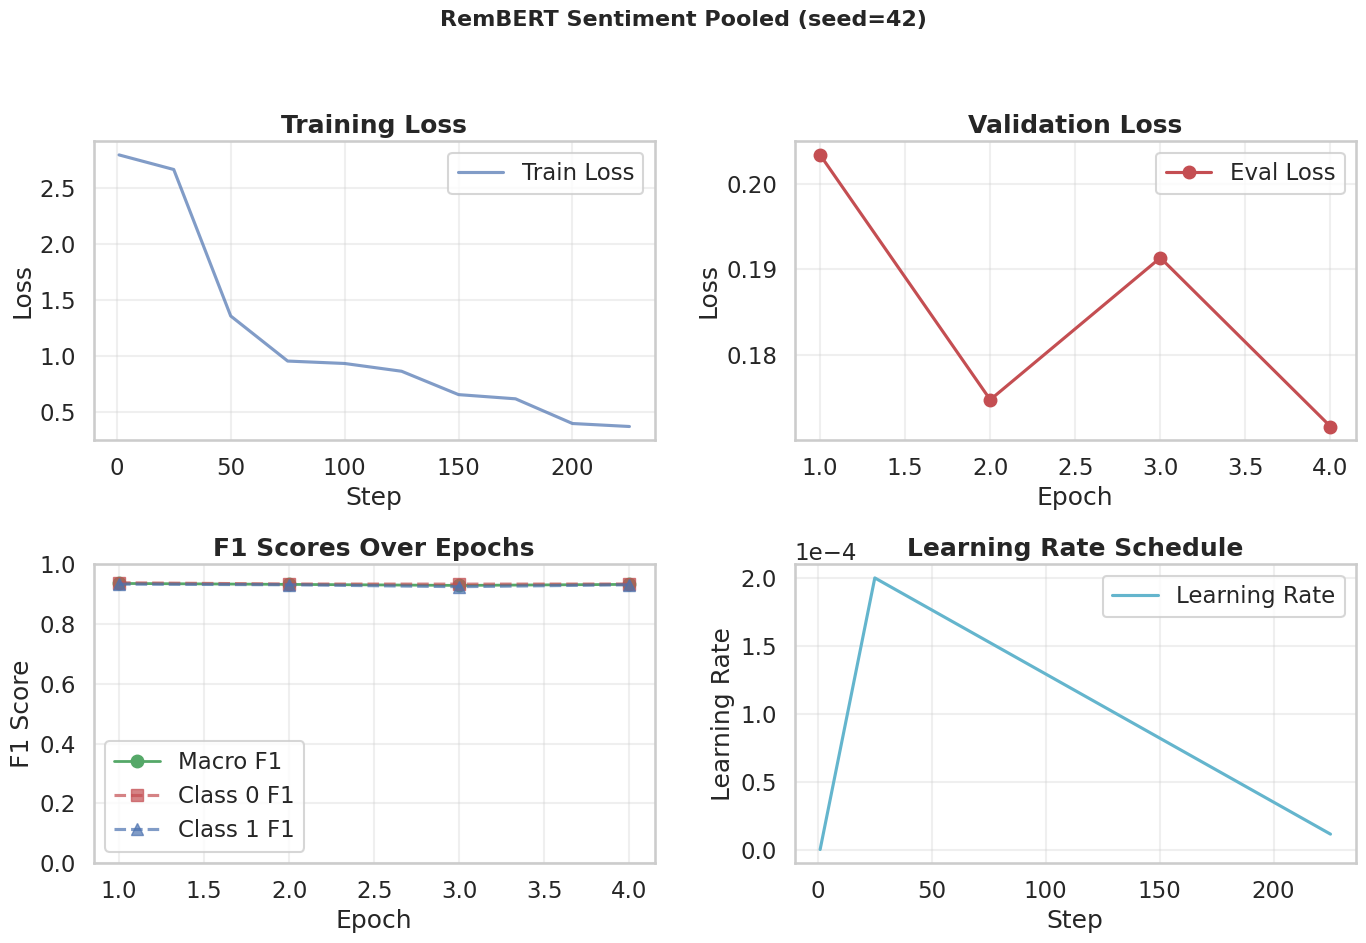

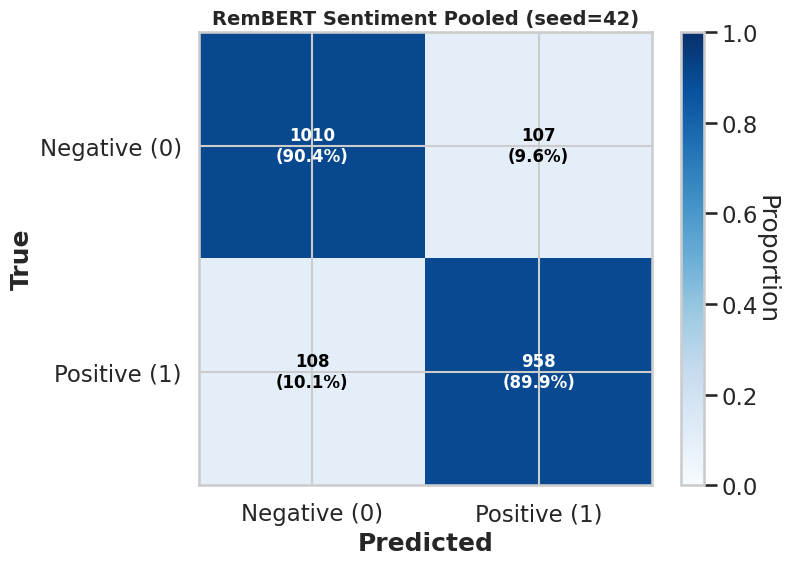

    -> Macro F1: 0.9015, Accuracy: 0.9015

  [Sentiment] Pooled training, seed=123


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,1.284886,0.252578,0.904153,0.904145,0.905317,0.904820,0.904124,0.905944,0.904153,0.903226,0.905063,0.965176,0.959855
2,0.952832,0.175622,0.939297,0.939235,0.939591,0.939052,0.939279,0.939433,0.939297,0.941176,0.937294,0.983660,0.984154
3,0.594915,0.183258,0.923323,0.923322,0.923995,0.923856,0.923316,0.924518,0.923323,0.923077,0.923567,0.980739,0.984954
4,0.314227,0.184893,0.939297,0.939275,0.939231,0.939338,0.939301,0.939324,0.939297,0.940439,0.938111,0.980494,0.985117


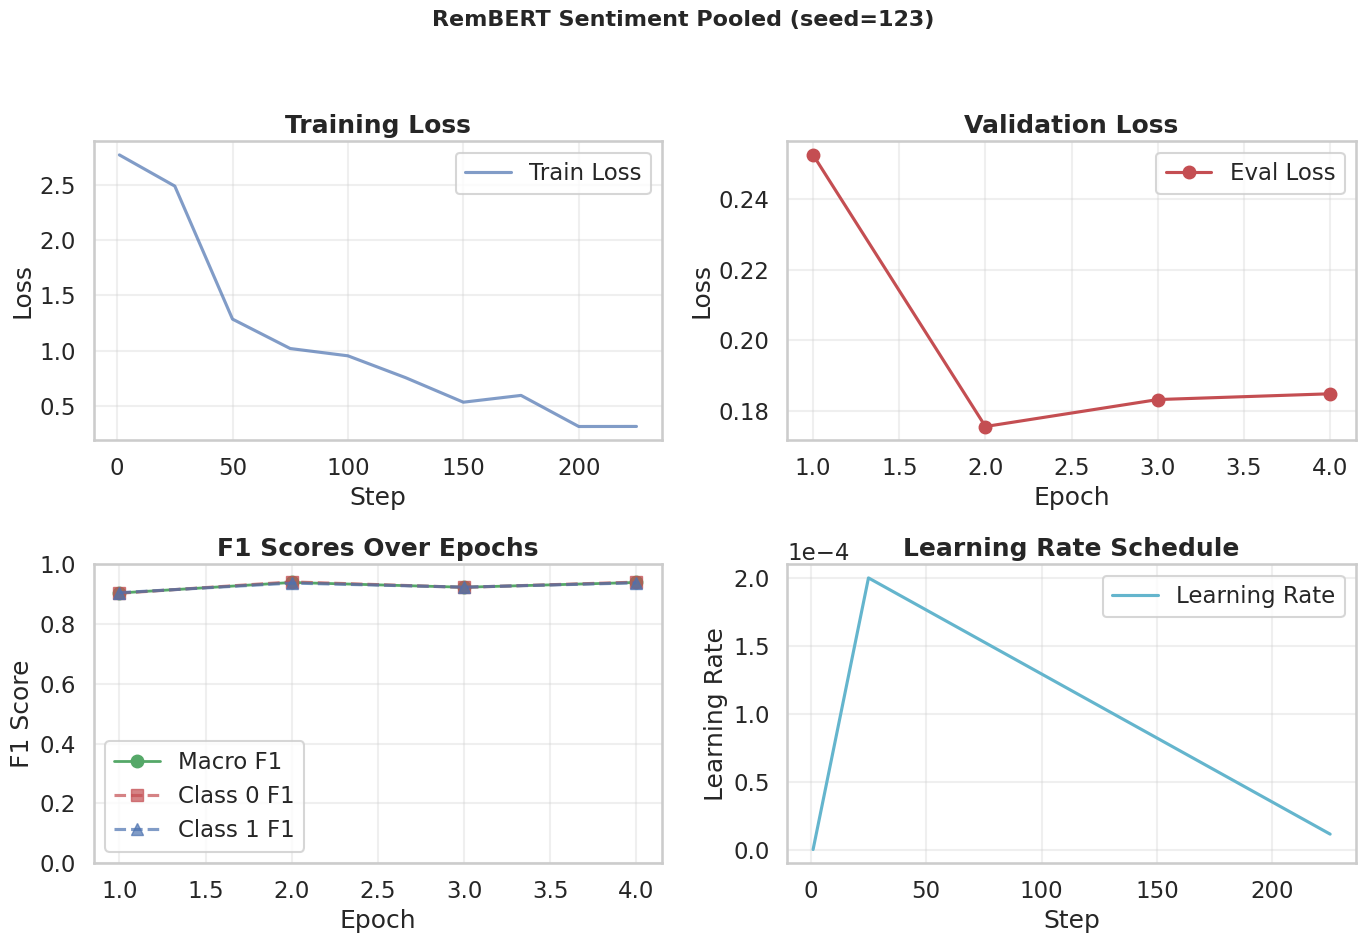

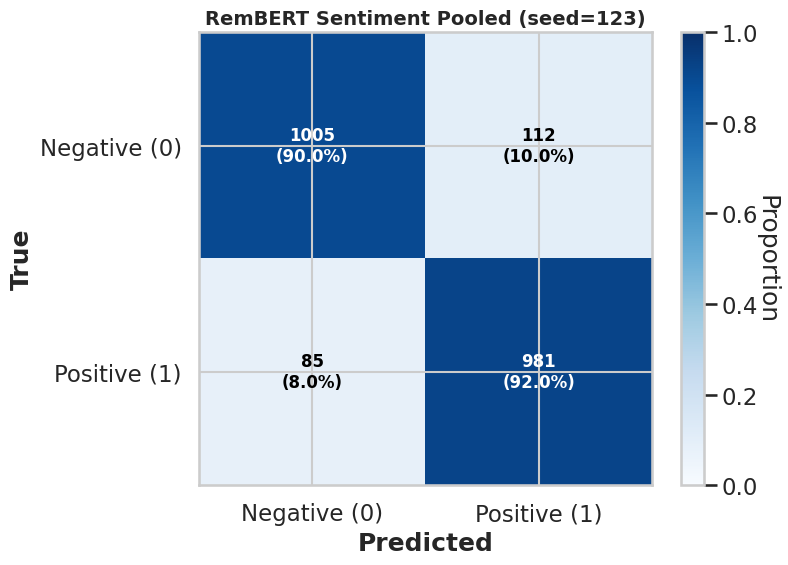

    -> Macro F1: 0.9097, Accuracy: 0.9098

  [Sentiment] Pooled training, seed=456


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,1.213284,0.198951,0.929712,0.929654,0.929850,0.929534,0.929700,0.929763,0.929712,0.931677,0.927632,0.980188,0.982712
2,0.947866,0.223687,0.926518,0.926370,0.927693,0.925980,0.926444,0.927301,0.926518,0.929664,0.923077,0.982128,0.983132
3,0.619072,0.161480,0.939297,0.939257,0.939339,0.939195,0.939292,0.939306,0.939297,0.940810,0.937705,0.983599,0.985815
4,0.366679,0.176269,0.932907,0.932839,0.933190,0.932659,0.932887,0.933038,0.932907,0.934985,0.930693,0.985233,0.986606


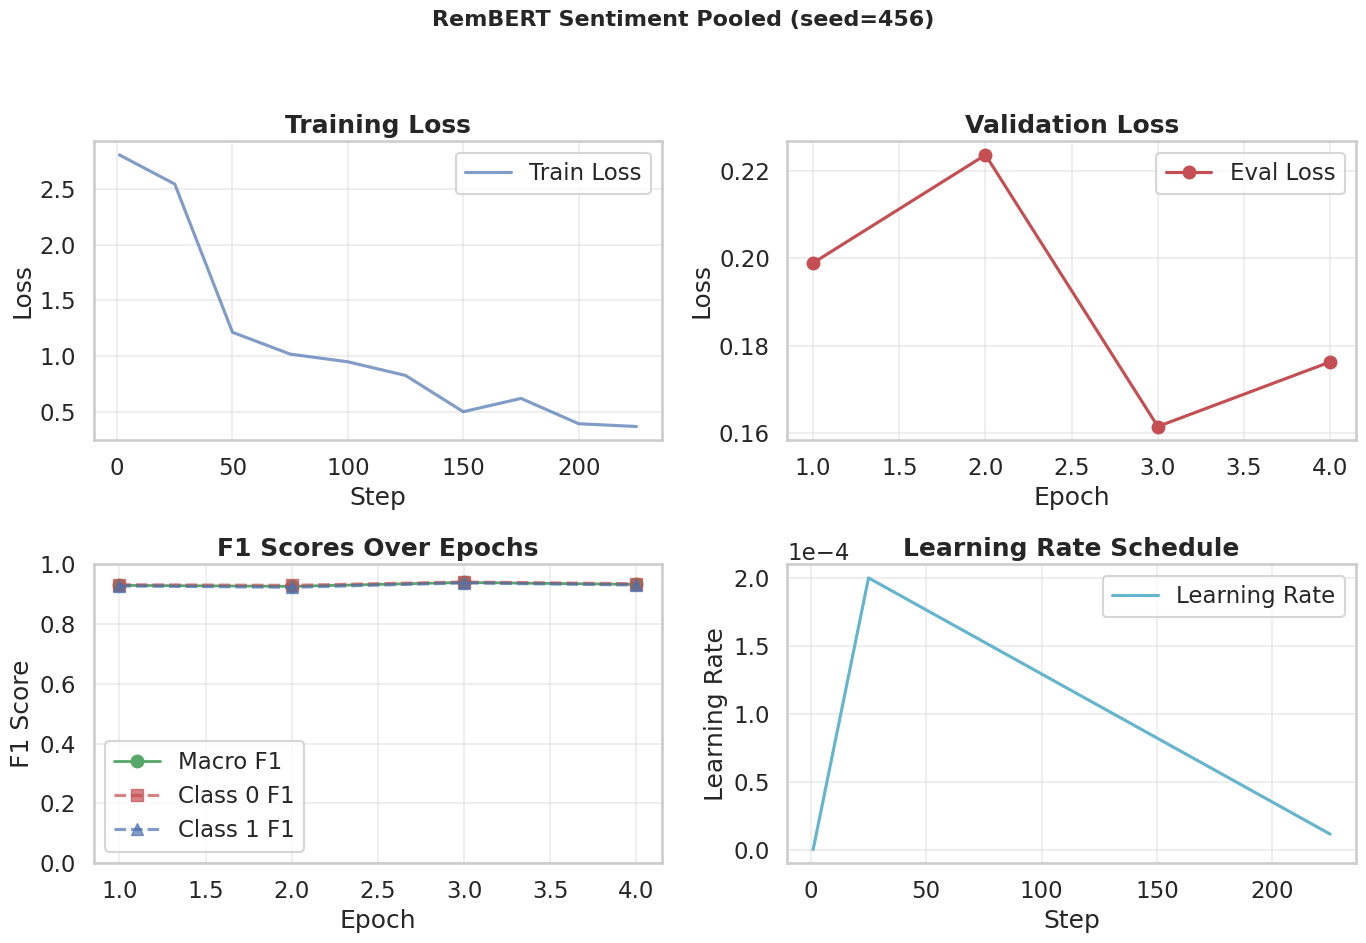

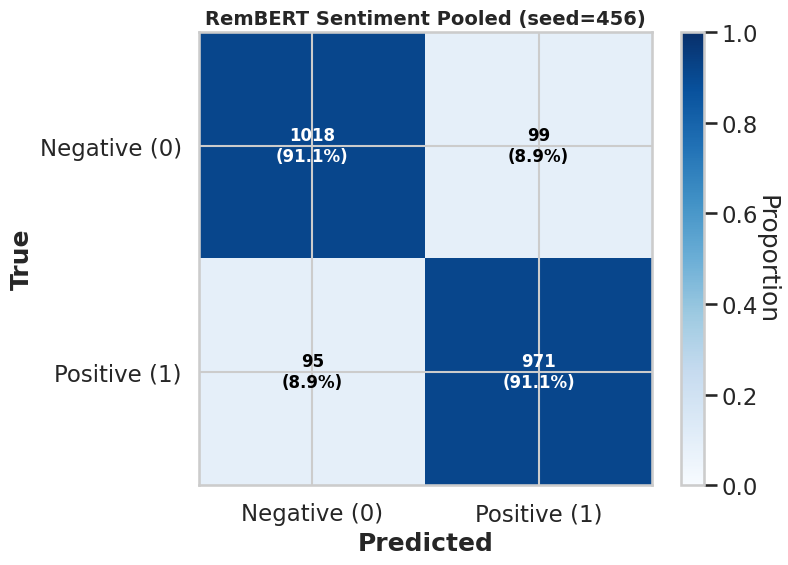

    -> Macro F1: 0.9111, Accuracy: 0.9111

  Pooled Results Summary:
    Mean Macro F1: 0.9074 (+/- 0.0052)

>>> Cross-Variety Training

  [Sentiment] Cross training: en-AU, seed=42


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,1.920424,0.487343,0.654952,0.596649,0.640266,0.789752,0.706885,0.894451,0.654952,0.750000,0.443299,0.855483,0.441100
2,1.728771,0.432323,0.821086,0.711331,0.685210,0.781852,0.839284,0.875099,0.821086,0.889328,0.533333,0.877661,0.504963
3,1.356098,0.434407,0.792332,0.689716,0.668690,0.784133,0.817986,0.874761,0.792332,0.868154,0.511278,0.878380,0.514518
4,0.694000,0.674500,0.840256,0.716074,0.693934,0.754985,0.851054,0.868126,0.840256,0.903846,0.528302,0.876816,0.500312


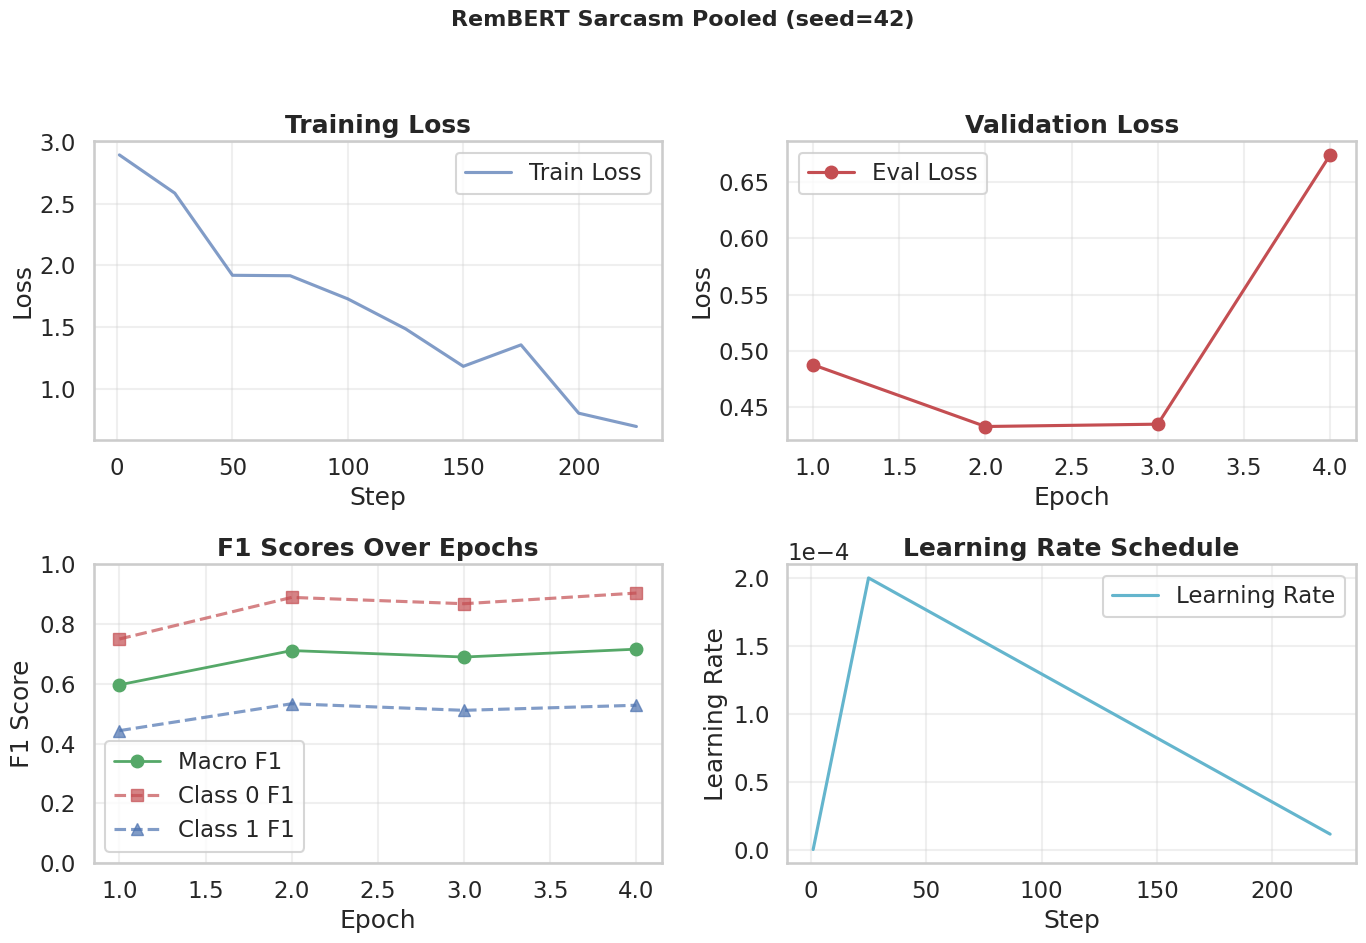

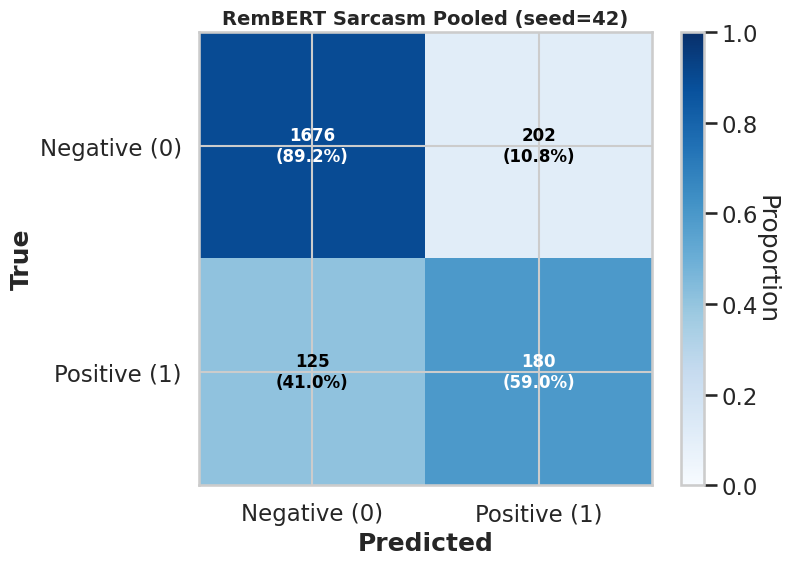

    -> Macro F1: 0.7176, Accuracy: 0.8502

  [Sarcasm] Pooled training, seed=123


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,1.991546,0.427518,0.795527,0.702542,0.680827,0.814507,0.822094,0.887287,0.795527,0.868852,0.536232,0.881168,0.500939
2,1.700190,0.422869,0.747604,0.658321,0.652568,0.786626,0.783875,0.877653,0.747604,0.832981,0.483660,0.863594,0.476111
3,1.163954,0.457529,0.856230,0.750058,0.721960,0.802298,0.867160,0.887046,0.856230,0.912959,0.587156,0.889785,0.566077
4,0.748883,0.614396,0.849840,0.708375,0.697126,0.722541,0.854383,0.859973,0.849840,0.911488,0.505263,0.885645,0.555344


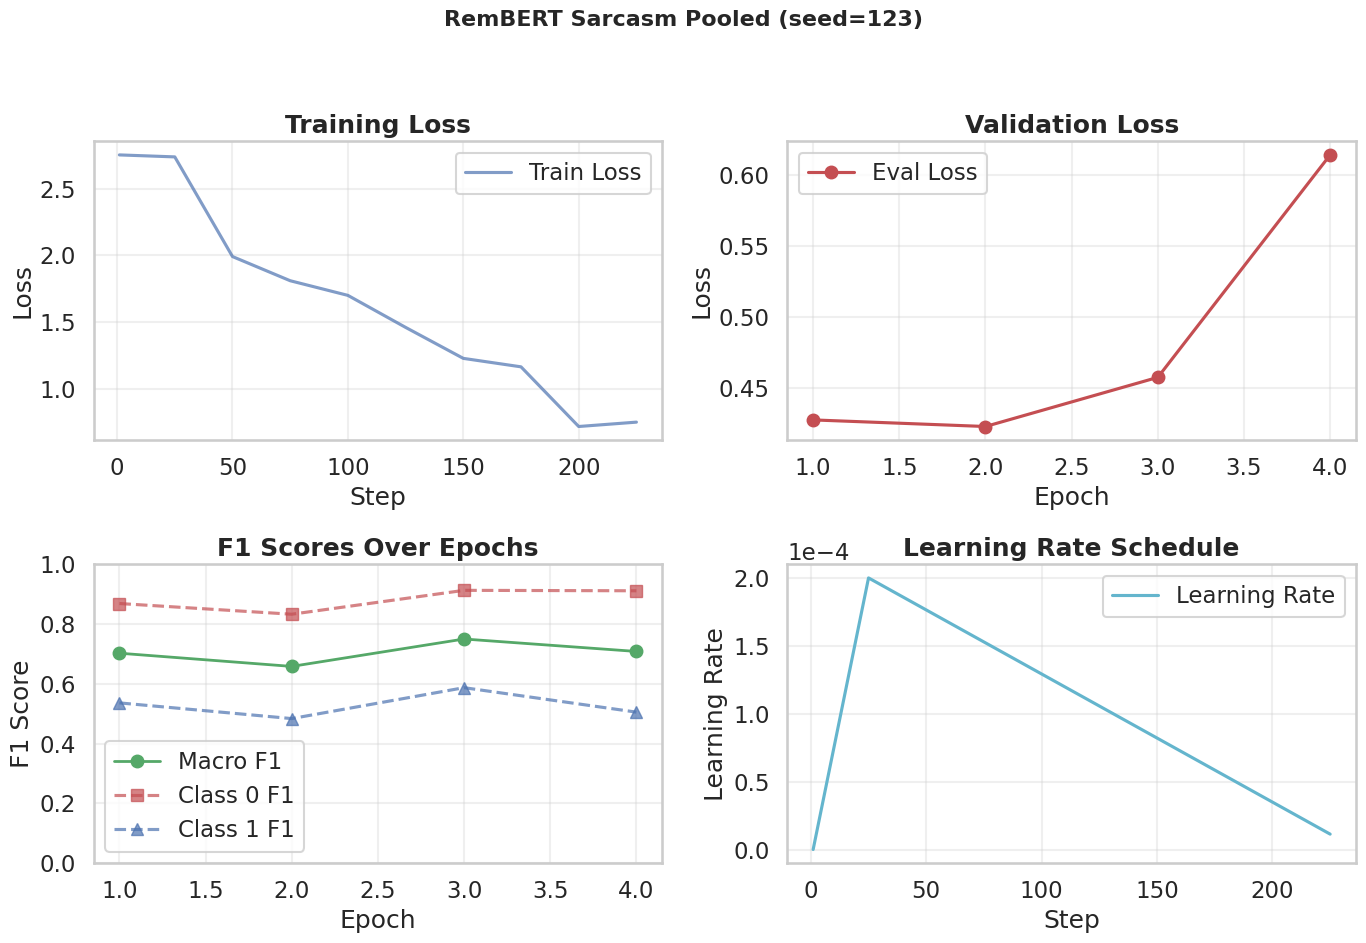

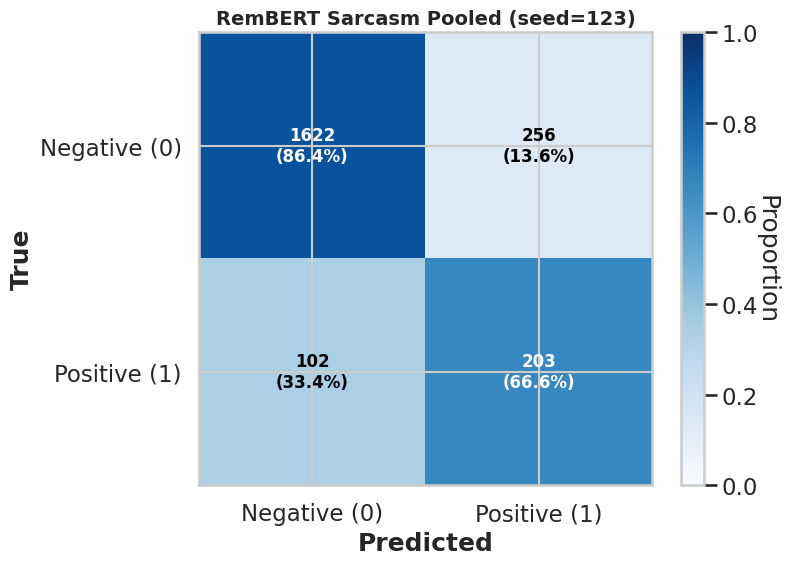

    -> Macro F1: 0.7160, Accuracy: 0.8360

  [Sarcasm] Pooled training, seed=456


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,2.070706,0.452420,0.760383,0.666610,0.655710,0.784556,0.793713,0.875818,0.760383,0.843424,0.489796,0.856751,0.448218
2,1.680522,0.376802,0.779553,0.698892,0.684307,0.843233,0.810921,0.900774,0.779553,0.854737,0.543046,0.899502,0.556915
3,1.162305,0.439499,0.805112,0.702198,0.678070,0.791568,0.828044,0.877961,0.805112,0.877264,0.527132,0.891686,0.576144
4,0.585682,0.575345,0.849840,0.735094,0.710095,0.779571,0.860424,0.878238,0.849840,0.909441,0.560748,0.892700,0.565448


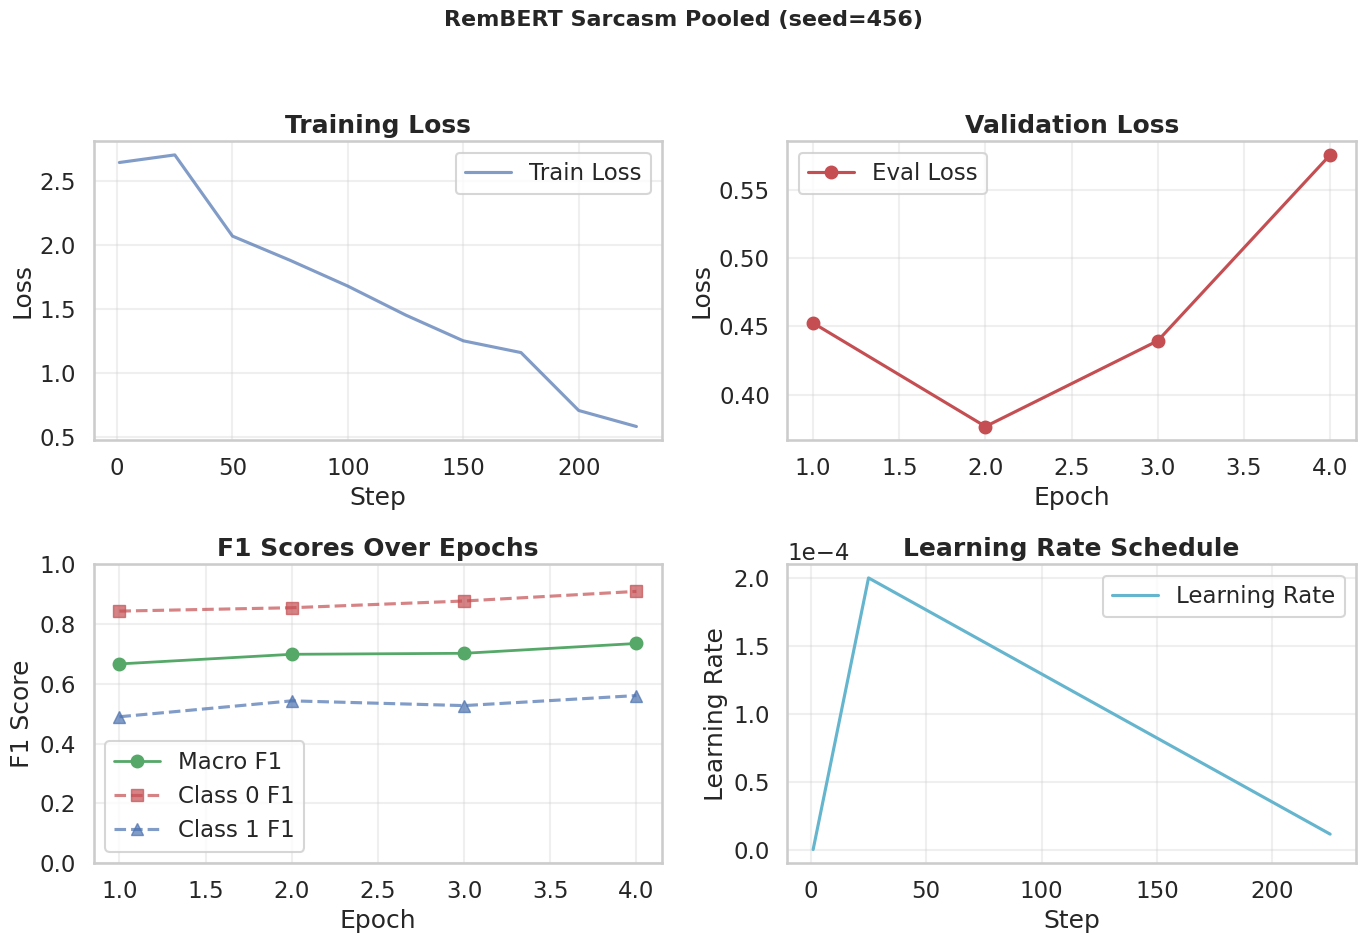

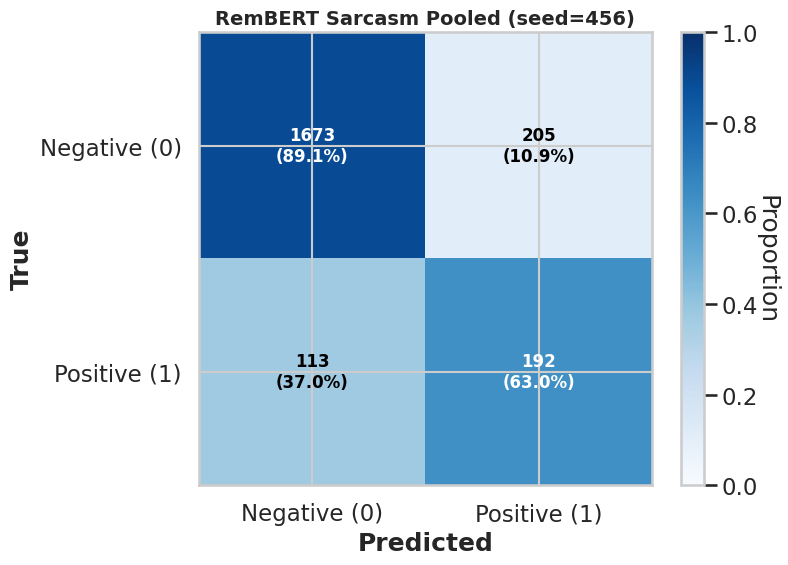

    -> Macro F1: 0.7301, Accuracy: 0.8543

  Pooled Results Summary:
    Mean Macro F1: 0.7212 (+/- 0.0077)

>>> Cross-Variety Training

  [Sarcasm] Cross training: en-AU, seed=42


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,2.070706,0.452420,0.760383,0.666610,0.655710,0.784556,0.793713,0.875818,0.760383,0.843424,0.489796,0.856751,0.448218
2,1.680522,0.376802,0.779553,0.698892,0.684307,0.843233,0.810921,0.900774,0.779553,0.854737,0.543046,0.899502,0.556915
3,1.162305,0.439499,0.805112,0.702198,0.678070,0.791568,0.828044,0.877961,0.805112,0.877264,0.527132,0.891686,0.576144
4,0.585682,0.575345,0.849840,0.735094,0.710095,0.779571,0.860424,0.878238,0.849840,0.909441,0.560748,0.892700,0.565448



  Combined Results by Variety:
    en-AU: F1=0.7592
    en-IN: F1=0.6167
    en-UK: F1=0.6878

  Saved all results to: /scratch/HS400/outputs_rembert/sarcasm

ALL EXPERIMENTS COMPLETED!


In [ ]:
# Run all experiments for both tasks
all_task_results = {}

for task_name in TASKS:
    print(f"\n{'='*90}")
    print(f"RUNNING FULL PIPELINE FOR TASK: {task_name.upper()}")
    print(f"{'='*90}")
    
    # Pooled
    print(f"\n>>> Pooled Training")
    task_dir = task_out_dir(task_name)
    if (task_dir / 'pooled_results.pkl').exists():
        with open(task_dir / 'pooled_results.pkl', 'rb') as f:
            pooled_results_task = pickle.load(f)
        print(f"  Loaded pooled results from cache")
    else:
        pooled_results_task = [run_pooled_for_task(task_name, s, save_plots=True) for s in SEEDS]
    pooled_df_task = pd.DataFrame([{
        'seed': r['seed'],
        'accuracy': r['accuracy'],
        'macro_f1': r['macro_f1'],
        'macro_precision': r['macro_precision'],
        'macro_recall': r['macro_recall'],
        'weighted_f1': r['weighted_f1'],
        'roc_auc': r.get('roc_auc', np.nan),
        'inference_time_sec': r.get('inference_time_sec', np.nan),
        'samples_per_sec': r.get('samples_per_sec', np.nan),
        'checkpoint_dir': r['checkpoint_dir'],
        'final_model_dir': r['final_model_dir'],
    } for r in pooled_results_task])
    
    print(f"\n  Pooled Results Summary:")
    print(f"    Mean Macro F1: {pooled_df_task['macro_f1'].mean():.4f} (+/- {pooled_df_task['macro_f1'].std():.4f})")
    
    # Cross
    print(f"\n>>> Cross-Variety Training")
    if (task_dir / 'cross_raw_results.pkl').exists():
        with open(task_dir / 'cross_raw_results.pkl', 'rb') as f:
            cross_raw = pickle.load(f)
        print(f"  Loaded cross-variety results from cache")
    else:
        cross_raw = {}
        for tr in VARIETIES:
            for s in SEEDS:
                cross_raw[(tr, s)] = run_cross_for_task(task_name, tr, s, save_plots=False)
    
    cross_rows = []
    for tr in VARIETIES:
        for te in VARIETIES:
            metrics = [cross_raw[(tr, s)][te] for s in SEEDS]
            row = {
                'train_variety': tr,
                'test_variety': te,
                'route': f'{tr}→{te}',
            }
            for m in ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall', 'weighted_f1', 'roc_auc', 'inference_time_sec', 'samples_per_sec']:
                vals = [met.get(m, np.nan) for met in metrics]
                row[f'{m}_mean'] = float(np.nanmean(vals))
                row[f'{m}_std'] = float(np.nanstd(vals))
            cross_rows.append(row)
    cross_df_task = pd.DataFrame(cross_rows)
    
    best_route = cross_df_task.sort_values('macro_f1_mean', ascending=False).iloc[0]
    worst_route = cross_df_task.sort_values('macro_f1_mean', ascending=True).iloc[0]
    print(f"\n  Cross Results - Best: {best_route['route']} (F1={best_route['macro_f1_mean']:.4f})")
    print(f"  Cross Results - Worst: {worst_route['route']} (F1={worst_route['macro_f1_mean']:.4f})")
    
    # Combined
    print(f"\n>>> Combined Training")
    if (task_dir / 'combined_raw_results.pkl').exists():
        with open(task_dir / 'combined_raw_results.pkl', 'rb') as f:
            combined_raw = pickle.load(f)
        print(f"  Loaded combined results from cache")
    else:
        combined_raw = {s: run_combined_for_task(task_name, s, save_plots=False) for s in SEEDS}
    
    combined_rows = []
    for tv in VARIETIES:
        metrics = [combined_raw[s][tv] for s in SEEDS]
        row = {
            'train_setup': 'combined_all_varieties',
            'test_variety': tv,
        }
        for m in ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall', 'weighted_f1', 'roc_auc', 'inference_time_sec', 'samples_per_sec']:
            vals = [met.get(m, np.nan) for met in metrics]
            row[f'{m}_mean'] = float(np.nanmean(vals))
            row[f'{m}_std'] = float(np.nanstd(vals))
        combined_rows.append(row)
    combined_df_task = pd.DataFrame(combined_rows)
    
    print(f"\n  Combined Results by Variety:")
    for _, row in combined_df_task.iterrows():
        print(f"    {row['test_variety']}: F1={row['macro_f1_mean']:.4f}")
    
    # Save all results
    pooled_df_task.to_csv(task_dir / 'pooled_results.csv', index=False)
    cross_df_task.to_csv(task_dir / 'cross_variety_results.csv', index=False)
    combined_df_task.to_csv(task_dir / 'combined_results.csv', index=False)
    
    with open(task_dir / 'pooled_results.pkl', 'wb') as f:
        pickle.dump(pooled_results_task, f)
    with open(task_dir / 'cross_raw_results.pkl', 'wb') as f:
        pickle.dump(cross_raw, f)
    with open(task_dir / 'combined_raw_results.pkl', 'wb') as f:
        pickle.dump(combined_raw, f)
    
    all_task_results[task_name] = {
        'pooled_results': pooled_results_task,
        'pooled_df': pooled_df_task,
        'cross_raw': cross_raw,
        'cross_df': cross_df_task,
        'combined_raw': combined_raw,
        'combined_df': combined_df_task,
    }
    
    print(f"\n  Saved all results to: {task_dir}")

# Save combined results
with open(OUT_DIR / 'all_task_results.pkl', 'wb') as f:
    pickle.dump(all_task_results, f)

print(f"\n{'='*90}")
print(f"ALL EXPERIMENTS COMPLETED!")
print(f"{'='*90}")



------------------------------------------------------------------------------------------
COMPREHENSIVE ANALYSIS: SENTIMENT
------------------------------------------------------------------------------------------

  POOLED TRAINING:
    Mean Macro F1: 0.9074 (+/- 0.0052)
    Mean Accuracy: 0.9075
    Mean ROC-AUC:  0.9646

  CROSS-VARIETY:
    Best route: en-UK→en-UK | F1=0.9643
    Worst route: en-AU→en-IN | F1=0.8018
    Same-variety avg F1: 0.9072
    Cross-variety avg F1: 0.8889
    Transfer gap: 0.0183

  COMBINED VS SINGLE-ROUTE:
test_variety  combined_f1  single_avg_f1  best_single_f1  delta_vs_avg
       en-AU     0.904233       0.895689        0.899054      0.008544
       en-IN     0.860958       0.832517        0.860774      0.028442
       en-UK     0.964245       0.956791        0.964260      0.007454


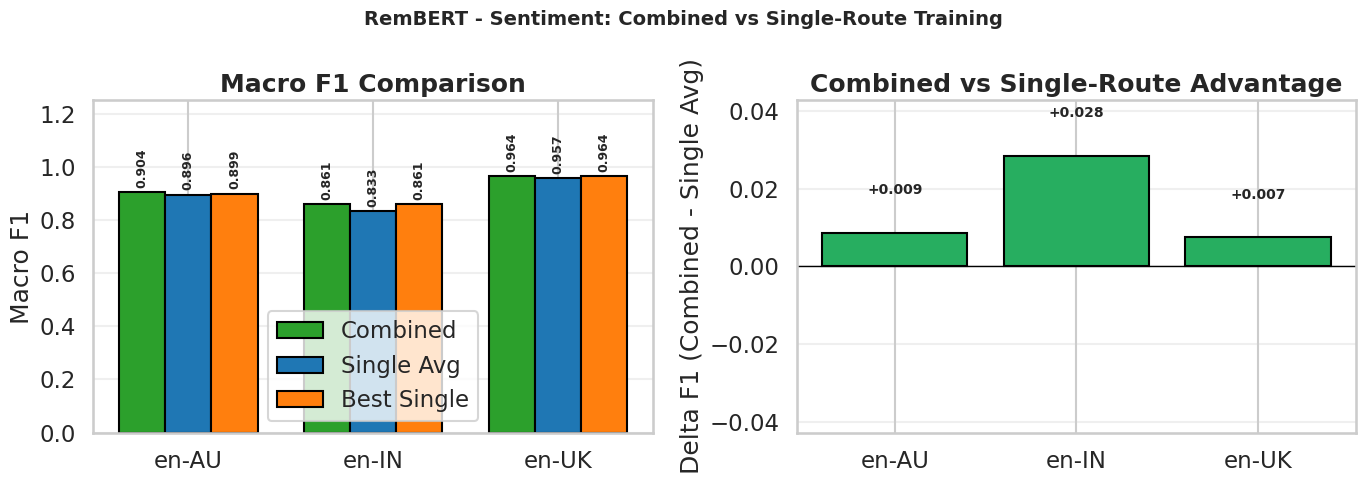

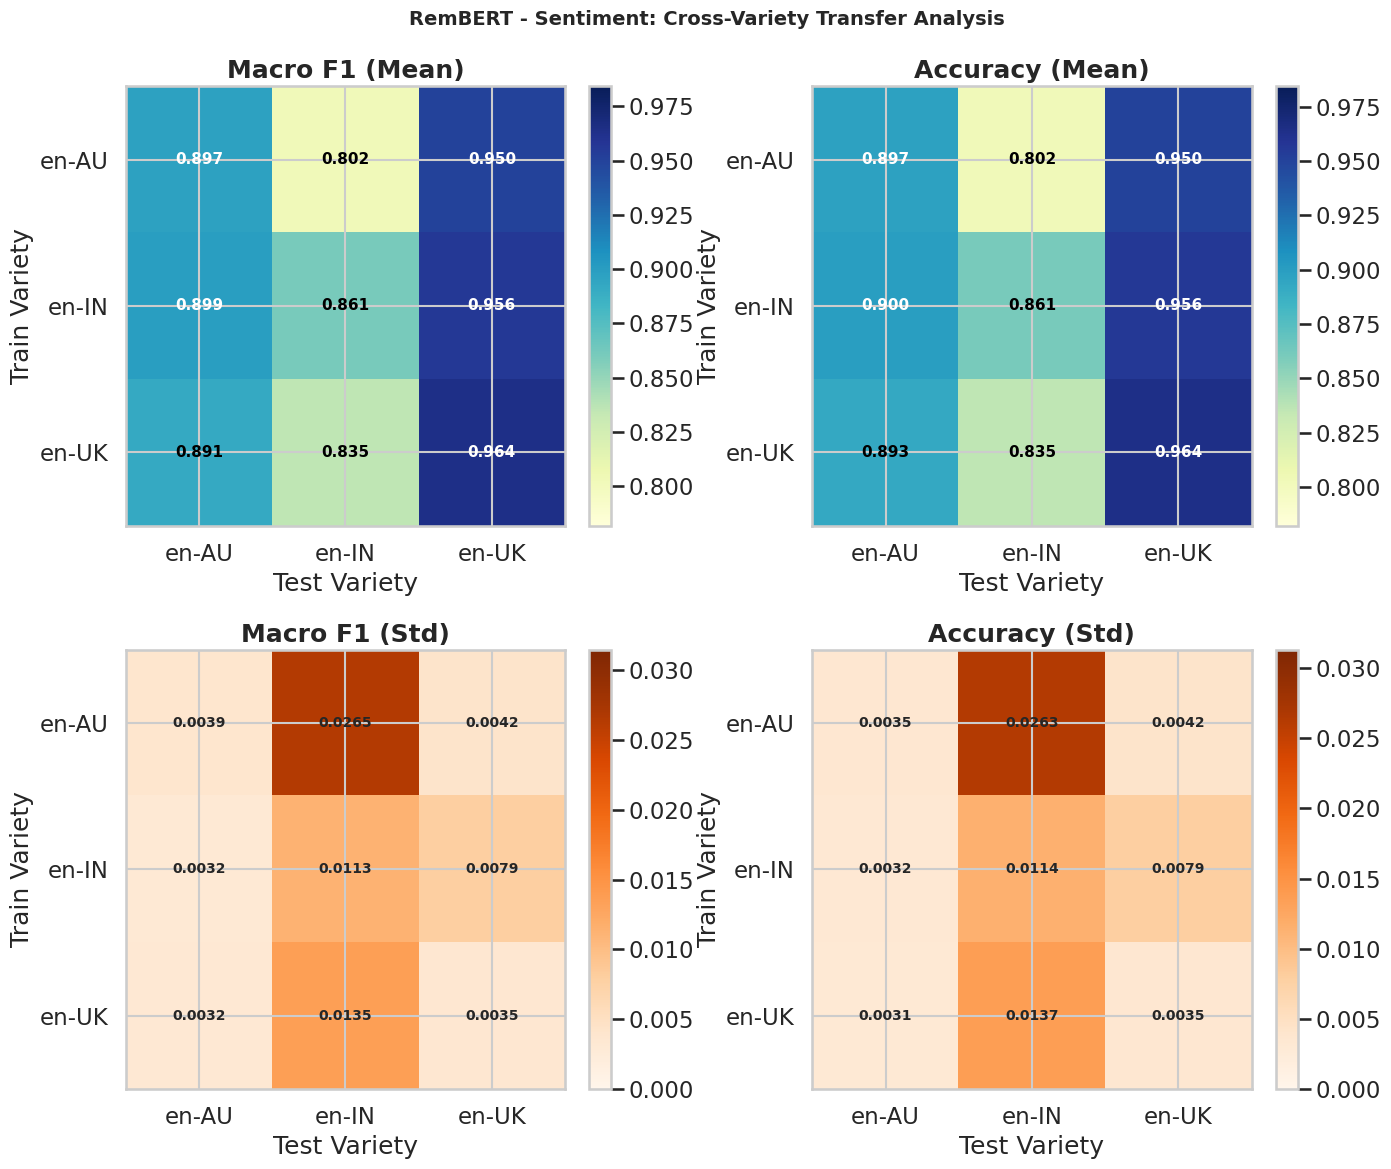

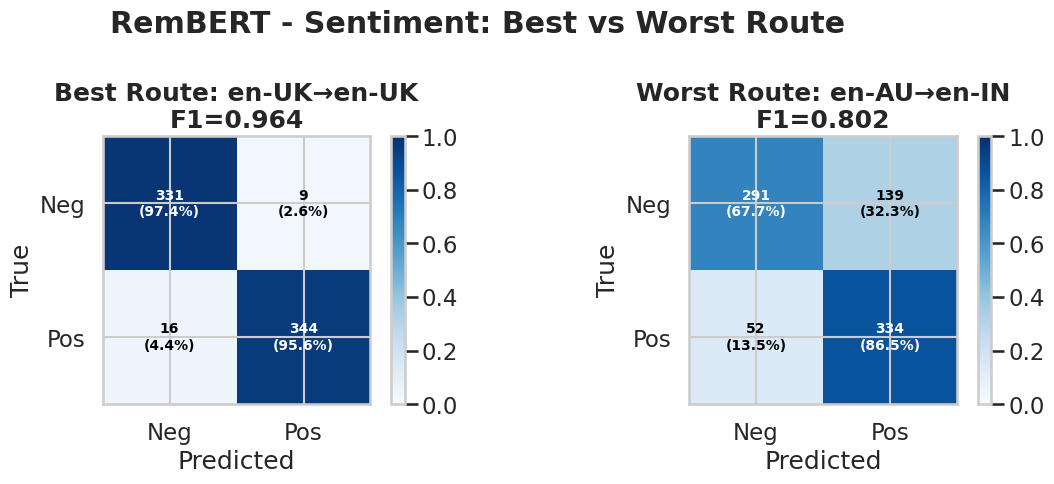


------------------------------------------------------------------------------------------
COMPREHENSIVE ANALYSIS: SARCASM
------------------------------------------------------------------------------------------

  POOLED TRAINING:
    Mean Macro F1: 0.7212 (+/- 0.0077)
    Mean Accuracy: 0.8468
    Mean ROC-AUC:  0.8770

  CROSS-VARIETY:
    Best route: en-AU→en-AU | F1=0.7528
    Worst route: en-AU→en-IN | F1=0.4891
    Same-variety avg F1: 0.6838
    Cross-variety avg F1: 0.5670
    Transfer gap: 0.1168

  COMBINED VS SINGLE-ROUTE:
test_variety  combined_f1  single_avg_f1  best_single_f1  delta_vs_avg
       en-AU     0.759204       0.636064        0.752796      0.123140
       en-IN     0.616717       0.549735        0.598574      0.066982
       en-UK     0.687782       0.632110        0.700078      0.055672


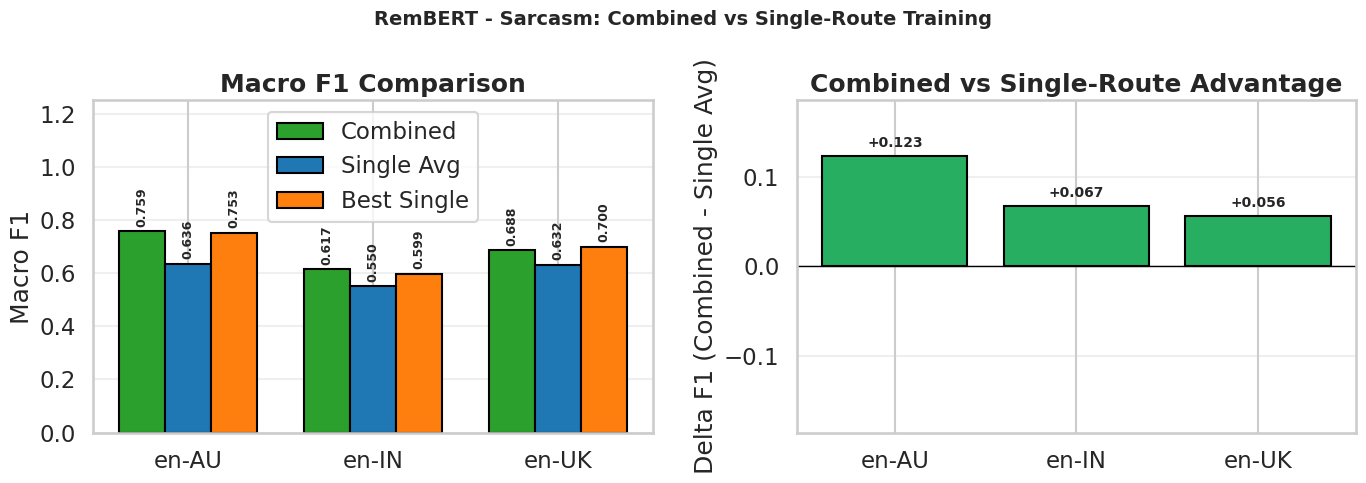

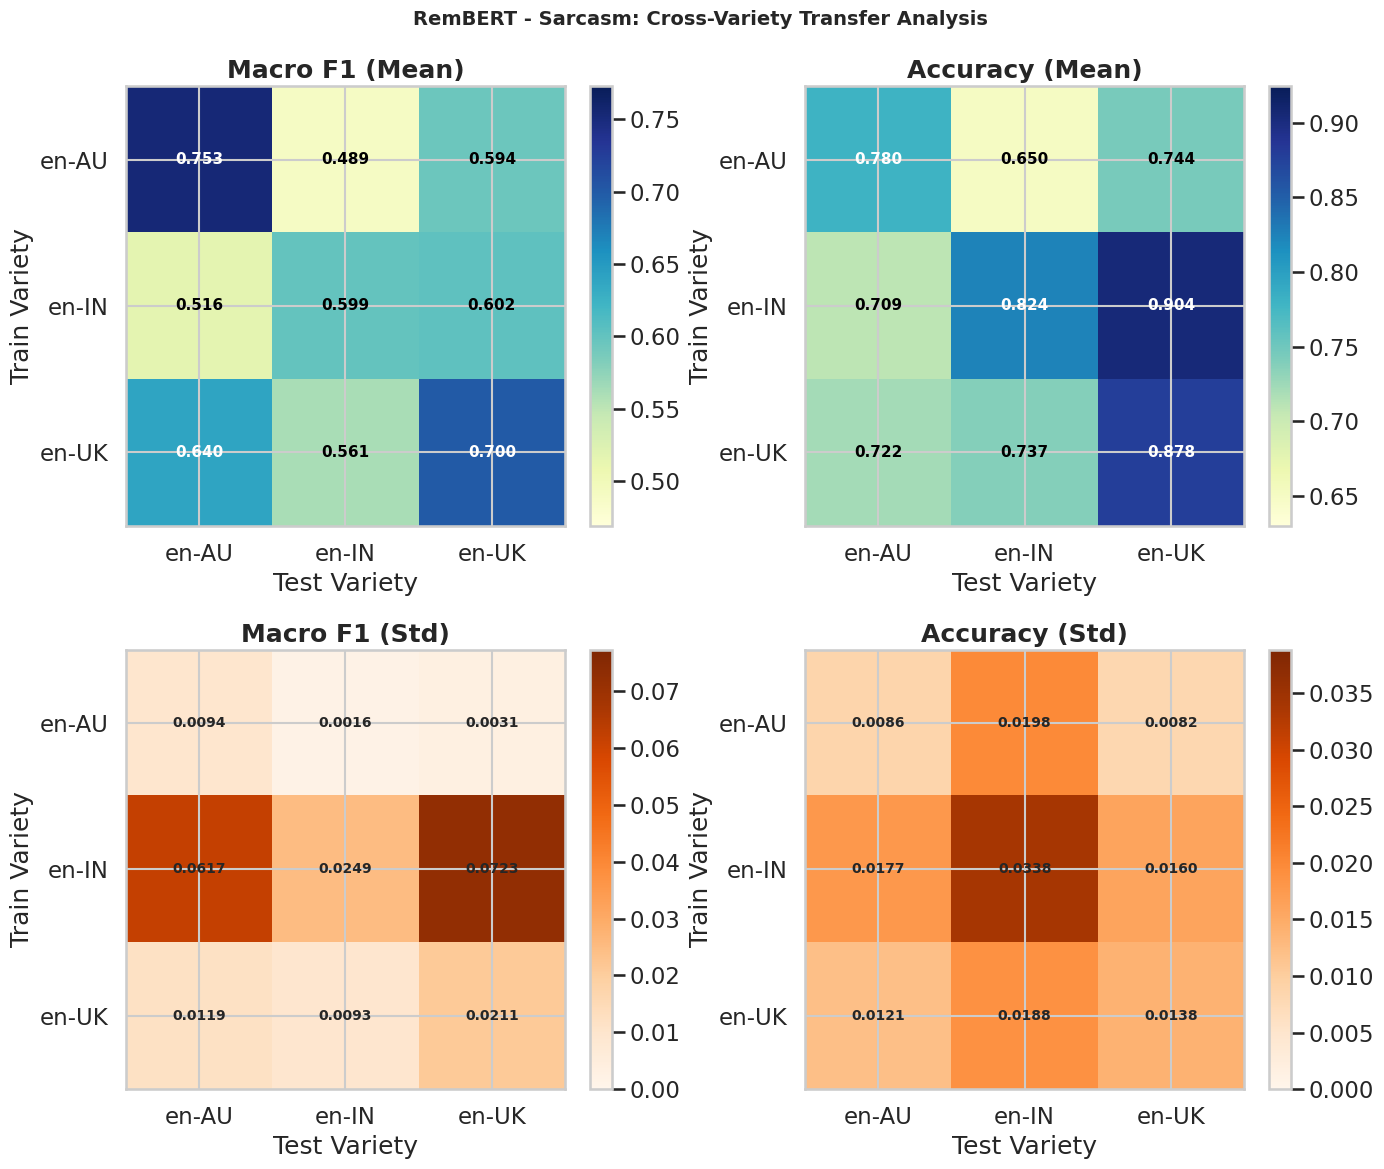

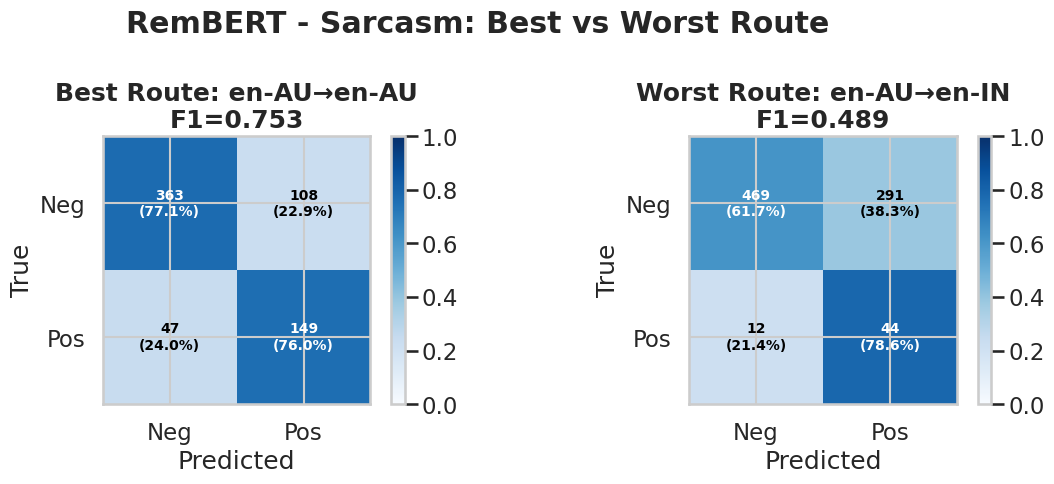


DUAL-TASK ANALYSIS COMPLETED!


In [28]:
# Dual-task comparisons and visualizations

def _best_worst(df):
    """Get best and worst routes from cross-variety DataFrame."""
    b = df.sort_values('macro_f1_mean', ascending=False).iloc[0]
    w = df.sort_values('macro_f1_mean', ascending=True).iloc[0]
    return b, w


for task_name in TASKS:
    if task_name not in all_task_results:
        continue
        
    print(f"\n{'-'*90}")
    print(f"COMPREHENSIVE ANALYSIS: {task_name.upper()}")
    print(f"{'-'*90}")
    
    pooled_df_task = all_task_results[task_name]['pooled_df']
    cross_df_task = all_task_results[task_name]['cross_df']
    combined_df_task = all_task_results[task_name]['combined_df']
    cross_raw = all_task_results[task_name]['cross_raw']
    combined_raw = all_task_results[task_name]['combined_raw']
    
    task_dir = task_out_dir(task_name)
    
    # Pooled summary
    print(f"\n  POOLED TRAINING:")
    print(f"    Mean Macro F1: {pooled_df_task['macro_f1'].mean():.4f} (+/- {pooled_df_task['macro_f1'].std():.4f})")
    print(f"    Mean Accuracy: {pooled_df_task['accuracy'].mean():.4f}")
    print(f"    Mean ROC-AUC:  {pooled_df_task['roc_auc'].mean():.4f}")
    
    # Cross-variety analysis
    b, w = _best_worst(cross_df_task)
    print(f"\n  CROSS-VARIETY:")
    print(f"    Best route: {b['route']} | F1={b['macro_f1_mean']:.4f}")
    print(f"    Worst route: {w['route']} | F1={w['macro_f1_mean']:.4f}")
    
    # Same-variety vs cross-variety comparison
    same_variety = cross_df_task[cross_df_task['train_variety'] == cross_df_task['test_variety']]
    diff_variety = cross_df_task[cross_df_task['train_variety'] != cross_df_task['test_variety']]
    print(f"    Same-variety avg F1: {same_variety['macro_f1_mean'].mean():.4f}")
    print(f"    Cross-variety avg F1: {diff_variety['macro_f1_mean'].mean():.4f}")
    print(f"    Transfer gap: {same_variety['macro_f1_mean'].mean() - diff_variety['macro_f1_mean'].mean():.4f}")
    
    # Combined vs single comparison
    print(f"\n  COMBINED VS SINGLE-ROUTE:")
    cmp_rows = []
    for tv in VARIETIES:
        combined_f1 = float(combined_df_task[combined_df_task.test_variety == tv]['macro_f1_mean'].iloc[0])
        combined_acc = float(combined_df_task[combined_df_task.test_variety == tv]['accuracy_mean'].iloc[0])
        
        # Average across all training routes for this test variety
        single_avg_f1 = float(cross_df_task[cross_df_task.test_variety == tv]['macro_f1_mean'].mean())
        single_avg_acc = float(cross_df_task[cross_df_task.test_variety == tv]['accuracy_mean'].mean())
        
        # Best single route for this test variety
        best_single = cross_df_task[cross_df_task.test_variety == tv].sort_values('macro_f1_mean', ascending=False).iloc[0]
        
        cmp_rows.append({
            'test_variety': tv,
            'combined_f1': combined_f1,
            'combined_acc': combined_acc,
            'single_avg_f1': single_avg_f1,
            'single_avg_acc': single_avg_acc,
            'best_single_f1': best_single['macro_f1_mean'],
            'best_single_route': best_single['route'],
            'delta_vs_avg': combined_f1 - single_avg_f1,
            'delta_vs_best': combined_f1 - best_single['macro_f1_mean'],
        })
    
    cmp_df = pd.DataFrame(cmp_rows)
    cmp_df.to_csv(task_dir / 'combined_vs_single_comparison.csv', index=False)
    print(cmp_df[['test_variety', 'combined_f1', 'single_avg_f1', 'best_single_f1', 'delta_vs_avg']].to_string(index=False))
    
    # Plot: combined vs single comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # F1 comparison
    x = np.arange(len(VARIETIES))
    width = 0.25
    axes[0].bar(x - width, cmp_df['combined_f1'], width, label='Combined', color='#2ca02c', edgecolor='black')
    axes[0].bar(x, cmp_df['single_avg_f1'], width, label='Single Avg', color='#1f77b4', edgecolor='black')
    axes[0].bar(x + width, cmp_df['best_single_f1'], width, label='Best Single', color='#ff7f0e', edgecolor='black')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(VARIETIES)
    axes[0].set_ylim(0, 1.25)
    axes[0].set_ylabel('Macro F1')
    axes[0].set_title('Macro F1 Comparison', fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.3f', padding=3, fontsize=9, fontweight='bold', rotation=90)
    
    # Delta comparison
    colors = ['#27ae60' if d > 0 else '#e74c3c' for d in cmp_df['delta_vs_avg']]
    axes[1].bar(VARIETIES, cmp_df['delta_vs_avg'], color=colors, edgecolor='black')
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_ylabel('Delta F1 (Combined - Single Avg)')
    axes[1].set_title('Combined vs Single-Route Advantage', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    y_max = cmp_df['delta_vs_avg'].abs().max()
    if y_max == 0: y_max = 0.1 # Fallback just in case
    axes[1].set_ylim(-y_max * 1.50, y_max * 1.50)
    
    # Add value labels
    for i, (v, d) in enumerate(zip(VARIETIES, cmp_df['delta_vs_avg'])):
        axes[1].text(i, d + 0.01 if d > 0 else d - 0.02, f'{d:+.3f}', 
                    ha='center', fontsize=10, fontweight='bold')
    
    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Combined vs Single-Route Training', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(task_dir / 'combined_vs_single_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Plot: cross-variety heatmaps (mean and std)
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    metrics_to_plot = [('macro_f1', 'Macro F1'), ('accuracy', 'Accuracy')]
    
    for col_idx, (metric, title) in enumerate(metrics_to_plot):
        mean_matrix = np.zeros((len(VARIETIES), len(VARIETIES)))
        std_matrix = np.zeros((len(VARIETIES), len(VARIETIES)))
        
        for i, tr in enumerate(VARIETIES):
            for j, te in enumerate(VARIETIES):
                row = cross_df_task[(cross_df_task.train_variety == tr) & (cross_df_task.test_variety == te)].iloc[0]
                mean_matrix[i, j] = row[f'{metric}_mean']
                std_matrix[i, j] = row[f'{metric}_std']
        
        # Mean heatmap
        im1 = axes[0, col_idx].imshow(mean_matrix, cmap='YlGnBu', 
                                       vmin=max(0.3, mean_matrix.min()-0.02), 
                                       vmax=min(1.0, mean_matrix.max()+0.02))
        axes[0, col_idx].set_title(f'{title} (Mean)', fontweight='bold')
        axes[0, col_idx].set_xticks(range(len(VARIETIES)))
        axes[0, col_idx].set_yticks(range(len(VARIETIES)))
        axes[0, col_idx].set_xticklabels(VARIETIES)
        axes[0, col_idx].set_yticklabels(VARIETIES)
        axes[0, col_idx].set_xlabel('Test Variety')
        axes[0, col_idx].set_ylabel('Train Variety')
        
        for i in range(len(VARIETIES)):
            for j in range(len(VARIETIES)):
                color = 'white' if mean_matrix[i, j] > np.mean(mean_matrix) else 'black'
                axes[0, col_idx].text(j, i, f'{mean_matrix[i,j]:.3f}', ha='center', va='center',
                                      fontweight='bold', fontsize=11, color=color)
        plt.colorbar(im1, ax=axes[0, col_idx], fraction=0.046)
        
        # Std heatmap
        im2 = axes[1, col_idx].imshow(std_matrix, cmap='Oranges', 
                                       vmin=0, vmax=max(0.01, std_matrix.max()+0.005))
        axes[1, col_idx].set_title(f'{title} (Std)', fontweight='bold')
        axes[1, col_idx].set_xticks(range(len(VARIETIES)))
        axes[1, col_idx].set_yticks(range(len(VARIETIES)))
        axes[1, col_idx].set_xticklabels(VARIETIES)
        axes[1, col_idx].set_yticklabels(VARIETIES)
        axes[1, col_idx].set_xlabel('Test Variety')
        axes[1, col_idx].set_ylabel('Train Variety')
        
        for i in range(len(VARIETIES)):
            for j in range(len(VARIETIES)):
                axes[1, col_idx].text(j, i, f'{std_matrix[i,j]:.4f}', ha='center', va='center',
                                      fontweight='bold', fontsize=10)
        plt.colorbar(im2, ax=axes[1, col_idx], fraction=0.046)
    
    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Cross-Variety Transfer Analysis', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(task_dir / 'cross_variety_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Plot: best/worst route confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for ax, (route_row, title) in zip(axes, [(b, 'Best Route'), (w, 'Worst Route')]):
        train_v, test_v = route_row['train_variety'], route_row['test_variety']
        cm = cross_raw[(train_v, SEEDS[0])][test_v]['cm']
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f'{title}: {train_v}→{test_v}\nF1={route_row["macro_f1_mean"]:.3f}', fontweight='bold')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Neg', 'Pos'])
        ax.set_yticklabels(['Neg', 'Pos'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        
        for i in range(2):
            for j in range(2):
                color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.1%})', ha='center', va='center',
                       color=color, fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046)
    
    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Best vs Worst Route', fontweight='bold')
    plt.tight_layout()
    plt.savefig(task_dir / 'best_worst_route_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"\n{'='*90}")
print(f"DUAL-TASK ANALYSIS COMPLETED!")
print(f"{'='*90}")



>>> Generating comprehensive plots for: Sentiment


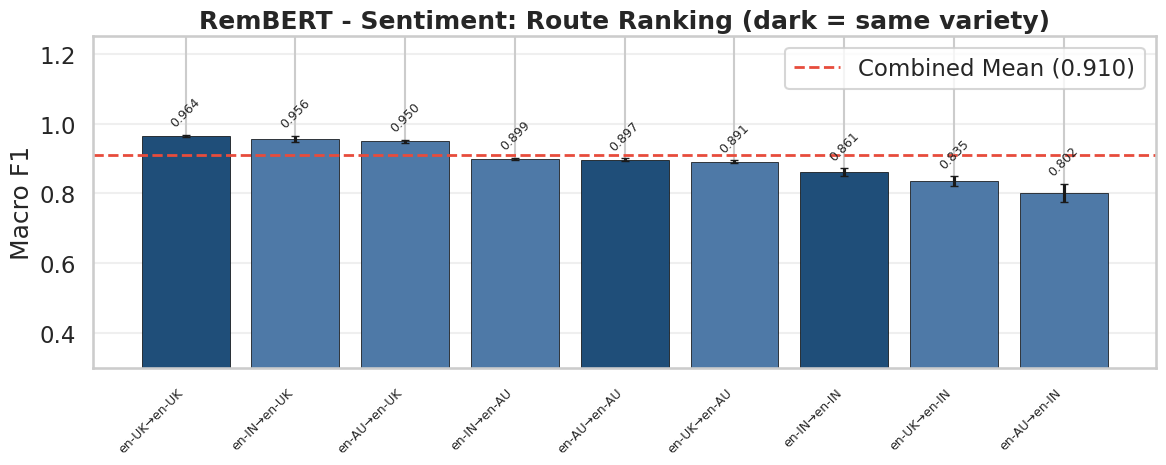

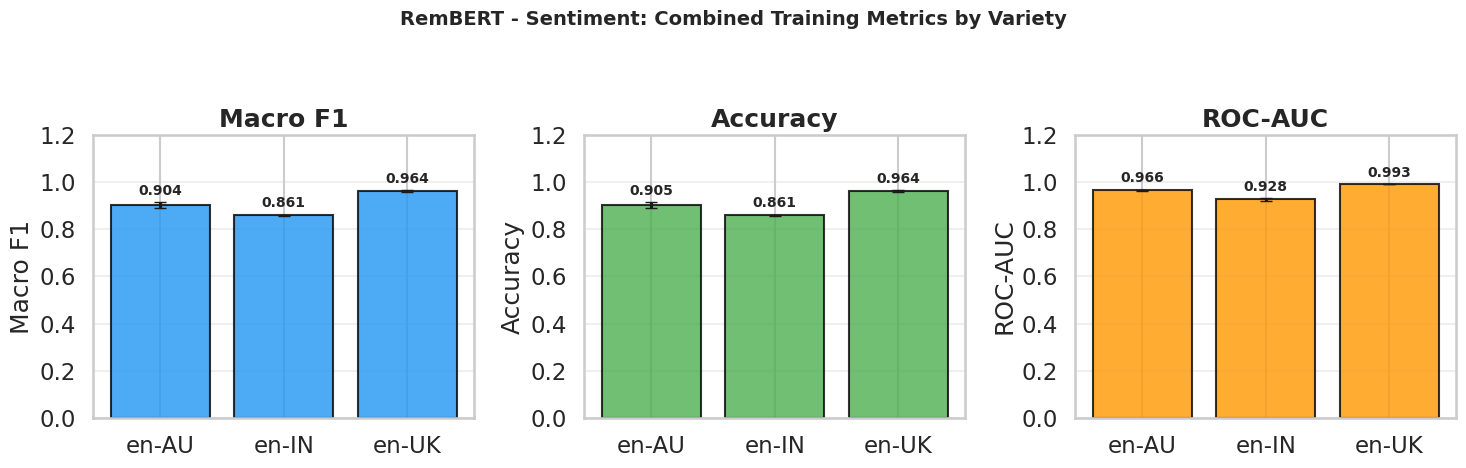

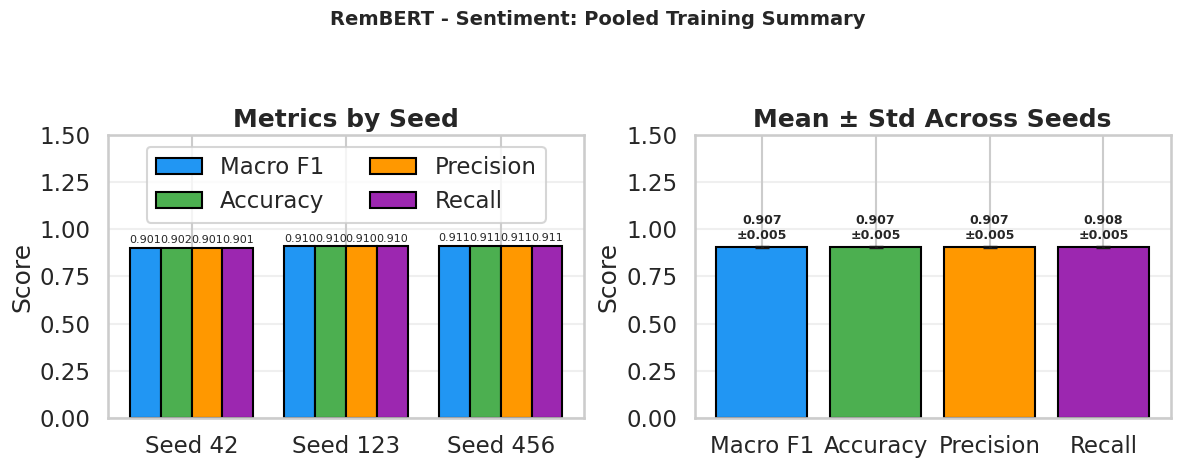

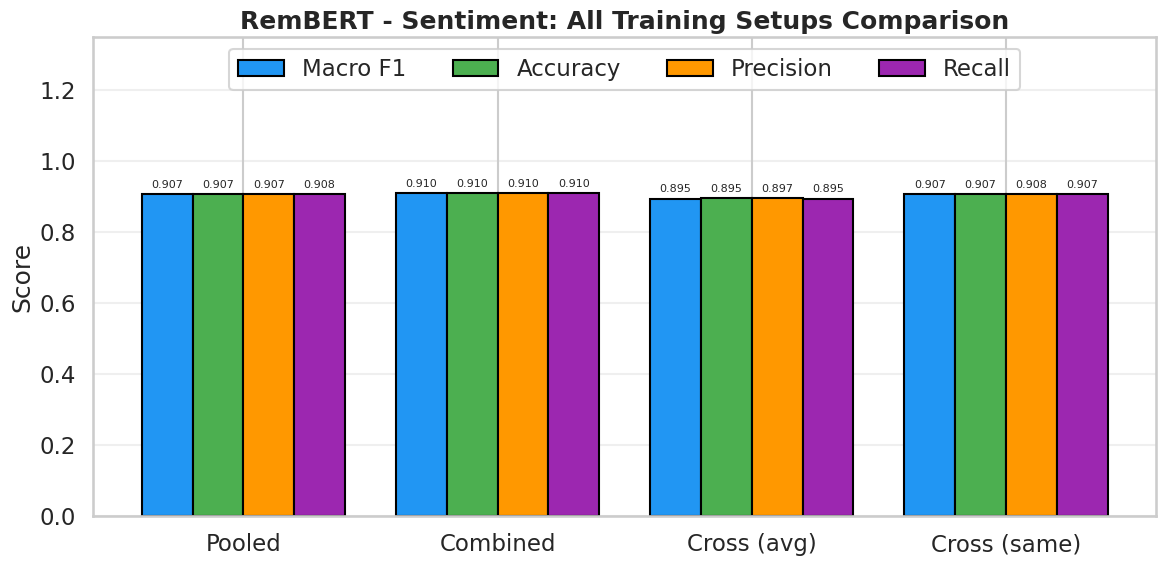

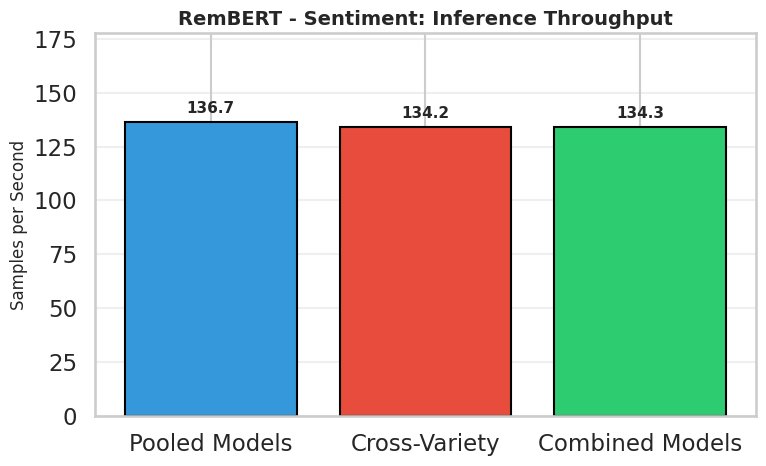

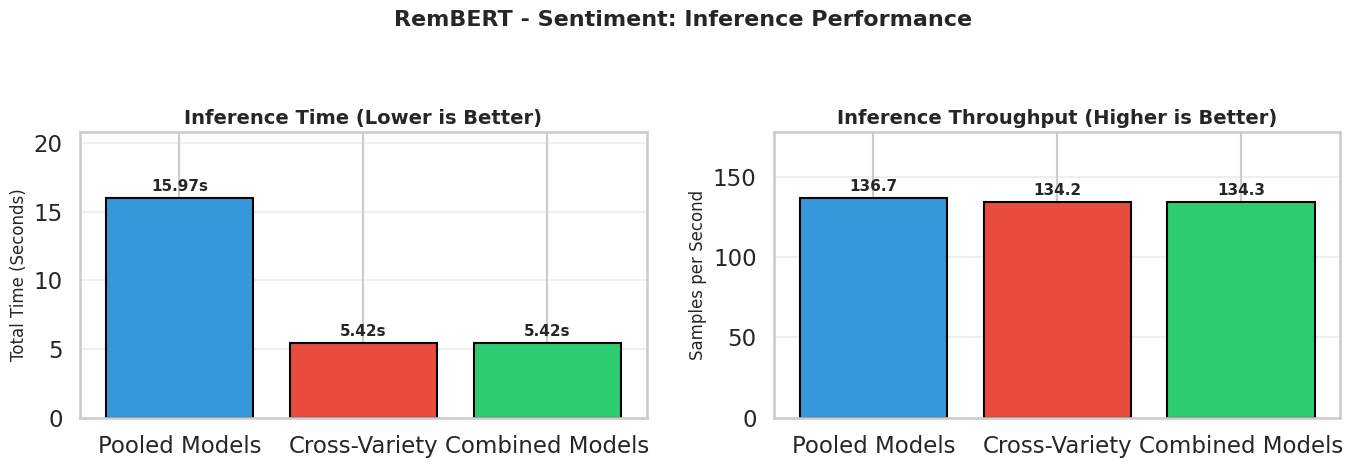


>>> Generating comprehensive plots for: Sarcasm


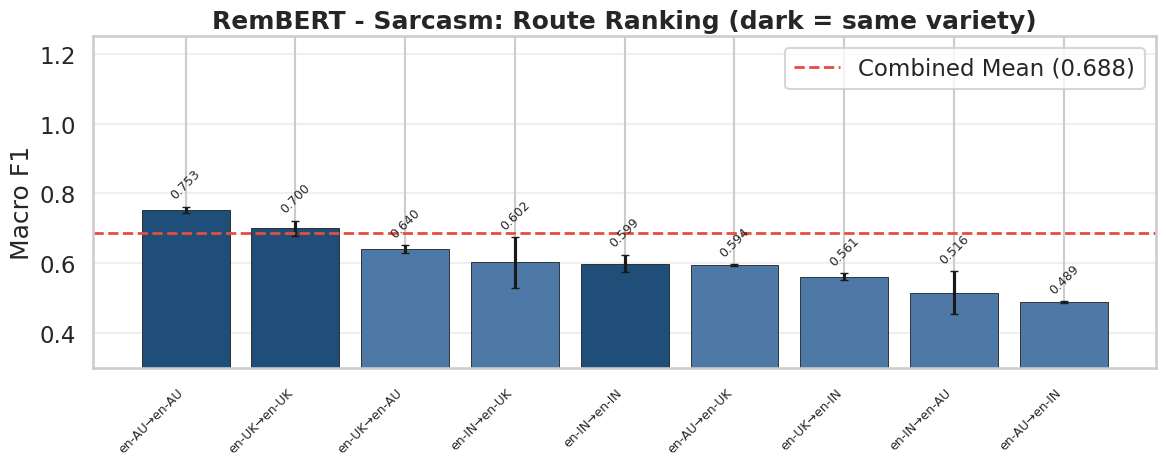

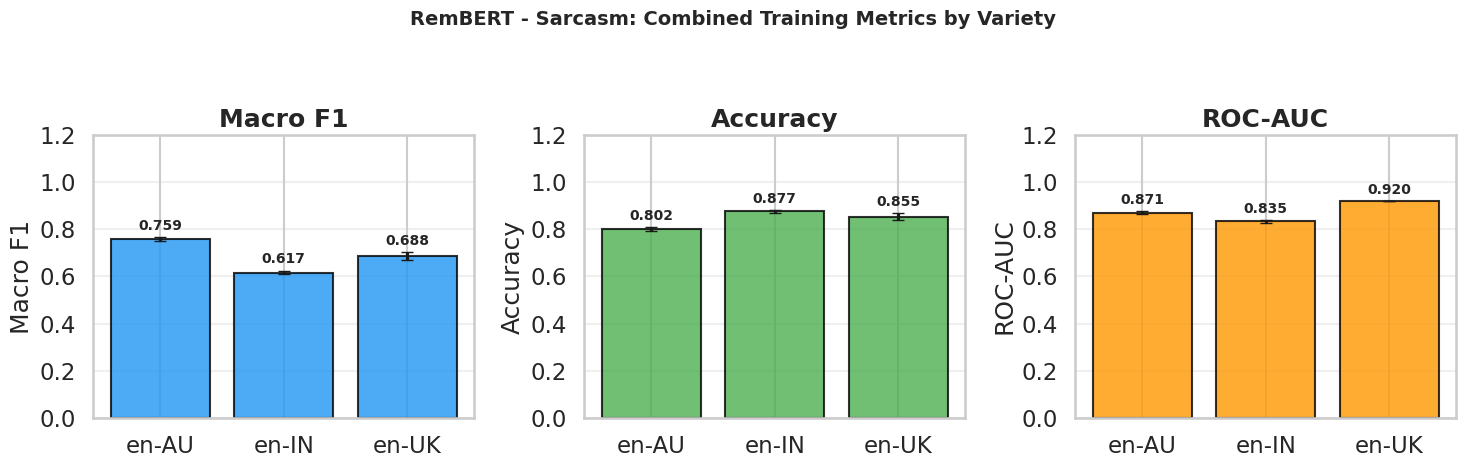

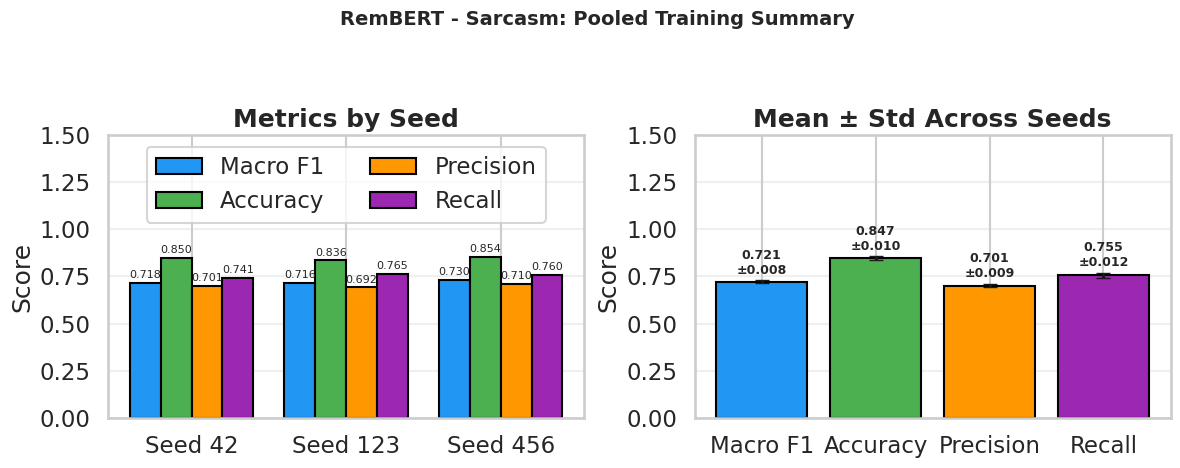

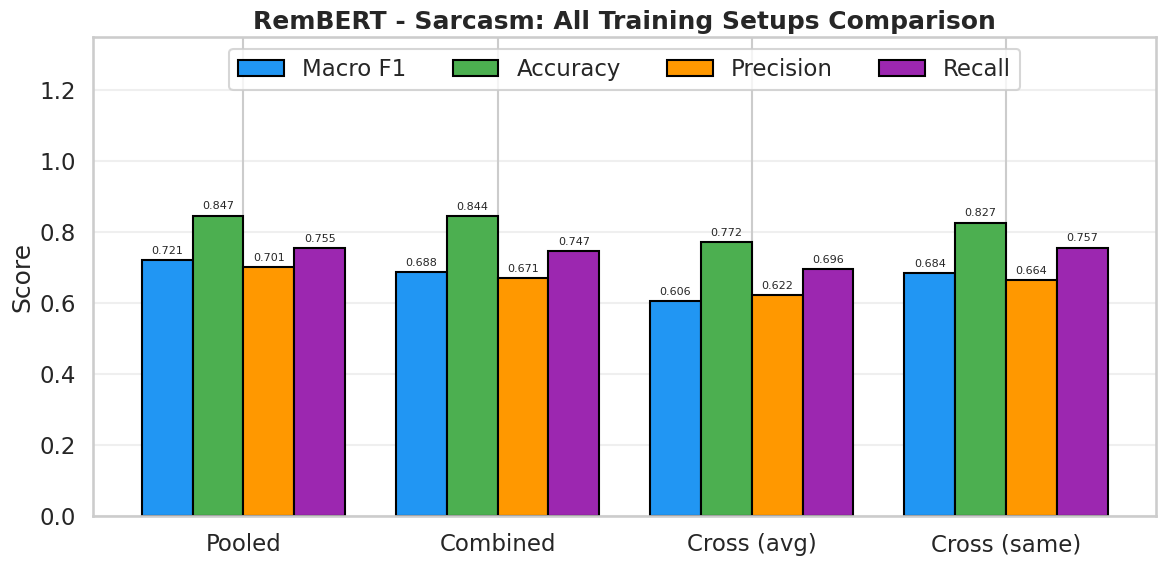

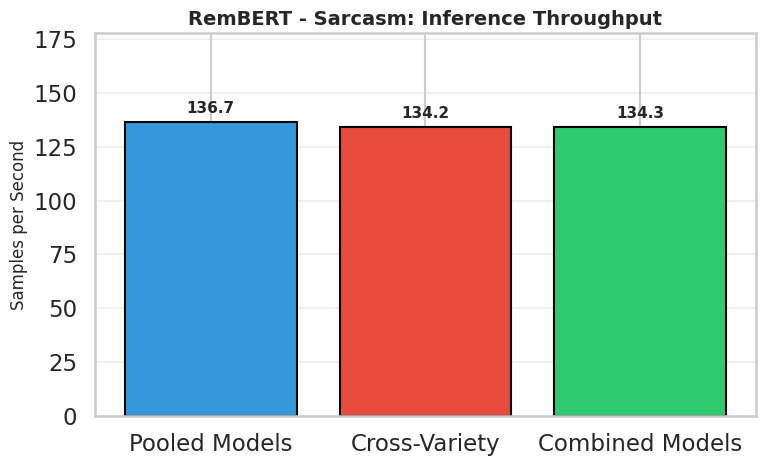

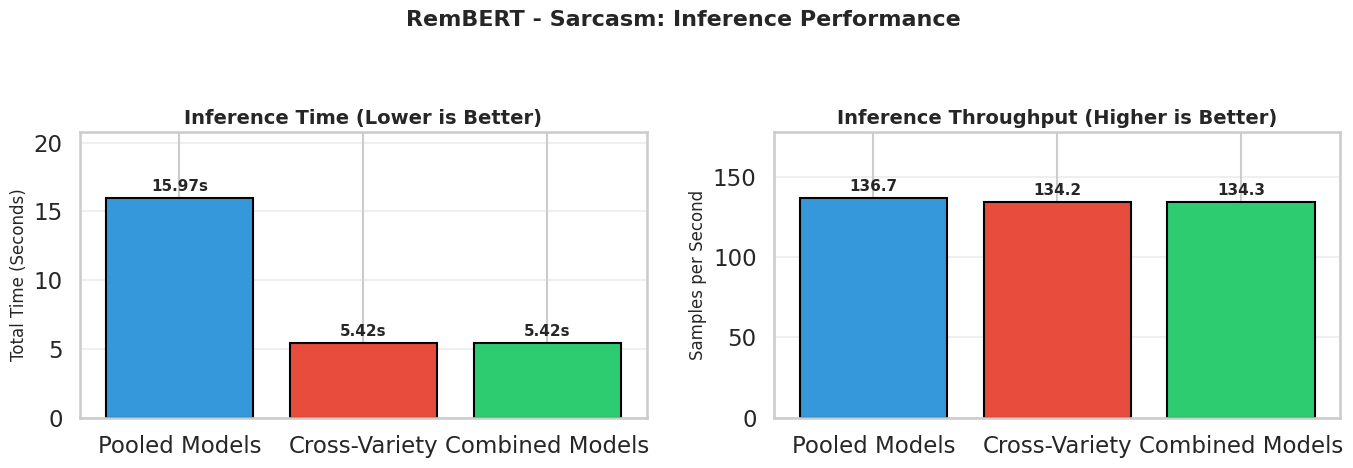


>>> All individual task plotting completed!

CROSS-TASK COMPARISON: Sentiment vs Sarcasm


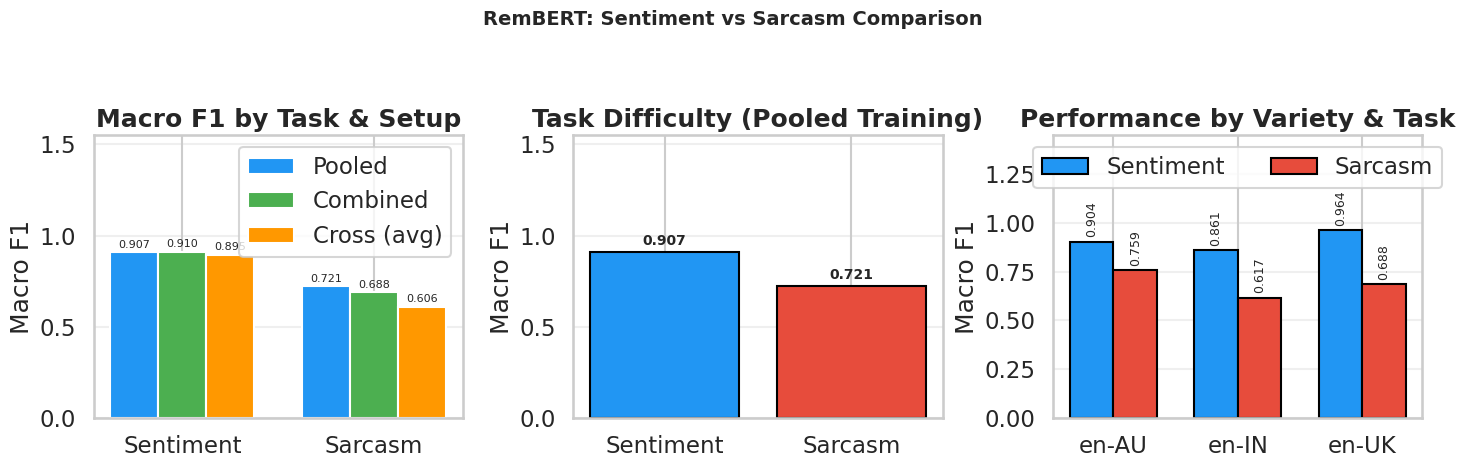

In [32]:
# Comprehensive plotting suite

for task_name in TASKS:
    if task_name not in all_task_results:
        continue
    
    task_dir = task_out_dir(task_name)
    pooled_df_task = all_task_results[task_name]['pooled_df']
    cross_df_task = all_task_results[task_name]['cross_df']
    combined_df_task = all_task_results[task_name]['combined_df']
    
    print(f"\n>>> Generating comprehensive plots for: {task_name}")
    
    # 1. Route Ranking
    rank = cross_df_task.copy()
    rank['route'] = rank['train_variety'] + '→' + rank['test_variety']
    rank['is_same'] = rank['train_variety'] == rank['test_variety']
    rank = rank.sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#1f4e79' if same else '#4e79a7' for same in rank['is_same']]
    bars = ax.bar(rank.index, rank['macro_f1_mean'], yerr=rank['macro_f1_std'], 
                  capsize=3, color=colors, edgecolor='black', linewidth=0.5)
    
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9, rotation=45)
    
    combined_mean = combined_df_task['macro_f1_mean'].mean()
    ax.axhline(combined_mean, color='#e74c3c', linestyle='--', linewidth=2, label=f'Combined Mean ({combined_mean:.3f})')
    
    ax.set_xticks(rank.index)
    ax.set_xticklabels(rank['route'], rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0.3, 1.25) 
    ax.set_ylabel('Macro F1')
    ax.set_title(f'{MODEL_LABEL} - {task_name}: Route Ranking (dark = same variety)', fontweight='bold')
    ax.legend(loc='upper right') 
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(task_dir / 'route_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 2. Combined Metrics By Variety
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    metrics_config = [('macro_f1', 'Macro F1', '#2196F3'), ('accuracy', 'Accuracy', '#4CAF50'), ('roc_auc', 'ROC-AUC', '#FF9800')]
    
    for ax, (metric, title, color) in zip(axes, metrics_config):
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        if mean_col in combined_df_task.columns:
            vals = combined_df_task[mean_col]
            errs = combined_df_task[std_col] if std_col in combined_df_task.columns else None
            bars = ax.bar(combined_df_task['test_variety'], vals, yerr=errs, capsize=4, color=color, alpha=0.8, edgecolor='black')
            ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10, fontweight='bold')
        
        ax.set_ylim(0, 1.20)
        ax.set_ylabel(title)
        ax.set_title(f'{title}', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Combined Training Metrics by Variety', fontweight='bold', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.savefig(task_dir / 'combined_metrics_detailed.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 3. Pooled Training Summary
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x = np.arange(len(pooled_df_task['seed']))
    width = 0.2 
    
    axes[0].bar(x - width*1.5, pooled_df_task['macro_f1'], width, label='Macro F1', color='#2196F3', edgecolor='black')
    axes[0].bar(x - width*0.5, pooled_df_task['accuracy'], width, label='Accuracy', color='#4CAF50', edgecolor='black')
    axes[0].bar(x + width*0.5, pooled_df_task['macro_precision'], width, label='Precision', color='#FF9800', edgecolor='black')
    axes[0].bar(x + width*1.5, pooled_df_task['macro_recall'], width, label='Recall', color='#9C27B0', edgecolor='black')
    
    axes[0].set_xticks(x); axes[0].set_xticklabels([f'Seed {s}' for s in pooled_df_task['seed']])
    axes[0].set_ylim(0, 1.50) 
    axes[0].set_ylabel('Score'); axes[0].set_title('Metrics by Seed', fontweight='bold')
    axes[0].legend(loc='upper center', ncol=2) 
    axes[0].grid(axis='y', alpha=0.3)
    for container in axes[0].containers: axes[0].bar_label(container, fmt='%.3f', padding=2, fontsize=8)

    stats = {'Macro F1': (pooled_df_task['macro_f1'].mean(), pooled_df_task['macro_f1'].std()), 'Accuracy': (pooled_df_task['accuracy'].mean(), pooled_df_task['accuracy'].std()), 'Precision': (pooled_df_task['macro_precision'].mean(), pooled_df_task['macro_precision'].std()), 'Recall': (pooled_df_task['macro_recall'].mean(), pooled_df_task['macro_recall'].std())}
    metrics = list(stats.keys()); means = [stats[m][0] for m in metrics]; stds = [stats[m][1] for m in metrics]
    
    axes[1].bar(metrics, means, yerr=stds, capsize=5, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'], edgecolor='black', linewidth=1.5)
    axes[1].set_ylim(0, 1.50)
    axes[1].set_ylabel('Score'); axes[1].set_title('Mean ± Std Across Seeds', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    for i, bar in enumerate(axes[1].patches):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + stds[i] + 0.02, f'{means[i]:.3f}\n±{stds[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Pooled Training Summary', fontweight='bold', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
    plt.savefig(task_dir / 'pooled_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 4. All Metrics Comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    all_results = [
        {'Setup': 'Pooled', 'Macro F1': pooled_df_task['macro_f1'].mean(), 'Accuracy': pooled_df_task['accuracy'].mean(), 'Precision': pooled_df_task['macro_precision'].mean(), 'Recall': pooled_df_task['macro_recall'].mean()},
        {'Setup': 'Combined', 'Macro F1': combined_df_task['macro_f1_mean'].mean(), 'Accuracy': combined_df_task['accuracy_mean'].mean(), 'Precision': combined_df_task['macro_precision_mean'].mean(), 'Recall': combined_df_task['macro_recall_mean'].mean()},
        {'Setup': 'Cross (avg)', 'Macro F1': cross_df_task['macro_f1_mean'].mean(), 'Accuracy': cross_df_task['accuracy_mean'].mean(), 'Precision': cross_df_task['macro_precision_mean'].mean(), 'Recall': cross_df_task['macro_recall_mean'].mean()}
    ]
    same_v = cross_df_task[cross_df_task['train_variety'] == cross_df_task['test_variety']]
    all_results.append({'Setup': 'Cross (same)', 'Macro F1': same_v['macro_f1_mean'].mean(), 'Accuracy': same_v['accuracy_mean'].mean(), 'Precision': same_v['macro_precision_mean'].mean(), 'Recall': same_v['macro_recall_mean'].mean()})
    
    comparison_df = pd.DataFrame(all_results)
    x = np.arange(len(comparison_df)); width = 0.2
    
    for i, (metric, color) in enumerate(zip(['Macro F1', 'Accuracy', 'Precision', 'Recall'], ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])):
        bars = ax.bar(x + i * width, comparison_df[metric], width, label=metric, color=color, edgecolor='black')
        ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    
    ax.set_xticks(x + width * 1.5); ax.set_xticklabels(comparison_df['Setup'])
    ax.set_ylim(0, 1.35) 
    ax.set_ylabel('Score'); ax.set_title(f'{MODEL_LABEL} - {task_name}: All Training Setups Comparison', fontweight='bold')
    ax.legend(loc='upper center', ncol=4)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(task_dir / 'all_setups_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Plot: inference throughput
    try:
        avg_pooled_tput = pooled_df_task['samples_per_sec'].mean()
        avg_cross_tput = cross_df_task['samples_per_sec_mean'].mean() 
        avg_combined_tput = combined_df_task['samples_per_sec_mean'].mean()
        
        throughput_data = {'Pooled Models': avg_pooled_tput, 'Cross-Variety': avg_cross_tput, 'Combined Models': avg_combined_tput}
        if any(v > 0 for v in throughput_data.values()):
            
            fig, ax = plt.subplots(figsize=(8, 5))
            methods = list(throughput_data.keys())
            values = list(throughput_data.values())
            bars = ax.bar(methods, values, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
            ax.set_ylim(0, max(values) * 1.30)
            
            for bar in bars:
                ax.text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + (max(values)*0.02), f'{bar.get_height():.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
            
            ax.set_ylabel('Samples per Second', fontsize=12)
            ax.set_title(f'{MODEL_LABEL} - {task_name}: Inference Throughput', fontweight='bold', fontsize=14)
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.savefig(task_dir / 'inference_throughput.png', dpi=300, bbox_inches='tight')
            plt.show()
    except KeyError as e:
        print(f"Skipping Inference plot: Missing metric column {e}")
        
    # 5. Inference Time & Throughput
    if 'samples_per_sec' in pooled_df_task.columns and 'inference_time_sec' in pooled_df_task.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Prepare the data
        labels = ['Pooled Models', 'Cross-Variety', 'Combined Models']
        
        time_vals = [
            pooled_df_task['inference_time_sec'].mean(),
            cross_df_task['inference_time_sec_mean'].mean(),
            combined_df_task['inference_time_sec_mean'].mean()
        ]
        
        throughput_vals = [
            pooled_df_task['samples_per_sec'].mean(),
            cross_df_task['samples_per_sec_mean'].mean(),
            combined_df_task['samples_per_sec_mean'].mean()
        ]
        
        colors = ['#3498db', '#e74c3c', '#2ecc71']
        
        # Chart 1: inference time (total seconds)
        if any(v > 0 for v in time_vals):
            bars_time = axes[0].bar(labels, time_vals, color=colors, edgecolor='black', linewidth=1.5)
            axes[0].set_ylim(0, max(time_vals) * 1.30)
            
            for bar in bars_time: 
                axes[0].text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + (max(time_vals)*0.02), 
                             f'{bar.get_height():.2f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
                
            axes[0].set_ylabel('Total Time (Seconds)', fontsize=12)
            axes[0].set_title('Inference Time (Lower is Better)', fontweight='bold', fontsize=14)
            axes[0].grid(axis='y', alpha=0.3)
        
        # Chart 2: inference throughput (samples per second)
        if any(v > 0 for v in throughput_vals):
            bars_tput = axes[1].bar(labels, throughput_vals, color=colors, edgecolor='black', linewidth=1.5)
            axes[1].set_ylim(0, max(throughput_vals) * 1.30)
            
            for bar in bars_tput: 
                axes[1].text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + (max(throughput_vals)*0.02), 
                             f'{bar.get_height():.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
                
            axes[1].set_ylabel('Samples per Second', fontsize=12)
            axes[1].set_title('Inference Throughput (Higher is Better)', fontweight='bold', fontsize=14)
            axes[1].grid(axis='y', alpha=0.3)
        
        plt.suptitle(f'{MODEL_LABEL} - {task_name}: Inference Performance', fontweight='bold', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.93])
        plt.savefig(task_dir / 'inference_performance.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("  Skipping Inference plot: Missing time metrics in DataFrame.")

print(f"\n>>> All individual task plotting completed!")

# Cross-task Comparison
if len(all_task_results) == 2:
    print(f"\n{'='*90}")
    print(f"CROSS-TASK COMPARISON: Sentiment vs Sarcasm")
    print(f"{'='*90}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    pooled_data = {task: all_task_results[task]['pooled_df']['macro_f1'].mean() for task in TASKS}
    combined_data = {task: all_task_results[task]['combined_df']['macro_f1_mean'].mean() for task in TASKS}
    cross_data = {task: all_task_results[task]['cross_df']['macro_f1_mean'].mean() for task in TASKS}
    
    x = np.arange(2); width = 0.25
    b1 = axes[0].bar(x - width, [pooled_data[t] for t in TASKS], width, label='Pooled', color='#2196F3')
    b2 = axes[0].bar(x, [combined_data[t] for t in TASKS], width, label='Combined', color='#4CAF50')
    b3 = axes[0].bar(x + width, [cross_data[t] for t in TASKS], width, label='Cross (avg)', color='#FF9800')
    axes[0].bar_label(b1, fmt='%.3f', padding=2, fontsize=8); axes[0].bar_label(b2, fmt='%.3f', padding=2, fontsize=8); axes[0].bar_label(b3, fmt='%.3f', padding=2, fontsize=8)
    axes[0].set_xticks(x); axes[0].set_xticklabels(TASKS); axes[0].set_ylim(0, 1.35) 
    axes[0].set_ylim(0, 1.55)
    axes[0].set_ylabel('Macro F1'); axes[0].set_title('Macro F1 by Task & Setup', fontweight='bold')
    axes[0].legend(loc='upper right'); axes[0].grid(axis='y', alpha=0.3)
    
    b_diff = axes[1].bar(TASKS, [pooled_data[t] for t in TASKS], color=['#2196F3', '#e74c3c'], edgecolor='black')
    axes[1].bar_label(b_diff, fmt='%.3f', padding=3, fontsize=10, fontweight='bold') 
    axes[1].set_ylim(0, 1.55); axes[1].set_ylabel('Macro F1'); axes[1].set_title('Task Difficulty (Pooled Training)', fontweight='bold'); axes[1].grid(axis='y', alpha=0.3)
    
    variety_task_f1 = {}
    for task in TASKS:
        for v in VARIETIES:
            variety_task_f1[(task, v)] = float(all_task_results[task]['combined_df'][all_task_results[task]['combined_df'].test_variety == v]['macro_f1_mean'].iloc[0])
    
    x = np.arange(len(VARIETIES)); width = 0.35
    b_var1 = axes[2].bar(x - width/2, [variety_task_f1[(TASKS[0], v)] for v in VARIETIES], width, label=TASKS[0], color='#2196F3', edgecolor='black')
    b_var2 = axes[2].bar(x + width/2, [variety_task_f1[(TASKS[1], v)] for v in VARIETIES], width, label=TASKS[1], color='#e74c3c', edgecolor='black')
    axes[2].bar_label(b_var1, fmt='%.3f', padding=3, fontsize=9, rotation=90); axes[2].bar_label(b_var2, fmt='%.3f', padding=3, fontsize=9, rotation=90)
    axes[2].set_xticks(x); axes[2].set_xticklabels(VARIETIES); axes[2].set_ylim(0, 1.45) 
    axes[0].set_ylim(0, 1.55)
    axes[2].set_ylabel('Macro F1'); axes[2].set_title('Performance by Variety & Task', fontweight='bold')
    axes[2].legend(loc='upper center', ncol=2); axes[2].grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'{MODEL_LABEL}: Sentiment vs Sarcasm Comparison', fontweight='bold', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.savefig(OUT_DIR / 'cross_task_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7) Fine-Tune Utility Cells (Manual)

Use these cells for quick one-off runs of a specific task/setup without re-running the full pipeline.


In [18]:
# Fine-tune utility configuration
# Modes available: pooled, cross, combined
# Use this section for one-off fine-tuning runs or sweeps.

# Toggle for running mode
FT_RUN_ALL = False  # True => run all possible fine-tuning combos (use cell 20 for this)

# Single run configuration (used when FT_RUN_ALL=False)
FT_TASK = 'Sentiment'         # 'Sentiment' or 'Sarcasm'
FT_MODE = 'pooled'            # 'pooled' | 'cross' | 'combined'
FT_SEED = 42
FT_TRAIN_VARIETY = 'en-UK'    # only used for FT_MODE='cross'

# Hyperparameter overrides for this run (optional)
FT_NUM_EPOCHS = NUM_EPOCHS
FT_LEARNING_RATE = LEARNING_RATE
FT_BATCH_SIZE = BATCH_SIZE_TRAIN

# Sweep configuration (used when FT_RUN_ALL=True)
FT_TASKS = ['Sentiment', 'Sarcasm']
FT_MODES = ['pooled', 'cross', 'combined']
FT_SEEDS = SEEDS[:]
FT_TRAIN_VARIETIES = VARIETIES[:]

print(f"Fine-Tune Configuration:")
print(f"  FT_RUN_ALL = {FT_RUN_ALL}")
if FT_RUN_ALL:
    total_runs = len(FT_TASKS) * (
        len(FT_SEEDS) +  # pooled
        len(FT_SEEDS) +  # combined
        len(FT_SEEDS) * len(FT_TRAIN_VARIETIES)  # cross
    )
    print(f"  Sweep config:")
    print(f"    Tasks: {FT_TASKS}")
    print(f"    Modes: {FT_MODES}")
    print(f"    Seeds: {FT_SEEDS}")
    print(f"    Train varieties (for cross): {FT_TRAIN_VARIETIES}")
    print(f"    Total runs: {total_runs}")
else:
    print(f"  Single config:")
    print(f"    Task: {FT_TASK}")
    print(f"    Mode: {FT_MODE}")
    print(f"    Seed: {FT_SEED}")
    if FT_MODE == 'cross':
        print(f"    Train variety: {FT_TRAIN_VARIETY}")
    print(f"    Epochs: {FT_NUM_EPOCHS}")
    print(f"    Learning rate: {FT_LEARNING_RATE}")
    print(f"    Batch size: {FT_BATCH_SIZE}")


Fine-Tune Configuration:
  FT_RUN_ALL = False
  Single config:
    Task: Sentiment
    Mode: pooled
    Seed: 42
    Epochs: 5
    Learning rate: 2e-05
    Batch size: 8



Running SINGLE fine-tune configuration...

  [Sentiment] Pooled training, seed=42


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable parameters: 10,656,002 / 586,578,692 (1.82%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,1.358826,0.203337,0.936102,0.936023,0.936569,0.935784,0.936074,0.936351,0.936102,0.938272,0.933775,0.980821,0.982583
2,0.934695,0.174791,0.932907,0.932883,0.932839,0.932945,0.932911,0.932935,0.932907,0.934169,0.931596,0.983824,0.984083
3,0.619267,0.191342,0.929712,0.929453,0.932851,0.928819,0.929548,0.932142,0.929712,0.933735,0.925170,0.985131,0.985758
4,0.372028,0.171670,0.932907,0.932883,0.932839,0.932945,0.932911,0.932935,0.932907,0.934169,0.931596,0.985294,0.985363


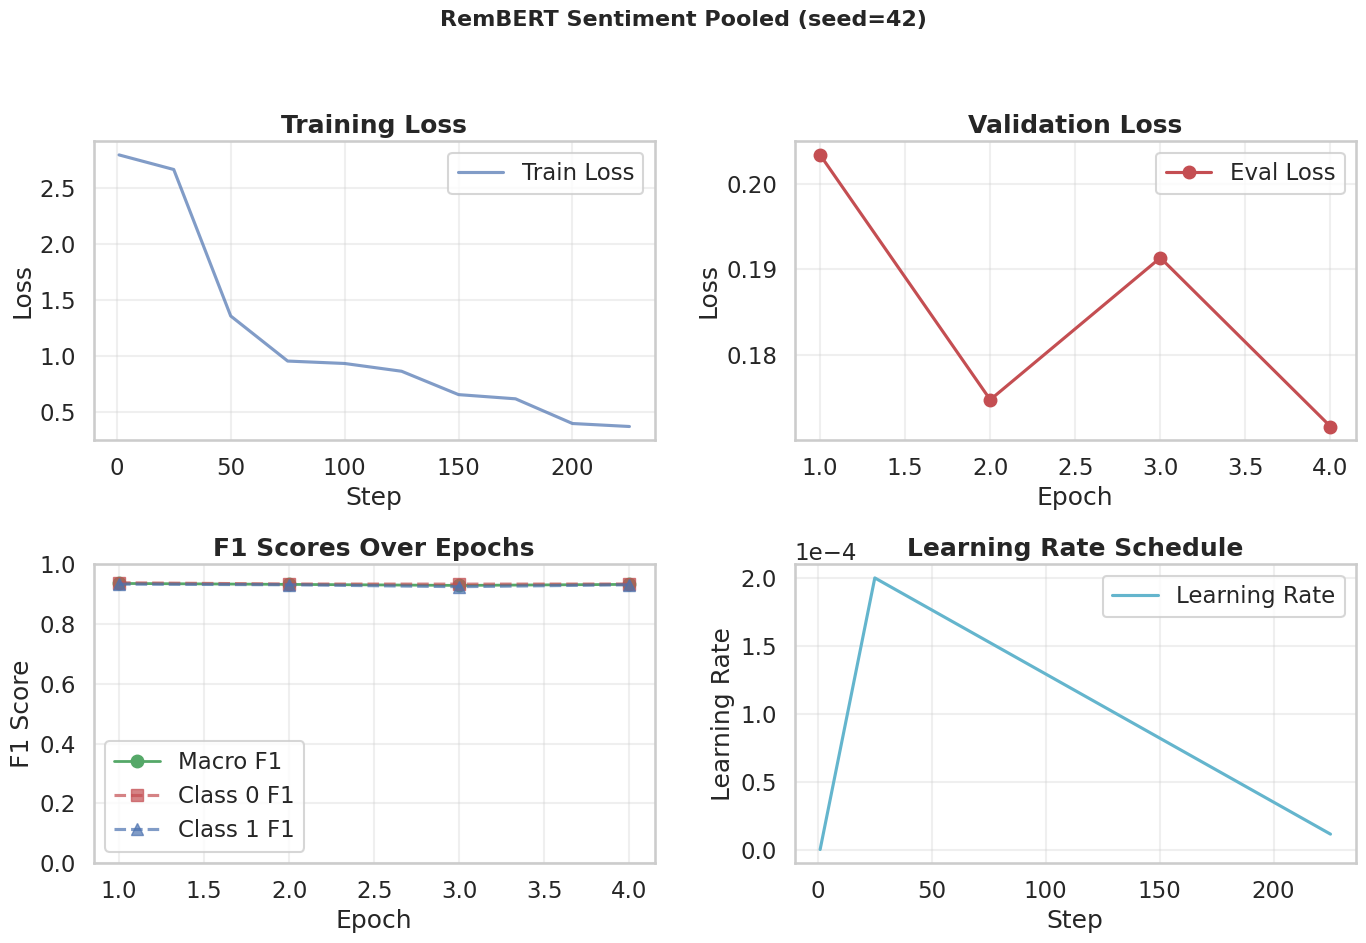

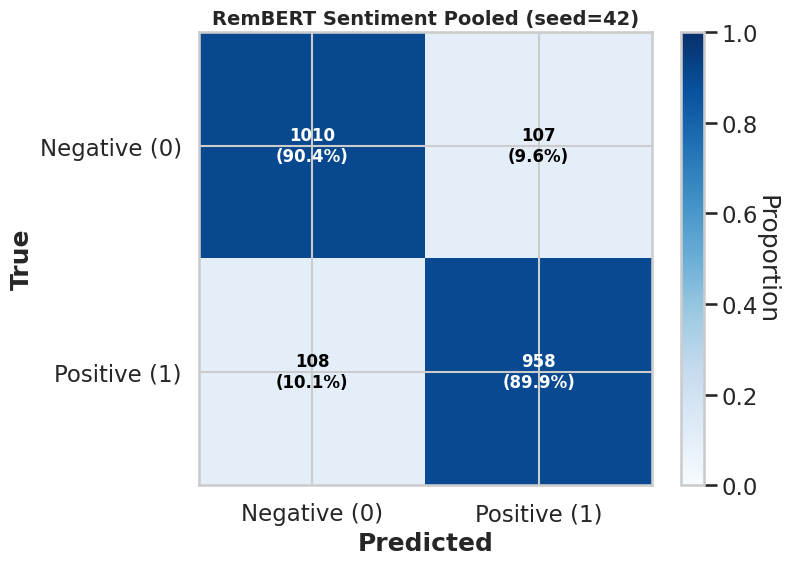

    -> Macro F1: 0.9015, Accuracy: 0.9015

Results: F1=0.9015, Accuracy=0.9015

FINE-TUNING COMPLETED
Saved: /scratch/HS400/outputs_rembert/fine_tune_runs_20260415_003721.csv
Total rows: 1

Summary:
     task   mode  seed train_variety test_variety  macro_f1  accuracy
Sentiment pooled    42           ALL     ALL_TEST  0.901456  0.901512


In [19]:
# Run fine-tuning from the config above
from datetime import datetime

results_rows = []

if FT_RUN_ALL:
    print(f"\n{'='*60}")
    print("Running FULL fine-tuning sweep...")
    print("(This may take a long time)")
    print(f"{'='*60}")
    
    for task_name in FT_TASKS:
        for mode in FT_MODES:
            for seed in FT_SEEDS:
                if mode == 'pooled':
                    r = run_pooled_for_task(task_name, seed, save_plots=False)
                    results_rows.append({
                        'task': task_name, 'mode': mode, 'seed': seed,
                        'train_variety': 'ALL', 'test_variety': 'ALL_TEST',
                        'accuracy': r['accuracy'],
                        'macro_f1': r['macro_f1'], 'precision': r['macro_precision'], 
                        'recall': r['macro_recall'],
                        'roc_auc': r.get('roc_auc', np.nan),
                        'checkpoint_dir': r['checkpoint_dir'], 'final_model_dir': r['final_model_dir'],
                    })
                    print(f"[DONE] {task_name} | pooled | seed={seed} | F1={r['macro_f1']:.4f}")

                elif mode == 'combined':
                    r = run_combined_for_task(task_name, seed, save_plots=False)
                    meta = r.get('_meta', {})
                    for tv in VARIETIES:
                        results_rows.append({
                            'task': task_name, 'mode': mode, 'seed': seed,
                            'train_variety': 'ALL', 'test_variety': tv,
                            'accuracy': r[tv]['accuracy'],
                            'macro_f1': r[tv]['macro_f1'], 'precision': r[tv]['macro_precision'],
                            'recall': r[tv]['macro_recall'],
                            'roc_auc': r[tv].get('roc_auc', np.nan),
                            'checkpoint_dir': meta.get('checkpoint_dir', ''),
                            'final_model_dir': meta.get('final_model_dir', ''),
                        })
                    print(f"[DONE] {task_name} | combined | seed={seed}")

                elif mode == 'cross':
                    for tr in FT_TRAIN_VARIETIES:
                        r = run_cross_for_task(task_name, tr, seed, save_plots=False)
                        meta = r.get('_meta', {})
                        for tv in VARIETIES:
                            results_rows.append({
                                'task': task_name, 'mode': mode, 'seed': seed,
                                'train_variety': tr, 'test_variety': tv,
                                'accuracy': r[tv]['accuracy'],
                                'macro_f1': r[tv]['macro_f1'], 'precision': r[tv]['macro_precision'],
                                'recall': r[tv]['macro_recall'],
                                'roc_auc': r[tv].get('roc_auc', np.nan),
                                'checkpoint_dir': meta.get('checkpoint_dir', ''),
                                'final_model_dir': meta.get('final_model_dir', ''),
                            })
                        print(f"[DONE] {task_name} | cross | train={tr} | seed={seed}")

else:
    print(f"\n{'='*60}")
    print("Running SINGLE fine-tune configuration...")
    print(f"{'='*60}")
    
    if FT_MODE == 'pooled':
        r = run_pooled_for_task(FT_TASK, FT_SEED, save_plots=True)
        results_rows.append({
            'task': FT_TASK, 'mode': FT_MODE, 'seed': FT_SEED,
            'train_variety': 'ALL', 'test_variety': 'ALL_TEST',
            'accuracy': r['accuracy'],
            'macro_f1': r['macro_f1'], 'precision': r['macro_precision'],
            'recall': r['macro_recall'],
            'roc_auc': r.get('roc_auc', np.nan),
            'checkpoint_dir': r['checkpoint_dir'], 'final_model_dir': r['final_model_dir'],
        })
        print(f"\nResults: F1={r['macro_f1']:.4f}, Accuracy={r['accuracy']:.4f}")
        
    elif FT_MODE == 'combined':
        r = run_combined_for_task(FT_TASK, FT_SEED, save_plots=True)
        meta = r.get('_meta', {})
        for tv in VARIETIES:
            results_rows.append({
                'task': FT_TASK, 'mode': FT_MODE, 'seed': FT_SEED,
                'train_variety': 'ALL', 'test_variety': tv,
                'accuracy': r[tv]['accuracy'],
                'macro_f1': r[tv]['macro_f1'], 'precision': r[tv]['macro_precision'],
                'recall': r[tv]['macro_recall'],
                'roc_auc': r[tv].get('roc_auc', np.nan),
                'checkpoint_dir': meta.get('checkpoint_dir', ''),
                'final_model_dir': meta.get('final_model_dir', ''),
            })
        print(f"\nResults by variety:")
        for tv in VARIETIES:
            print(f"  {tv}: F1={r[tv]['macro_f1']:.4f}")
            
    elif FT_MODE == 'cross':
        r = run_cross_for_task(FT_TASK, FT_TRAIN_VARIETY, FT_SEED, save_plots=True)
        meta = r.get('_meta', {})
        for tv in VARIETIES:
            results_rows.append({
                'task': FT_TASK, 'mode': FT_MODE, 'seed': FT_SEED,
                'train_variety': FT_TRAIN_VARIETY, 'test_variety': tv,
                'accuracy': r[tv]['accuracy'],
                'macro_f1': r[tv]['macro_f1'], 'precision': r[tv]['macro_precision'],
                'recall': r[tv]['macro_recall'],
                'roc_auc': r[tv].get('roc_auc', np.nan),
                'checkpoint_dir': meta.get('checkpoint_dir', ''),
                'final_model_dir': meta.get('final_model_dir', ''),
            })
        print(f"\nResults (trained on {FT_TRAIN_VARIETY}):")
        for tv in VARIETIES:
            print(f"  → {tv}: F1={r[tv]['macro_f1']:.4f}")
    else:
        raise ValueError(f"FT_MODE must be one of: pooled, cross, combined. Got: {FT_MODE}")

# Save results
if results_rows:
    ft_df = pd.DataFrame(results_rows)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    out_csv = OUT_DIR / f'fine_tune_runs_{ts}.csv'
    ft_df.to_csv(out_csv, index=False)
    
    print(f"\n{'='*60}")
    print(f"FINE-TUNING COMPLETED")
    print(f"{'='*60}")
    print(f"Saved: {out_csv}")
    print(f"Total rows: {len(ft_df)}")
    print(f"\nSummary:")
    print(ft_df[['task', 'mode', 'seed', 'train_variety', 'test_variety', 'macro_f1', 'accuracy']].to_string(index=False))


### Qualitative Error Analysis


In [ ]:
# 8) Qualitative error analysis
from peft import PeftModel
import torch
import numpy as np

def run_error_analysis(task_name: str, seed: int = 42):
    print(f"\n{'='*60}")
    print(f"QUALITATIVE ERROR ANALYSIS: {task_name.upper()}")
    print(f"{'='*60}")
    
    # 1. Dynamic Labels for Task
    if task_name.lower() == "sarcasm":
        pos_label, neg_label = "SARCASTIC", "LITERAL"
    else:
        pos_label, neg_label = "POSITIVE", "NEGATIVE"
        
    lbl_col = get_label_col(task_name)
    
    # 2. Load The Model Correctly
    # Define the base model name (ensure this matches your training)
    BASE_MODEL_NAME = "google/rembert"
    model_dir = task_out_dir(task_name) / 'final_models' / f'rembert_pooled_seed{seed}'
    
    if not model_dir.exists():
        print(f" Model not found at {model_dir}")
        return
        
    print(f"Loading Base RemBERT: {BASE_MODEL_NAME}...")
    base_model = AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL_NAME, 
        num_labels=2
    ).to(DEVICE)
    
    print(f"Merging LoRA Adapters from {model_dir}...")
    # Attach weights reported as missing in logs.
    model = PeftModel.from_pretrained(base_model, model_dir).to(DEVICE)
    model.eval()
    
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
    
    # 3. Prepare Test Data
    te_texts = list(pooled['test'][text_col])
    te_labels = [int(x) for x in pooled['test'][lbl_col]]
    te_ds = TextDataset(te_texts, te_labels, tokenizer, max_len=MAX_LEN)
    
    # 4. Get Predictions
    # Use the native DataCollator for RemBERT tokenization.
    trainer = Trainer(model=model, data_collator=IntLabelDataCollator(tokenizer))
    preds_output = trainer.predict(te_ds)
    
    probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
    y_pred = np.argmax(probs, axis=-1)
    
    # 5. Filter for Errors
    errors = []
    for i in range(len(te_labels)):
        if te_labels[i] != y_pred[i]:
            errors.append({
                'text': te_texts[i],
                'true': te_labels[i],
                'pred': y_pred[i],
                'confidence': probs[i][y_pred[i]]
            })
            
    errors.sort(key=lambda x: x['confidence'], reverse=True)
    
    # 6. Print Results
    print(f"\n🚨 TOP 5 FALSE POSITIVES 🚨")
    print(f"({neg_label} text that the model was HIGHLY CONFIDENT was {pos_label})")
    fps = [e for e in errors if e['pred'] == 1 and e['true'] == 0]
    for i, e in enumerate(fps[:5]):
        print(f"\n{i+1}. [Conf: {e['confidence']:.4f}] {e['text']}")

    print(f"\n\n🚨 TOP 5 FALSE NEGATIVES 🚨")
    print(f"({pos_label} text that the model was HIGHLY CONFIDENT was {neg_label})")
    fns = [e for e in errors if e['pred'] == 0 and e['true'] == 1]
    for i, e in enumerate(fns[:5]):
        print(f"\n{i+1}. [Conf: {e['confidence']:.4f}] {e['text']}")
        
    del model, base_model, trainer
    torch.cuda.empty_cache()

# Run error analysis
run_error_analysis('Sarcasm')
run_error_analysis('Sentiment')


QUALITATIVE ERROR ANALYSIS: SARCASM
Loading Base RemBERT: google/rembert...


Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Merging LoRA Adapters from /scratch/HS400/outputs_rembert/sarcasm/final_models/rembert_pooled_seed42...



🚨 TOP 5 FALSE POSITIVES 🚨
(LITERAL text that the model was HIGHLY CONFIDENT was SARCASTIC)

1. [Conf: 0.9950] When I ask for extra sauce, I only want one extra squirt out of the bottle, not the entire bottle. Stop hiring restarted people.

2. [Conf: 0.9923] Exactly how does one "hack" a click counter? Someone needs to ask them this

3. [Conf: 0.9920] As much as I agree with Samaras, I think ultimately that Perrett saying that *"grand narratives belonged in election campaigns rather than budgets"* is probably the more practical truth.
This puts Labor in a position they're very comfortable in - lip service about the change they want, but only carrying out the changes they need (or believe they can afford) to make.
This is a fundamental issue with democracy under neoliberal and capitalist assumptions. It keeps the leftwing establishment from the proper work of nation building, keeps them "tinkering around the edges" as the article puts it - and allows for a ratcheting to the right of pol

Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

RemBertForSequenceClassification LOAD REPORT from: google/rembert
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Merging LoRA Adapters from /scratch/HS400/outputs_rembert/sentiment/final_models/rembert_pooled_seed42...



🚨 TOP 5 FALSE POSITIVES 🚨
(NEGATIVE text that the model was HIGHLY CONFIDENT was POSITIVE)

1. [Conf: 0.9579] Nice place to break the journey before entering Maharashtra or just after Maharashtra.

2. [Conf: 0.9437] Puff and some of the cakes are just superb, and well priced. Puff I had there some 15years back and then now, and it tastes same. It is perfectly priced as well. Eat it hot. Other Bakery items are also good, but there are better options available for those items.

3. [Conf: 0.9424] Buns & Burgers is a venue of a delectable selection of Burgers made with the freshest ingredients, full of taste. They have a plenty of options to choose from ranger of Burgers and meals. Burgers are amazing but momos are not that good. Momos lacks filling they feel empty inside. Service is good staff is also well trained. Finding shop can be little difficult, it is located within Roll Express.

4. [Conf: 0.9352] wonderful experience here, you can learn a lot of new things here which I did not k

Looking for RoBERTa results...
  cross_variety_results_q2_2.csv: all_outputs/cross_variety_results_q2_2.csv
  q3_eval_sentiment.csv: None

COMPARISON: RemBERT vs RoBERTa (Cross-Variety)

Per-route comparison:
  en-AU→en-AU: RemBERT=0.7528, RoBERTa=0.8929, Δ=-0.1401 ↓
  en-AU→en-IN: RemBERT=0.4891, RoBERTa=0.8215, Δ=-0.3324 ↓
  en-AU→en-UK: RemBERT=0.5941, RoBERTa=0.9399, Δ=-0.3458 ↓
  en-IN→en-AU: RemBERT=0.5156, RoBERTa=0.8913, Δ=-0.3757 ↓
  en-IN→en-IN: RemBERT=0.5986, RoBERTa=0.8410, Δ=-0.2424 ↓
  en-IN→en-UK: RemBERT=0.6022, RoBERTa=0.9392, Δ=-0.3371 ↓
  en-UK→en-AU: RemBERT=0.6398, RoBERTa=0.8634, Δ=-0.2236 ↓
  en-UK→en-IN: RemBERT=0.5615, RoBERTa=0.8451, Δ=-0.2836 ↓
  en-UK→en-UK: RemBERT=0.7001, RoBERTa=0.9493, Δ=-0.2492 ↓

Overall:
  RemBERT mean F1: 0.6060
  RoBERTa mean F1:  0.8871
  Average advantage: -0.2811


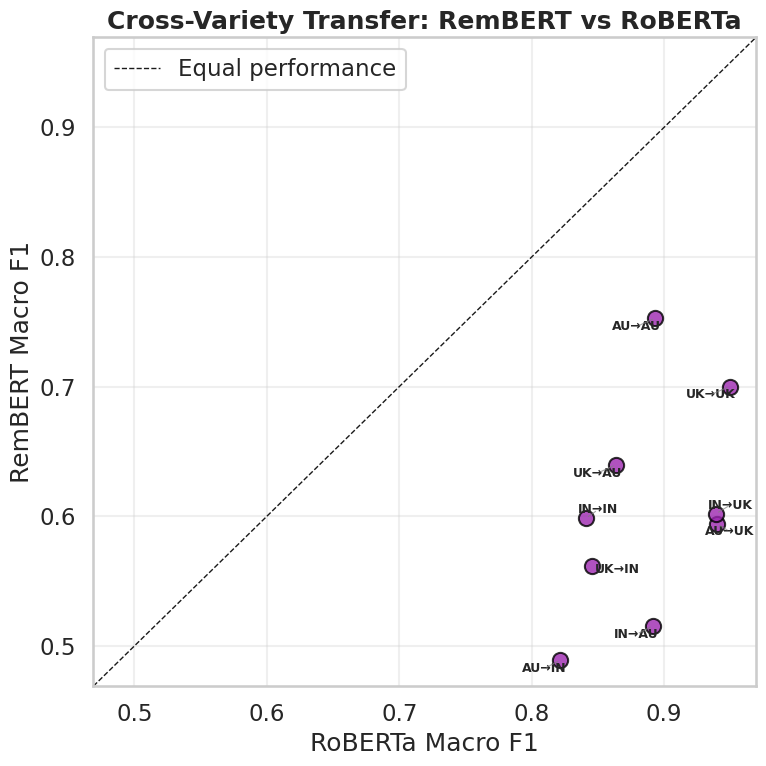

In [22]:
# External comparison with existing RoBERTa results

roberta_cross_path = find_file('cross_variety_results_q2_2.csv')
roberta_q3_path = find_file('q3_eval_sentiment.csv')

print(f"Looking for RoBERTa results...")
print(f"  cross_variety_results_q2_2.csv: {roberta_cross_path}")
print(f"  q3_eval_sentiment.csv: {roberta_q3_path}")

if roberta_cross_path is not None:
    print(f"\n{'='*60}")
    print(f"COMPARISON: {MODEL_LABEL} vs RoBERTa (Cross-Variety)")
    print(f"{'='*60}")
    
    rob_df = pd.read_csv(roberta_cross_path)
    
    # Ensure column compatibility
    if 'macro_f1_mean' not in rob_df.columns and 'f1_mean' in rob_df.columns:
        rob_df['macro_f1_mean'] = rob_df['f1_mean']
    
    # Merge with our cross results
    merged = cross_df_task.merge(
        rob_df[['train_variety', 'test_variety', 'macro_f1_mean']], 
        on=['train_variety', 'test_variety'], 
        suffixes=(f'_{MODEL_LABEL.lower()}', '_roberta')
    )
    
    if not merged.empty:
        # Compute advantage
        merged['advantage'] = merged[f'macro_f1_mean_{MODEL_LABEL.lower()}'] - merged['macro_f1_mean_roberta']
        
        print(f"\nPer-route comparison:")
        for _, row in merged.iterrows():
            route = f"{row['train_variety']}→{row['test_variety']}"
            ours = row[f'macro_f1_mean_{MODEL_LABEL.lower()}']
            rob = row['macro_f1_mean_roberta']
            adv = row['advantage']
            symbol = '↑' if adv > 0 else '↓'
            print(f"  {route}: {MODEL_LABEL}={ours:.4f}, RoBERTa={rob:.4f}, Δ={adv:+.4f} {symbol}")
        
        print(f"\nOverall:")
        print(f"  {MODEL_LABEL} mean F1: {merged[f'macro_f1_mean_{MODEL_LABEL.lower()}'].mean():.4f}")
        print(f"  RoBERTa mean F1:  {merged['macro_f1_mean_roberta'].mean():.4f}")
        print(f"  Average advantage: {merged['advantage'].mean():+.4f}")
        
        # Scatter plot
        fig, ax = plt.subplots(figsize=(8, 8))
        
        ax.scatter(merged['macro_f1_mean_roberta'], merged[f'macro_f1_mean_{MODEL_LABEL.lower()}'], 
                   s=120, c='#9c27b0', edgecolor='black', alpha=0.8)
        
        # Diagonal line
        lim = [min(merged['macro_f1_mean_roberta'].min(), merged[f'macro_f1_mean_{MODEL_LABEL.lower()}'].min()) - 0.02,
               max(merged['macro_f1_mean_roberta'].max(), merged[f'macro_f1_mean_{MODEL_LABEL.lower()}'].max()) + 0.02]
        ax.plot(lim, lim, 'k--', linewidth=1, label='Equal performance')
        
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_xlabel('RoBERTa Macro F1')
        ax.set_ylabel(f'{MODEL_LABEL} Macro F1')
        ax.set_title(f'Cross-Variety Transfer: {MODEL_LABEL} vs RoBERTa', fontweight='bold')
        ax.legend(loc='upper left')
        ax.grid(alpha=0.3)
        
        # Add route labels without overlap
        texts = []
        for _, row in merged.iterrows():
            train_var = str(row['train_variety']).replace('en-', '') 
            test_var = str(row['test_variety']).replace('en-', '')
            route = f"{train_var}→{test_var}"
            texts.append(ax.text(row['macro_f1_mean_roberta'], row[f'macro_f1_mean_{MODEL_LABEL.lower()}'], 
                                 route, fontsize=9, fontweight='bold', ha='center', va='center'))
        try:
            from adjustText import adjust_text
            adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.7), expand_points=(1.5, 1.5))
        except ImportError:
            pass
            
        plt.tight_layout()
        plt.savefig(OUT_DIR / 'cross_variety_vs_roberta.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Save comparison
        merged.to_csv(OUT_DIR / 'cross_variety_comparison_with_roberta.csv', index=False)
else:
    print("\nNo RoBERTa results found for comparison.")
    print("Cross-variety comparison will be skipped.")


In [ ]:
# Find the best models for UI deployment

# Varieties selected for deployment
target_varieties = ['en-AU', 'en-IN', 'en-UK']

print(f"{'='*80}")
print(f"SEARCHING FOR BEST DEPLOYMENT MODELS ({MODEL_LABEL})")
print(f"{'='*80}")

for task_name in ['Sarcasm', 'Sentiment']:
    if task_name not in all_task_results:
        print(f"\nNo data found for {task_name}. Make sure you ran the training loop!")
        continue
        
    print(f"\n\n BEST MODELS FOR: {task_name.upper()} ")
    print("-" * 50)

    res = all_task_results[task_name]
    cross_raw = res['cross_raw']
    combined_raw = res['combined_raw']
    pooled_results = res['pooled_results']

    # 1. Search for the best model for specific geographic varieties
    for tv in target_varieties:
        best_f1 = -1
        best_info = {}

        # A. Check Cross-Variety Runs (e.g., trained on AU, evaluated on IN)
        for (train_var, seed), test_metrics in cross_raw.items():
            if tv in test_metrics:
                f1 = test_metrics[tv].get('macro_f1', 0)
                if f1 > best_f1:
                    best_f1 = f1
                    best_info = {
                        'strategy': f"Single-Variety (Trained purely on {train_var})",
                        'seed': seed,
                        'f1': f1,
                        'path': test_metrics.get('_meta', {}).get('final_model_dir', 'Path not found')
                    }

        # B. Check Combined Runs (trained on ALL, evaluated on IN)
        for seed, test_metrics in combined_raw.items():
            if tv in test_metrics:
                f1 = test_metrics[tv].get('macro_f1', 0)
                if f1 > best_f1:
                    best_f1 = f1
                    best_info = {
                        'strategy': "Combined Training (Trained on ALL varieties together)",
                        'seed': seed,
                        'f1': f1,
                        'path': test_metrics.get('_meta', {}).get('final_model_dir', 'Path not found')
                    }

        # Print the winner for this variety
        if best_f1 > -1:
            print(f"Target Audience: {tv}")
            print(f"   - Winning Strategy: {best_info['strategy']}")
            print(f"   - Macro F1 Score:   {best_info['f1']:.4f}")
            print(f"   - FOLDER TO ZIP: {best_info['path']}\n")

    # 2. Search for the best "Generic / Pooled" model
    # (Use this when no region is provided.)
    print(f"Target Audience: GENERIC / ALL REGIONS (Pooled Model)")
    best_pooled_f1 = -1
    best_pooled_info = {}
    
    for p in pooled_results:
        if p['macro_f1'] > best_pooled_f1:
            best_pooled_f1 = p['macro_f1']
            best_pooled_info = p

    if best_pooled_f1 > -1:
        print(f"   - Winning Strategy: Pooled Training (Best average across all data)")
        print(f"   - Macro F1 Score:   {best_pooled_info['macro_f1']:.4f}")
        print(f"   - FOLDER TO ZIP: {best_pooled_info.get('final_model_dir', 'Path not found')}\n")

🔍 SEARCHING FOR BEST DEPLOYMENT MODELS (RemBERT)


🏆 BEST MODELS FOR: SARCASM 🏆
--------------------------------------------------
🎯 Target Audience: en-AU
   - Winning Strategy: Combined Training (Trained on ALL varieties together)
   - Macro F1 Score:   0.7671
   - 📁 FOLDER TO ZIP: /scratch/HS400/outputs_rembert/sarcasm/final_models/rembert_combined_seed123

🎯 Target Audience: en-IN
   - Winning Strategy: Single-Variety (Trained purely on en-IN)
   - Macro F1 Score:   0.6284
   - 📁 FOLDER TO ZIP: /scratch/HS400/outputs_rembert/sarcasm/final_models/rembert_cross_train-en-IN_seed456

🎯 Target Audience: en-UK
   - Winning Strategy: Single-Variety (Trained purely on en-UK)
   - Macro F1 Score:   0.7280
   - 📁 FOLDER TO ZIP: /scratch/HS400/outputs_rembert/sarcasm/final_models/rembert_cross_train-en-UK_seed42

🎯 Target Audience: GENERIC / ALL REGIONS (Pooled Model)
   - Winning Strategy: Pooled Training (Best average across all data)
   - Macro F1 Score:   0.7301
   - 📁 FOLDER TO ZIP: /scr